<a href="https://colab.research.google.com/github/sirius70/NLP_HW4/blob/main/IE7275_Module10_Part2_STUDENT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **IE7275 Data Mining in Engineering**
### -- STUDENT VERSION --

---
#### **Guidelines for Completing and Submitting This Notebook**

Please follow these instructions carefully. Completing all parts of this notebook is required to receive full credit:

#### **You must:**
- **Answer all questions** and reflection tasks using your own words.
- **Summarize every reflection task** clearly and completely.
- **Fill out all missing code cells** — do not leave any code blocks empty.
- **Run your notebook** to ensure that all outputs and visualizations are generated and visible.
- **Convert your completed notebook** to **PDF** or **HTML** format before submission.
- **Submit the file to Canvas** before the deadline.

#### **Academic Integrity Reminder**:
- You must complete this notebook individually.
- Do not copy answers or code from classmates, online sources, or use tools like **ChatGPT** or other **AI writing or code generation tools**.
- Keep in mind that if you use such tools, your answer may be **identical or highly similar** to others who do the same — in this case, we will treat it as copying and apply a **50% penalty** to your assignment grade.

By submitting this notebook, you confirm that all work is your own and that you have followed these guidelines.


---



## **Module 10: Deep Learning for Engineering Applications (Part 2)**
---

#### **Module 10.4: Recurrent Neural Networks (RNN)**

Recurrent Neural Networks (RNNs) are designed specifically for sequential data by maintaining a hidden state that captures information about previous inputs. This makes them well-suited for modeling temporal dependencies in time series.

Key aspects of RNNs include:  
- **Hidden State:** Acts as memory, updated at each time step to incorporate new input and past context.  
- **Sequential Processing:** Inputs are processed one at a time, allowing the network to capture order and time dynamics.  
- **Vanishing and Exploding Gradients:** Challenges in training RNNs where gradients can become very small or large, hindering learning of long-term dependencies.  
- **Mitigation Strategies:** Techniques such as gradient clipping and advanced architectures like LSTM and GRU help overcome these problems.

RNNs form the basis for many deep learning models that handle time-dependent data in engineering and beyond.

---


#### **Exercise 1 — Preparing Sequential Data for an RNN**

Before training a Recurrent Neural Network (RNN), the first step is to **convert your raw time series into sequences** that the network can understand.  
RNNs expect inputs in the shape **(batch size, time steps, features)**, so we must create **sliding windows** of past observations to predict future values.

In this exercise, you will:
- Generate or load a sample time series dataset.
- Split the data into **training, validation, and test** sets.
- Standardize the data based on training statistics.
- Use `tf.keras.utils.timeseries_dataset_from_array()` to efficiently build batches of sequential data.
- Ensure that each sequence contains the correct number of **time steps** and **features** for the RNN.

By the end of this exercise, you’ll have a clean, ready-to-use dataset that can be directly fed into an RNN model for training and evaluation.

---

In [136]:
# Exercise 1 — Preparing Sequential Data for an RNN

from __future__ import annotations
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

# -----------------------------
# 1) Generate a clean synthetic time series
#    y[t] = trend + seasonality + noise
# -----------------------------
def make_series(n: int = 1500, season_period: int = 24, noise_std: float = 0.3):
    t = np.arange(n, dtype=np.float32)
    trend = 0.002 * t
    season = 0.8 * np.sin(2 * np.pi * t / season_period)
    noise = np.random.normal(0.0, noise_std, size=n).astype(np.float32)
    y = trend + season + noise
    return y


In [137]:
# -----------------------------
# 2) Split series into train/val/test (index-based, keep order)
# -----------------------------
def temporal_split(y: np.ndarray, train_frac=0.7, val_frac=0.15):
    n = len(y)
    n_train = int(n * train_frac)
    n_val = int(n * val_frac)
    y_train = y[:n_train]
    y_val   = y[n_train:n_train + n_val]
    y_test  = y[n_train + n_val:]
    return y_train, y_val, y_test


In [138]:
# -----------------------------
# 3) Standardize by training statistics only
# -----------------------------
def standardize_by_train(y_tr: np.ndarray, y_va: np.ndarray, y_te: np.ndarray):
    mu = y_tr.mean()
    sd = y_tr.std() + 1e-8
    return ( (y_tr - mu) / sd, (y_va - mu) / sd, (y_te - mu) / sd, mu, sd )


In [139]:
# -----------------------------
# 4) Build tf.data Datasets with Keras utility
#    Targets always shaped to (batch, forecast_horizon, 1)
# -----------------------------
def make_windowed_dataset(
    y: np.ndarray,
    input_length: int = 32,
    forecast_horizon: int = 1,
    batch_size: int = 64,
    stride: int = 1,
    shuffle: bool = True,
):
    """
    Creates (X, y) windows using timeseries_dataset_from_array:
      - X: past 'input_length' points -> shape (batch, input_length, 1)
      - y: next 'forecast_horizon' point(s) -> shape (batch, forecast_horizon, 1)
    """
    if len(y) <= input_length or len(y) <= forecast_horizon:
        raise ValueError(
            f"Series too short (len={len(y)}). Need > input_length ({input_length}) "
            f"and > forecast_horizon ({forecast_horizon})."
        )

    # Inputs exclude the last horizon; targets are shifted by horizon
    inputs = y[:-forecast_horizon].astype(np.float32)
    targets = y[forecast_horizon:].astype(np.float32)  # 1-step targets (we’ll reshape inside map)

    ds = tf.keras.utils.timeseries_dataset_from_array(
        data=inputs,
        targets=targets,
        sequence_length=input_length,
        sequence_stride=stride,
        sampling_rate=1,
        batch_size=batch_size,
        shuffle=shuffle,
    )

    # Ensure:
    #  X -> (batch, time, 1)
    #  y -> (batch, horizon, 1)   (even when horizon = 1)
    def _format(X, Y, fh=forecast_horizon):
        X = tf.expand_dims(X, axis=-1)
        # Y may come as shape (batch,) — make it (batch, fh) then (batch, fh, 1)
        Y = tf.reshape(Y, (-1, fh))
        Y = tf.expand_dims(Y, axis=-1)
        return X, Y

    ds = ds.map(_format)
    return ds


In [140]:
# -----------------------------
# 5) Convenience visualizations (optional)
# -----------------------------
def plot_series(y_tr, y_va, y_te, title="Synthetic Time Series (Train/Val/Test)"):
    plt.figure(figsize=(10, 3))
    n_tr, n_va = len(y_tr), len(y_va)
    plt.plot(np.arange(n_tr), y_tr, label="train")
    plt.plot(np.arange(n_tr, n_tr + n_va), y_va, label="val")
    plt.plot(np.arange(n_tr + n_va, n_tr + n_va + len(y_te)), y_te, label="test")
    plt.legend()
    plt.title(title)
    plt.xlabel("Time")
    plt.ylabel("Value")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def show_first_window(ds, input_length, horizon):
    for Xb, yb in ds.take(1):
        print("Preview — Batch X shape:", Xb.shape)  # (batch, time, 1)
        print("Preview — Batch y shape:", yb.shape)  # (batch, horizon, 1)
        # Plot first sample in batch
        x0 = Xb[0, :, 0].numpy()
        y0 = yb[0, :, 0].numpy()  # now safe: shaped (horizon,)
        plt.figure(figsize=(8, 3))
        plt.plot(range(input_length), x0, label="input window")
        plt.scatter([input_length + i for i in range(len(y0))], y0, label="target(s)", marker="x")
        plt.title("First Window + Target")
        plt.xlabel("Time steps")
        plt.ylabel("Value")
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()
        break

# -----------------------------
# 6) Safe cardinality without consuming the dataset
# -----------------------------
def dataset_cardinality(ds: tf.data.Dataset) -> int:
    c = tf.data.experimental.cardinality(ds).numpy()
    # c < 0 => UNKNOWN or INFINITE
    return int(c) if c >= 0 else -1


=== Dataset Summary (non-consuming) ===
Train windows: 16
Val windows:   4
Test windows:  4


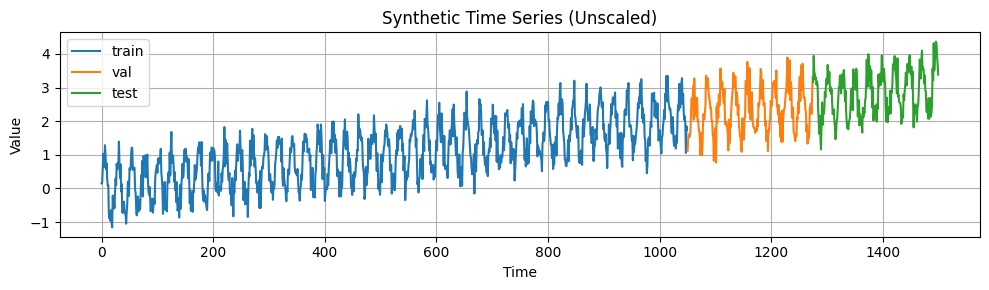

Preview — Batch X shape: (1, 32, 1)
Preview — Batch y shape: (1, 1, 1)


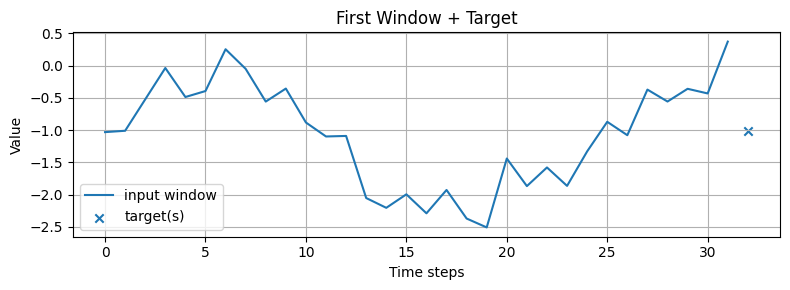

In [141]:
# -----------------------------
# 7) Self-test runner (no dataset exhaustion, robust shapes)
# -----------------------------
def self_test(
    n_points: int = 1500,
    season_period: int = 24,
    input_length: int = 32,
    forecast_horizon: int = 1,
    batch_size: int = 64,
    stride: int = 1,
    plot: bool = True
):
    # Sanity check: need enough points to make at least one window
    min_needed = input_length + forecast_horizon
    if n_points < min_needed:
        raise ValueError(
            f"n_points={n_points} too small. Need at least {min_needed} "
            f"(input_length {input_length} + forecast_horizon {forecast_horizon})."
        )

    y = make_series(n=n_points, season_period=season_period, noise_std=0.3)

    # Split and scale
    y_tr, y_va, y_te = temporal_split(y, train_frac=0.7, val_frac=0.15)
    y_tr_s, y_va_s, y_te_s, mu, sd = standardize_by_train(y_tr, y_va, y_te)

    # Build datasets (cache to avoid recompute on repeated passes)
    ds_tr = make_windowed_dataset(y_tr_s, input_length, forecast_horizon, batch_size, stride, shuffle=True).cache()
    ds_va = make_windowed_dataset(y_va_s, input_length, forecast_horizon, batch_size, stride, shuffle=False).cache()
    ds_te = make_windowed_dataset(y_te_s, input_length, forecast_horizon, batch_size, stride, shuffle=False).cache()

    # Count windows WITHOUT consuming datasets
    n_tr = dataset_cardinality(ds_tr)
    n_va = dataset_cardinality(ds_va)
    n_te = dataset_cardinality(ds_te)

    print("=== Dataset Summary (non-consuming) ===")
    print("Train windows:", n_tr if n_tr >= 0 else "UNKNOWN")
    print("Val windows:  ", n_va if n_va >= 0 else "UNKNOWN")
    print("Test windows: ", n_te if n_te >= 0 else "UNKNOWN")

    if plot:
        plot_series(y_tr, y_va, y_te, title="Synthetic Time Series (Unscaled)")
        # Use a FRESH one-window dataset for preview to avoid exhausting ds_tr
        ds_preview = make_windowed_dataset(
            y_tr_s, input_length, forecast_horizon, batch_size=1, stride=stride, shuffle=False
        )
        show_first_window(ds_preview, input_length, forecast_horizon)

    meta = {
        "input_length": input_length,
        "forecast_horizon": forecast_horizon,
        "batch_size": batch_size,
        "stride": stride,
        "train_mean": float(mu),
        "train_std": float(sd),
    }
    return ds_tr, ds_va, ds_te, meta


ds_tr, ds_va, ds_te, meta = self_test(
     n_points=1500, season_period=24, input_length=32, forecast_horizon=1, batch_size=64
 )


---

#### **In-Class Reflection: Exercise Summary**

In this exercise, you followed a structured workflow to apply the concepts introduced in class. Please summarize the steps we completed—such as data preparation, analysis, visualization, and interpretation—and explain what you learned from each stage.  

Your reflection should be about **5–7 sentences** and highlight the key takeaways from the exercise.  

> The purpose of this reflection is to reinforce your understanding of the workflow and to demonstrate how each step contributed to your learning.  

---

The exercise focused on preparing time-series data so it can be used in a Recurrent Neural Network. First, a synthetic time series was generated that included trend, seasonality, and random noise to simulate real-world patterns. Then the data was split into training, validation, and test sets while keeping the time order intact so that future information did not leak into the past. After that, the values were standardized using only the training data statistics to ensure fair scaling across all sets. Next, sliding windows were created using a time-series dataset utility so the model can learn from sequences of past values to predict future ones. The dataset was then checked and visualized to confirm that the input shapes and target shapes were correct and meaningful. Overall, the exercise showed how raw sequential data must be carefully structured before it can be used in deep learning models.


#### **Exercise 2: Building and Training a Simple RNN for Time Series Forecasting**

In this exercise, you will learn how to **build and train a simple Recurrent Neural Network (RNN)** for one-step-ahead time series forecasting. You’ll use TensorFlow/Keras to create the model, train it on the windowed dataset prepared earlier, and evaluate its predictive performance.

You will:
- Use the `SimpleRNN` layer to capture sequential dependencies.
- Stack the RNN with a `Dense` output layer for regression.
- Train the model using **Mean Squared Error (MSE)** loss and the **Adam** optimizer.
- Plot predictions vs. actual values on the validation set to visually inspect performance.

---


In [142]:
# Exercise 2 — Building and Training a Simple RNN for Time Series Forecasting

from __future__ import annotations
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# -----------------------------
# Reproducibility
# -----------------------------
SEED = 42
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

# -----------------------------
# 1) Make a synthetic time series: trend + seasonality + noise
# -----------------------------
def make_series(n: int = 1500, season_period: int = 24, noise_std: float = 0.3):
    t = np.arange(n, dtype=np.float32)
    trend = 0.002 * t
    season = 0.8 * np.sin(2 * np.pi * t / season_period)
    noise = np.random.normal(0.0, noise_std, size=n).astype(np.float32)
    return trend + season + noise

In [143]:
# -----------------------------
# 2) Temporal split (train / val / test) — keep chronological order
# -----------------------------
def temporal_split(y: np.ndarray, train_frac=0.7, val_frac=0.15):
    n = len(y)
    n_train = int(n * train_frac)
    n_val = int(n * val_frac)
    y_train = y[:n_train]
    y_val   = y[n_train:n_train + n_val]
    y_test  = y[n_train + n_val:]
    return y_train, y_val, y_test

# -----------------------------
# 3) Standardize using training stats only
# -----------------------------
def standardize_by_train(y_tr: np.ndarray, y_va: np.ndarray, y_te: np.ndarray):
    mu = y_tr.mean()
    sd = y_tr.std() + 1e-8
    return ( (y_tr - mu) / sd, (y_va - mu) / sd, (y_te - mu) / sd, mu, sd )


In [144]:
# -----------------------------
# 4) Build tf.data datasets with Keras utility (1-step horizon)
#    Outputs:
#       X -> (batch, input_length, 1)
#       y -> (batch, 1)
# -----------------------------
def make_windowed_dataset(
    y: np.ndarray,
    input_length: int = 32,
    batch_size: int = 64,
    stride: int = 1,
    shuffle: bool = True,
):
    forecast_horizon = 1
    if len(y) <= input_length or len(y) <= forecast_horizon:
        raise ValueError(
            f"Series too short (len={len(y)}). Need > input_length ({input_length}) "
            f"and > forecast_horizon ({forecast_horizon})."
        )

    inputs = y[:-forecast_horizon].astype(np.float32)
    targets = y[forecast_horizon:].astype(np.float32)

    ds = tf.keras.utils.timeseries_dataset_from_array(
        data=inputs,
        targets=targets,
        sequence_length=input_length,
        sequence_stride=stride,
        sampling_rate=1,
        batch_size=batch_size,
        shuffle=shuffle,
    )

    def _format(X, Y):
        X = tf.expand_dims(X, axis=-1)    # (batch, time, 1)
        Y = tf.reshape(Y, (-1, 1))        # (batch, 1)
        return X, Y

    return ds.map(_format)


In [145]:
# -----------------------------
# 5) Plot helpers
# -----------------------------
def plot_series_splits(y_tr, y_va, y_te, title="Synthetic Time Series (Train/Val/Test)"):
    plt.figure(figsize=(10, 3))
    n_tr, n_va = len(y_tr), len(y_va)
    plt.plot(np.arange(n_tr), y_tr, label="train")
    plt.plot(np.arange(n_tr, n_tr + n_va), y_va, label="val")
    plt.plot(np.arange(n_tr + n_va, n_tr + n_va + len(y_te)), y_te, label="test")
    plt.legend()
    plt.title(title)
    plt.xlabel("Time")
    plt.ylabel("Value")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def plot_predictions(model, ds, title="Predictions vs Actual (Validation)"):
    Xb, yb = next(iter(ds))
    preds = model.predict(Xb, verbose=0)
    plt.figure(figsize=(9, 4))
    plt.plot(yb.numpy().flatten(), label="Actual")
    plt.plot(preds.flatten(), label="Predicted")
    plt.title(title)
    plt.xlabel("Sample index in batch")
    plt.ylabel("Value (standardized)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


In [146]:
# -----------------------------
# 6) Build a SimpleRNN model (with explicit Input layer)
# -----------------------------
def build_simple_rnn(input_length: int):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(input_length, 1)),
        tf.keras.layers.SimpleRNN(32, activation="tanh"),
        tf.keras.layers.Dense(1)  # one-step regression
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="mse",
        metrics=["mae"]
    )
    return model


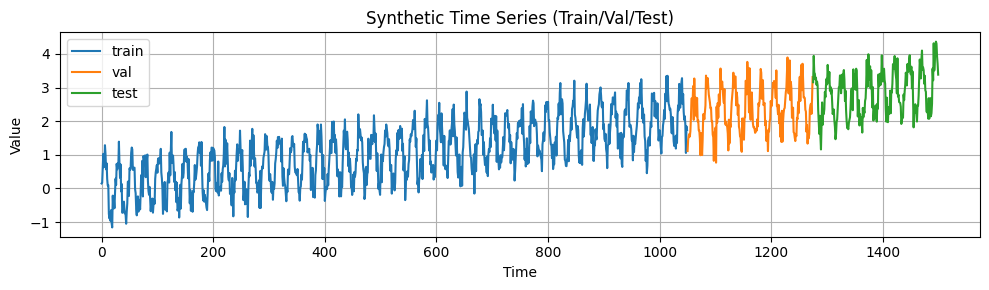

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 81ms/step - loss: 0.5732 - mae: 0.6093 - val_loss: 0.6249 - val_mae: 0.6388
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.2286 - mae: 0.3782 - val_loss: 0.5151 - val_mae: 0.5815
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.1873 - mae: 0.3455 - val_loss: 0.4590 - val_mae: 0.5343
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.1624 - mae: 0.3195 - val_loss: 0.3592 - val_mae: 0.4724
Epoch 5/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.1487 - mae: 0.3050 - val_loss: 0.3089 - val_mae: 0.4360
Epoch 6/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.1428 - mae: 0.2989 - val_loss: 0.2756 - val_mae: 0.4110
Epoch 7/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1401 - mae: 0.2960 - val_loss: 0.2633 - val_mae: 0.4015
Epoch 8/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1379 - mae: 0.2941 - val_loss: 0.2533 - val_mae: 0.3937
Epoch 9/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.136

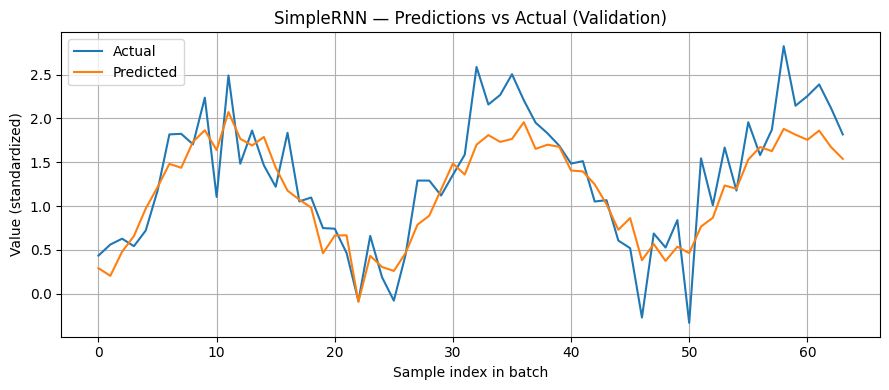

In [147]:
# -----------------------------
# 7) End-to-end run
# -----------------------------
def run_exercise_2(
    n_points=1500,
    season_period=24,
    input_length=32,
    batch_size=64,
    epochs=20,
    stride=1,
    plot=True
):
    # Make series
    y = make_series(n=n_points, season_period=season_period, noise_std=0.3)

    # Split and scale
    y_tr, y_va, y_te = temporal_split(y, train_frac=0.7, val_frac=0.15)
    y_tr_s, y_va_s, y_te_s, mu, sd = standardize_by_train(y_tr, y_va, y_te)

    if plot:
        plot_series_splits(y_tr, y_va, y_te)

    # Datasets (cache for smooth iteration)
    ds_tr = make_windowed_dataset(y_tr_s, input_length, batch_size, stride, shuffle=True).cache()
    ds_va = make_windowed_dataset(y_va_s, input_length, batch_size, stride, shuffle=False).cache()
    ds_te = make_windowed_dataset(y_te_s, input_length, batch_size, stride, shuffle=False).cache()

    # Build and train
    model = build_simple_rnn(input_length)
    history = model.fit(
        ds_tr,
        validation_data=ds_va,
        epochs=epochs,
        verbose=1
    )

    # Evaluate
    test_loss, test_mae = model.evaluate(ds_te, verbose=0)
    print(f"\nTest — MSE: {test_loss:.4f} | MAE: {test_mae:.4f}")

    # Visualize predictions on validation
    if plot:
        plot_predictions(model, ds_va, title="SimpleRNN — Predictions vs Actual (Validation)")

    return {
        "model": model,
        "history": history.history,
        "test_mse": float(test_loss),
        "test_mae": float(test_mae),
        "meta": {
            "input_length": input_length,
            "batch_size": batch_size,
            "stride": stride,
            "train_mean": float(mu),
            "train_std": float(sd),
        }
    }

# --------- RUN ----------
results = run_exercise_2(
    n_points=1500,
    season_period=24,
    input_length=32,
    batch_size=64,
    epochs=20,
    stride=1,
    plot=True
)

---

#### **In-Class Reflection: Exercise Summary**

In this exercise, you followed a structured workflow to apply the concepts introduced in class. Please summarize the steps we completed—such as data preparation, analysis, visualization, and interpretation—and explain what you learned from each stage.  

Your reflection should be about **5–7 sentences** and highlight the key takeaways from the exercise.  

> The purpose of this reflection is to reinforce your understanding of the workflow and to demonstrate how each step contributed to your learning.  

---

This exercise focused on building and training a Simple Recurrent Neural Network for time series forecasting. First, a synthetic dataset was created with trend, seasonality, and noise to represent real-world time-dependent data. The data was then split into training, validation, and test sets in chronological order to preserve the sequence structure. After that, the values were standardized using only training statistics to ensure consistent scaling across all datasets. A windowed dataset was then created so the model could learn patterns from past time steps and predict the next value. A SimpleRNN model was built with one recurrent layer and a dense output layer, and it was trained using MSE loss and the Adam optimizer. Finally, predictions were compared with actual values on the validation set, showing how well the model captured the overall pattern even though some variation remained.


#### **Exercise 3: Sequence‑to‑Sequence (Multi‑Step) Forecasting with a Vanilla RNN**

In this exercise, you’ll build a **sequence‑to‑sequence** model using only **vanilla RNN (SimpleRNN)** layers to predict the **next `H` future steps** of a univariate time series. You’ll use an **encoder–decoder** design in Keras:
- **Encoder:** `SimpleRNN(..., return_sequences=False)` to compress the past window.
- **RepeatVector(H):** repeats the context `H` times.
- **Decoder:** `SimpleRNN(..., return_sequences=True)` to unfold predictions over `H` steps.
- **TimeDistributed(Dense(1))** to emit one value per future step.

You will:
- Prepare **multi‑step** targets with `timeseries_dataset_from_array`.
- Train the encoder–decoder RNN with **MSE** loss.
- Plot predicted vs. actual **future sequences** on the validation set.
---


In [148]:
# Exercise 3 — Multi‑Step (Seq2Seq) Forecasting with a Vanilla RNN (Keras)

from __future__ import annotations
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# -----------------------------
# Reproducibility
# -----------------------------
SEED = 42
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

# -----------------------------
# 1) Synthetic time series
# -----------------------------
def make_series(n: int = 2000, season_period: int = 24, noise_std: float = 0.3):
    t = np.arange(n, dtype=np.float32)
    trend = 0.002 * t
    season = 0.8 * np.sin(2 * np.pi * t / season_period)
    noise = np.random.normal(0.0, noise_std, size=n).astype(np.float32)
    return trend + season + noise

def temporal_split(y: np.ndarray, train_frac=0.7, val_frac=0.15):
    n = len(y)
    n_train = int(n * train_frac)
    n_val = int(n * val_frac)
    y_train = y[:n_train]
    y_val   = y[n_train:n_train + n_val]
    y_test  = y[n_train + n_val:]
    return y_train, y_val, y_test

def standardize_by_train(y_tr: np.ndarray, y_va: np.ndarray, y_te: np.ndarray):
    mu = y_tr.mean()
    sd = y_tr.std() + 1e-8
    return ((y_tr - mu) / sd, (y_va - mu) / sd, (y_te - mu) / sd, mu, sd)


In [149]:
# -----------------------------
# 2) Multi‑step windowed datasets (L+H -> split to X[:L], y[L:])
#    Shapes after batching:
#      X -> (batch, L, 1)
#      y -> (batch, H, 1)
# -----------------------------
def make_multistep_dataset(
    y: np.ndarray,
    input_length: int = 48,
    forecast_horizon: int = 12,
    batch_size: int = 64,
    stride: int = 1,
    shuffle: bool = True,
):
    L, H = input_length, forecast_horizon
    if len(y) < (L + H):
        raise ValueError(f"Series too short (len={len(y)}). Need at least L+H = {L + H} points.")

    # Build unbatched sequences of length (L+H)
    ds_raw = tf.keras.utils.timeseries_dataset_from_array(
        data=y.astype(np.float32),
        targets=None,
        sequence_length=L + H,
        sequence_stride=stride,
        sampling_rate=1,
        batch_size=None,  # unbatched; we'll batch later with drop_remainder=True
        shuffle=shuffle,
    )

    def _split(seq):
        # seq: shape (L+H,)
        x = seq[:L]
        y_future = seq[L:]
        x = tf.expand_dims(x, axis=-1)          # (L, 1)
        y_future = tf.expand_dims(y_future, -1) # (H, 1)
        return x, y_future

    ds = (
        ds_raw
        .map(_split)
        .batch(batch_size, drop_remainder=True)  # keep batch shapes static
        .prefetch(tf.data.AUTOTUNE)
    )
    return ds


In [150]:
# -----------------------------
# 3) Plot helpers
# -----------------------------
def plot_series_splits(y_tr, y_va, y_te, title="Synthetic Time Series (Train/Val/Test)"):
    plt.figure(figsize=(10, 3))
    n_tr, n_va = len(y_tr), len(y_va)
    plt.plot(np.arange(n_tr), y_tr, label="train")
    plt.plot(np.arange(n_tr, n_tr + n_va), y_va, label="val")
    plt.plot(np.arange(n_tr + n_va, n_tr + n_va + len(y_te)), y_te, label="test")
    plt.legend()
    plt.title(title)
    plt.xlabel("Time")
    plt.ylabel("Value")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def plot_seq2seq_predictions(model, ds, n_examples=3, title="Seq2Seq — Predicted vs Actual (Validation)"):
    # Single batch (consistent shape thanks to drop_remainder=True)
    it = iter(ds)
    Xb, yb = next(it)   # Xb: (B, L, 1), yb: (B, H, 1)
    preds = model(Xb, training=False).numpy()  # avoid predict() retracing
    B, H, _ = preds.shape

    n_examples = min(n_examples, B)
    fig, axes = plt.subplots(n_examples, 1, figsize=(8, 2.8 * n_examples), sharex=True)
    axes = np.atleast_1d(axes)
    for i in range(n_examples):
        axes[i].plot(yb[i, :, 0].numpy(), label="Actual future")
        axes[i].plot(preds[i, :, 0], label="Predicted future")
        axes[i].set_ylabel("Value (std.)")
        axes[i].grid(True)
        axes[i].legend()
    axes[-1].set_xlabel("Forecast step (t+1 ... t+H)")
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


In [151]:
# -----------------------------
# 4) Seq2Seq model with vanilla RNN (encoder–decoder)
# -----------------------------
def build_seq2seq_rnn(input_length: int, forecast_horizon: int):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(input_length, 1)),
        tf.keras.layers.SimpleRNN(64, activation="tanh", return_sequences=False),  # encoder
        tf.keras.layers.RepeatVector(forecast_horizon),
        tf.keras.layers.SimpleRNN(32, activation="tanh", return_sequences=True),   # decoder
        tf.keras.layers.TimeDistributed(tf.keras.layers.Dense(1))
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="mse",
        metrics=[tf.keras.metrics.MeanAbsoluteError(name="mae")]
    )
    return model


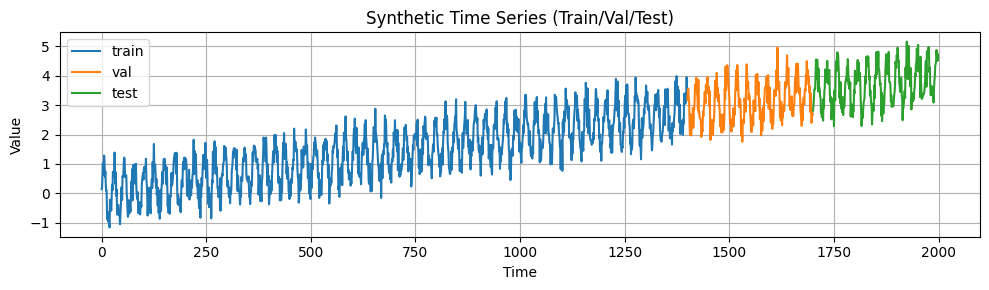

Epoch 1/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 74ms/step - loss: 0.4292 - mae: 0.5212 - val_loss: 0.6848 - val_mae: 0.6782
Epoch 2/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.1838 - mae: 0.3385 - val_loss: 0.2699 - val_mae: 0.4103
Epoch 3/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.1319 - mae: 0.2881 - val_loss: 0.2592 - val_mae: 0.4098
Epoch 4/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.1164 - mae: 0.2713 - val_loss: 0.2872 - val_mae: 0.4388
Epoch 5/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.1088 - mae: 0.2619 - val_loss: 0.2185 - val_mae: 0.3768
Epoch 6/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - loss: 0.1040 - mae: 0.2559 - val_loss: 0.2356 - val_mae: 0.3932
Epoch 7/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.1020 - mae: 0.2531 - val_loss: 0.1821 - val_mae: 0.3436
Epoch 8/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.1029 - mae: 0.2543 - val_loss: 0.1952 - val_mae: 0.3555
Epoch 9/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.100

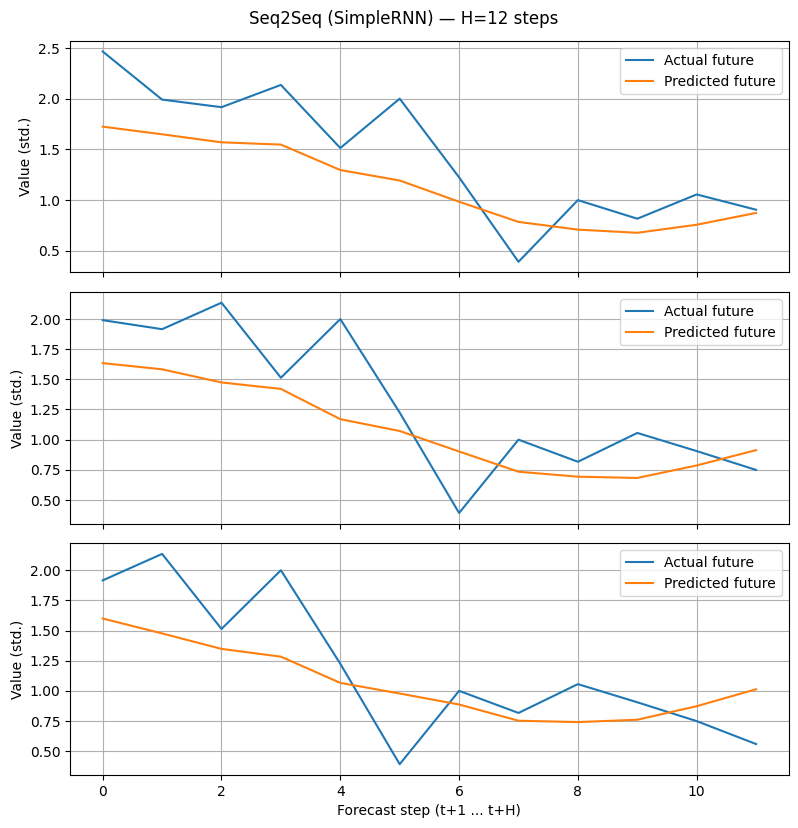

In [152]:
# -----------------------------
# 5) End‑to‑end run
# -----------------------------
def run_exercise_3(
    n_points=2000,
    season_period=24,
    input_length=48,
    forecast_horizon=12,
    batch_size=64,
    epochs=20,
    stride=1,
    plot=True
):
    # Data
    y = make_series(n=n_points, season_period=season_period, noise_std=0.3)
    y_tr, y_va, y_te = temporal_split(y, train_frac=0.7, val_frac=0.15)
    y_tr_s, y_va_s, y_te_s, mu, sd = standardize_by_train(y_tr, y_va, y_te)

    if plot:
        plot_series_splits(y_tr, y_va, y_te)

    # Datasets: same batch size & static shapes across splits
    ds_tr = make_multistep_dataset(y_tr_s, input_length, forecast_horizon, batch_size, stride, shuffle=True)
    ds_va = make_multistep_dataset(y_va_s, input_length, forecast_horizon, batch_size, stride, shuffle=False)
    ds_te = make_multistep_dataset(y_te_s, input_length, forecast_horizon, batch_size, stride, shuffle=False)

    # Model
    model = build_seq2seq_rnn(input_length, forecast_horizon)

    # Train
    history = model.fit(
        ds_tr,
        validation_data=ds_va,
        epochs=epochs,
        verbose=1
    )

    # Evaluate
    test_loss, test_mae = model.evaluate(ds_te, verbose=0)
    print(f"\nTest — MSE: {test_loss:.4f} | MAE: {test_mae:.4f}")

    # Visualize predictions on validation set
    if plot:
        plot_seq2seq_predictions(model, ds_va, n_examples=3,
                                 title=f"Seq2Seq (SimpleRNN) — H={forecast_horizon} steps")

    return {
        "model": model,
        "history": history.history,
        "test_mse": float(test_loss),
        "test_mae": float(test_mae),
        "meta": {
            "input_length": input_length,
            "forecast_horizon": forecast_horizon,
            "batch_size": batch_size,
            "stride": stride,
            "train_mean": float(mu),
            "train_std": float(sd),
        }
    }

# --------- RUN ----------
results = run_exercise_3(
    n_points=2000,
    season_period=24,
    input_length=48,
    forecast_horizon=12,
    batch_size=64,   # consistent across splits
    epochs=20,
    stride=1,
    plot=True
)


---

#### **In-Class Reflection: Exercise Summary**

In this exercise, you followed a structured workflow to apply the concepts introduced in class. Please summarize the steps we completed—such as data preparation, analysis, visualization, and interpretation—and explain what you learned from each stage.  

Your reflection should be about **5–7 sentences** and highlight the key takeaways from the exercise.  

> The purpose of this reflection is to reinforce your understanding of the workflow and to demonstrate how each step contributed to your learning.  

---

This exercise focused on building a sequence-to-sequence forecasting model using a vanilla RNN architecture. First, a synthetic time series was generated with trend, seasonality, and noise to simulate realistic temporal data. The dataset was then split into training, validation, and test sets while maintaining chronological order to preserve time dependencies. After that, the data was standardized using only training statistics and converted into multi-step input–output pairs, where past values were used to predict several future time steps. A seq2seq model was then built using an encoder-decoder structure with SimpleRNN layers, along with RepeatVector and TimeDistributed layers to produce multi-step forecasts. The model was trained using MSE loss and evaluated on validation and test sets to measure performance. Finally, predictions were visualized against actual future sequences, showing how well the model captured overall patterns but still struggled with longer-term accuracy.


#### **Exercise 4: Tuning Vanilla RNN Hyperparameters (Units · Window Length · Batch Size · LR)**

In this exercise, you’ll run a **small, library‑only hyperparameter sweep** for a **vanilla `SimpleRNN`** on a synthetic time series. You’ll vary:
- **RNN units** (model capacity)
- **Input window length** (how much past context)
- **Batch size** (optimization stability/speed)
- **Learning rate** (optimizer step size)

You will:
- Build reproducible train/val/test splits and standardized data.
- Create windowed datasets with **static batch shapes** (no retracing).
- Train short runs with **EarlyStopping** and record **validation MAE**.
- Report the **top configurations** and visualize results.

---


In [153]:
# Exercise 4 — Tuning Vanilla RNN Hyperparameters (Units · Window Length · Batch Size · LR)

from __future__ import annotations
import itertools
import time
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# -----------------------------
# Reproducibility
# -----------------------------
SEED = 42
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

# -----------------------------
# 1) Synthetic time series
# -----------------------------
def make_series(n: int = 2000, season_period: int = 24, noise_std: float = 0.3):
    t = np.arange(n, dtype=np.float32)
    trend = 0.002 * t
    season = 0.8 * np.sin(2 * np.pi * t / season_period)
    noise = np.random.normal(0.0, noise_std, size=n).astype(np.float32)
    return trend + season + noise

def temporal_split(y: np.ndarray, train_frac=0.7, val_frac=0.15):
    n = len(y)
    n_train = int(n * train_frac)
    n_val = int(n * val_frac)
    y_train = y[:n_train]
    y_val   = y[n_train:n_train + n_val]
    y_test  = y[n_train + n_val:]
    return y_train, y_val, y_test

def standardize_by_train(y_tr: np.ndarray, y_va: np.ndarray, y_te: np.ndarray):
    mu = y_tr.mean()
    sd = y_tr.std() + 1e-8
    return ((y_tr - mu) / sd, (y_va - mu) / sd, (y_te - mu) / sd, mu, sd)


In [154]:
# -----------------------------
# 2) Windowed datasets (1-step forecasting)
#    Static batch shapes via .batch(..., drop_remainder=True)
#    Shapes:
#      X -> (batch, input_length, 1)
#      y -> (batch, 1)
# -----------------------------
def make_dataset_1step(
    y: np.ndarray,
    input_length: int = 32,
    batch_size: int = 64,
    stride: int = 1,
    shuffle: bool = True,
):
    L, H = input_length, 1
    if len(y) < (L + H):
        raise ValueError(f"Series too short (len={len(y)}). Need at least L+H = {L + H}.")

    # build unbatched windows of length (L+H)
    ds_raw = tf.keras.utils.timeseries_dataset_from_array(
        data=y.astype(np.float32),
        targets=None,
        sequence_length=L + H,
        sequence_stride=stride,
        sampling_rate=1,
        batch_size=None,    # unbatched
        shuffle=shuffle,
    )

    def _split(seq):
        x = seq[:L]
        y_next = seq[L:]          # shape (1,)
        x = tf.expand_dims(x, -1) # (L, 1)
        y_next = tf.reshape(y_next, (1,))  # (1,)
        return x, y_next

    ds = (ds_raw
          .map(_split)
          .batch(batch_size, drop_remainder=True)  # keep shapes constant
          .prefetch(tf.data.AUTOTUNE))
    return ds


In [155]:
# -----------------------------
# 3) Model builder (vanilla RNN)
# -----------------------------
def build_simple_rnn(input_length: int, units: int, lr: float):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(input_length, 1)),
        tf.keras.layers.SimpleRNN(units, activation="tanh"),
        tf.keras.layers.Dense(1)
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss="mse",
        metrics=[tf.keras.metrics.MeanAbsoluteError(name="mae")]
    )
    return model


In [156]:
# -----------------------------
# 4) Hyperparameter sweep
# -----------------------------
def run_sweep(
    y: np.ndarray,
    units_list=(16, 32, 64),
    window_list=(16, 32, 64),
    batch_list=(32, 64),
    lr_list=(1e-3, 3e-4),
    epochs=20,
    stride=1,
    patience=3,
    verbose=0,
):
    # split and standardize
    y_tr, y_va, y_te = temporal_split(y, train_frac=0.7, val_frac=0.15)
    y_tr_s, y_va_s, y_te_s, mu, sd = standardize_by_train(y_tr, y_va, y_te)

    results = []
    total = len(units_list) * len(window_list) * len(batch_list) * len(lr_list)
    k = 0

    for units, win, bsz, lr in itertools.product(units_list, window_list, batch_list, lr_list):
        k += 1
        start = time.time()

        # Rebuild datasets for this window length & batch size
        ds_tr = make_dataset_1step(y_tr_s, input_length=win, batch_size=bsz, stride=stride, shuffle=True)
        ds_va = make_dataset_1step(y_va_s, input_length=win, batch_size=bsz, stride=stride, shuffle=False)
        ds_te = make_dataset_1step(y_te_s, input_length=win, batch_size=bsz, stride=stride, shuffle=False)

        # Build & train
        model = build_simple_rnn(input_length=win, units=units, lr=lr)
        cb = tf.keras.callbacks.EarlyStopping(
            monitor="val_mae", patience=patience, restore_best_weights=True
        )
        hist = model.fit(
            ds_tr,
            validation_data=ds_va,
            epochs=epochs,
            callbacks=[cb],
            verbose=verbose
        )

        # Evaluate on validation to rank configs
        val_loss, val_mae = model.evaluate(ds_va, verbose=0)
        test_loss, test_mae = model.evaluate(ds_te, verbose=0)
        elapsed = time.time() - start

        results.append({
            "units": units,
            "window": win,
            "batch": bsz,
            "lr": lr,
            "val_mae": float(val_mae),
            "val_mse": float(val_loss),
            "test_mae": float(test_mae),
            "test_mse": float(test_loss),
            "epochs_ran": len(hist.history["loss"]),
            "time_sec": elapsed
        })
        print(f"[{k:02d}/{total}] units={units:2d} win={win:2d} batch={bsz:3d} lr={lr:.0e} "
              f"| val_MAE={val_mae:.4f} | test_MAE={test_mae:.4f} | {elapsed:.1f}s")

    # Sort by val MAE
    results_sorted = sorted(results, key=lambda d: d["val_mae"])
    return results_sorted


In [157]:
# -----------------------------
# 5) Visualization helpers
# -----------------------------
def show_top(results, top_n=5):
    print("\n=== Top Configurations (by Val MAE) ===")
    for r in results[:top_n]:
        print(f"units={r['units']:2d}  win={r['window']:2d}  batch={r['batch']:3d}  lr={r['lr']:.0e}  "
              f"| val_MAE={r['val_mae']:.4f}  test_MAE={r['test_mae']:.4f}  "
              f"| epochs={r['epochs_ran']:2d}  time={r['time_sec']:.1f}s")

def plot_bar(results, by=("units","window")):
    # Simple grouped bar: x-axis = one hyperparam, color/group = another
    import pandas as pd
    df = pd.DataFrame(results)
    a, b = by
    # Aggregate (mean val_MAE) over other params
    agg = df.groupby([a, b])["val_mae"].mean().reset_index()
    pivot = agg.pivot(index=a, columns=b, values="val_mae").sort_index()
    pivot.plot(kind="bar", figsize=(8,4))
    plt.title("Validation MAE across hyperparameters")
    plt.ylabel("Val MAE (↓ better)")
    plt.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()


[01/36] units=16 win=16 batch= 32 lr=1e-03 | val_MAE=0.3930 | test_MAE=0.5993 | 2.9s
[02/36] units=16 win=16 batch= 32 lr=3e-04 | val_MAE=0.4160 | test_MAE=0.6755 | 7.7s
[03/36] units=16 win=16 batch= 64 lr=1e-03 | val_MAE=0.3376 | test_MAE=0.5281 | 3.9s
[04/36] units=16 win=16 batch= 64 lr=3e-04 | val_MAE=0.7464 | test_MAE=1.2063 | 6.6s
[05/36] units=16 win=32 batch= 32 lr=1e-03 | val_MAE=0.3959 | test_MAE=0.5817 | 2.5s
[06/36] units=16 win=32 batch= 32 lr=3e-04 | val_MAE=0.4623 | test_MAE=0.7207 | 7.9s
[07/36] units=16 win=32 batch= 64 lr=1e-03 | val_MAE=0.4231 | test_MAE=0.6502 | 6.2s
[08/36] units=16 win=32 batch= 64 lr=3e-04 | val_MAE=0.5172 | test_MAE=0.8014 | 7.1s
[09/36] units=16 win=64 batch= 32 lr=1e-03 | val_MAE=0.4408 | test_MAE=0.6304 | 6.8s
[10/36] units=16 win=64 batch= 32 lr=3e-04 | val_MAE=0.4731 | test_MAE=0.6936 | 15.8s
[11/36] units=16 win=64 batch= 64 lr=1e-03 | val_MAE=0.4263 | test_MAE=0.6937 | 5.2s
[12/36] units=16 win=64 batch= 64 lr=3e-04 | val_MAE=0.5919 | te

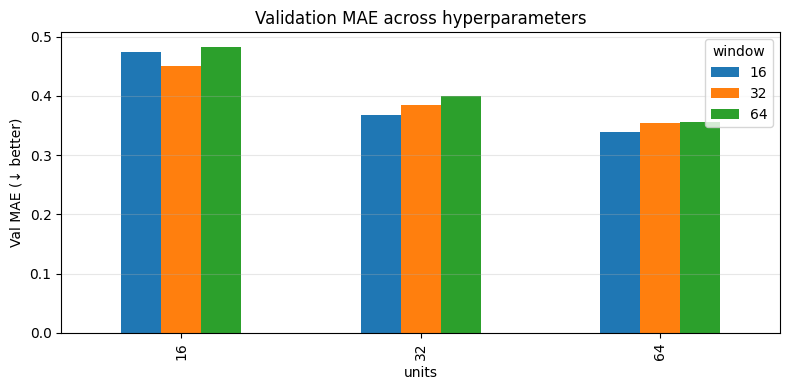

In [158]:
# -----------------------------
# 6) Run the exercise
# -----------------------------
def run_exercise_4():
    y = make_series(n=2000, season_period=24, noise_std=0.3)

    results = run_sweep(
        y,
        units_list=(16, 32, 64),
        window_list=(16, 32, 64),
        batch_list=(32, 64),
        lr_list=(1e-3, 3e-4),
        epochs=20,
        stride=1,
        patience=3,
        verbose=0,   # set to 1 for per-epoch logs
    )
    show_top(results, top_n=5)
    plot_bar(results, by=("units", "window"))
    return results

# --------- RUN ----------
results = run_exercise_4()

---

#### **In-Class Reflection: Exercise Summary**

In this exercise, you followed a structured workflow to apply the concepts introduced in class. Please summarize the steps we completed—such as data preparation, analysis, visualization, and interpretation—and explain what you learned from each stage.  

Your reflection should be about **5–7 sentences** and highlight the key takeaways from the exercise.  

> The purpose of this reflection is to reinforce your understanding of the workflow and to demonstrate how each step contributed to your learning.  

---

This exercise focused on improving a vanilla RNN model by tuning important hyperparameters to find the best forecasting performance. First, a synthetic time series was generated with trend, seasonality, and noise to represent realistic sequential data. The data was then split into training, validation, and test sets while preserving time order, and standardized using only training statistics. Next, windowed datasets were created for different input lengths so the model could learn from varying amounts of past context. A SimpleRNN model was trained multiple times while changing parameters like number of units, window size, batch size, and learning rate. Early stopping was used to avoid unnecessary training and to keep the best-performing model from each run. Finally, the results were compared using validation MAE, and the best configurations showed that higher RNN units and smaller window sizes often performed better for this dataset.


#### **Exercise 5: Multi-Step Forecasting with Vanilla RNN**

In this exercise, you’ll extend the vanilla **`SimpleRNN`** approach to predict **multiple future time steps** in one forward pass instead of just the next value.  
You will:
- Prepare **multi-step windowed datasets** that output sequences of future targets.
- Build and train a **single-layer RNN** that outputs all forecast steps at once.
- Compare **predicted vs. actual** multi-step sequences on the test set.
- Visualize forecasts for **different horizons** to see where the model performs well and where it struggles.

---


In [159]:
# Exercise 5 — Multi-Step Forecasting with Vanilla RNN

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# -----------------------------
# 1) Synthetic time series
# -----------------------------
def make_series(n: int = 2000, season_period: int = 24, noise_std: float = 0.3):
    t = np.arange(n, dtype=np.float32)
    trend = 0.002 * t
    season = 0.8 * np.sin(2 * np.pi * t / season_period)
    noise = np.random.normal(0.0, noise_std, size=n).astype(np.float32)
    return trend + season + noise

def temporal_split(y, train_frac=0.7, val_frac=0.15):
    n = len(y)
    n_train = int(n * train_frac)
    n_val = int(n * val_frac)
    y_train = y[:n_train]
    y_val   = y[n_train:n_train + n_val]
    y_test  = y[n_train + n_val:]
    return y_train, y_val, y_test

def standardize_by_train(y_tr, y_va, y_te):
    mu = y_tr.mean()
    sd = y_tr.std() + 1e-8
    return ((y_tr - mu)/sd, (y_va - mu)/sd, (y_te - mu)/sd, mu, sd)


In [160]:
# -----------------------------
# 2) Multi-step windowed datasets
# -----------------------------
def make_dataset_multistep(
    y,
    input_length=48,
    forecast_horizon=12,
    batch_size=64,
    stride=1,
    shuffle=True
):
    L, H = input_length, forecast_horizon
    if len(y) < (L + H):
        raise ValueError(f"Series too short: {len(y)} < {L+H}")

    ds_raw = tf.keras.utils.timeseries_dataset_from_array(
        data=y.astype(np.float32),
        targets=None,
        sequence_length=L + H,
        sequence_stride=stride,
        sampling_rate=1,
        batch_size=None,
        shuffle=shuffle
    )

    def _split(seq):
        x = seq[:L]
        y_future = seq[L:]
        x = tf.expand_dims(x, -1)             # (L, 1)
        y_future = tf.reshape(y_future, (H,)) # (H,)
        return x, y_future

    ds = (ds_raw
          .map(_split)
          .batch(batch_size, drop_remainder=True)
          .prefetch(tf.data.AUTOTUNE))
    return ds


In [161]:
# -----------------------------
# 3) Model builder — Vanilla RNN
# -----------------------------
def build_rnn_multistep(input_length, forecast_horizon, units=64, lr=1e-3):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(input_length, 1)),
        tf.keras.layers.SimpleRNN(units, activation="tanh"),
        tf.keras.layers.Dense(forecast_horizon)
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss="mse",
        metrics=[tf.keras.metrics.MeanAbsoluteError(name="mae")]
    )
    return model


In [162]:
# -----------------------------
# 4) Visualization
# -----------------------------
def plot_forecast_example(ds, model, input_length, forecast_horizon, n_plots=3):
    for xb, yb in ds.take(1):
        preds = model.predict(xb)
        plt.figure(figsize=(12, 3 * n_plots))
        for i in range(n_plots):
            past = xb[i, :, 0].numpy()
            actual = yb[i].numpy()
            pred = preds[i]
            plt.subplot(n_plots, 1, i+1)
            plt.plot(range(input_length), past, label="Past")
            plt.plot(range(input_length, input_length + forecast_horizon), actual, label="Actual")
            plt.plot(range(input_length, input_length + forecast_horizon), pred, label="Predicted")
            plt.axvline(x=input_length-1, color="gray", linestyle="--")
            plt.legend()
        plt.tight_layout()
        plt.show()


Epoch 1/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.4921 - mae: 0.5609 - val_loss: 1.0149 - val_mae: 0.8743
Epoch 2/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1806 - mae: 0.3359 - val_loss: 0.4806 - val_mae: 0.5853
Epoch 3/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1004 - mae: 0.2523 - val_loss: 0.3376 - val_mae: 0.4832
Epoch 4/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0881 - mae: 0.2370 - val_loss: 0.2543 - val_mae: 0.4175
Epoch 5/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 0.0825 - mae: 0.2294 - val_loss: 0.2349 - val_mae: 0.4016
Epoch 6/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0806 - mae: 0.2269 - val_loss: 0.2254 - val_mae: 0.3955
Epoch 7/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0804 - mae: 0.2266 - val_loss: 0.2086 - val_mae: 0.3754
Epoch 8/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0788 - mae: 0.2248 - val_loss: 0.2159 - val_mae: 0.3859
Epoch 9/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.077

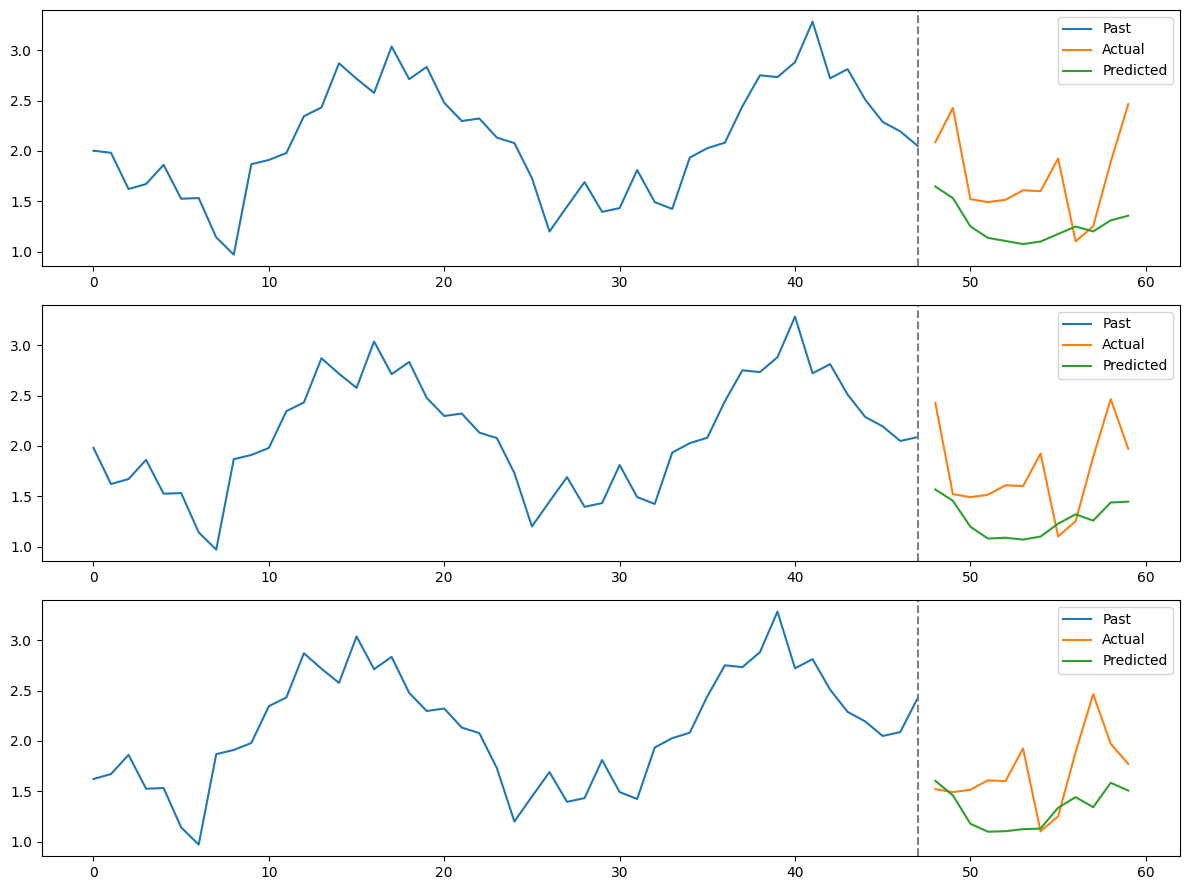

In [163]:
# -----------------------------
# 5) Run the exercise
# -----------------------------
def run_exercise_5():
    # Create & split data
    y = make_series(n=2500, season_period=24, noise_std=0.3)
    y_tr, y_va, y_te = temporal_split(y, train_frac=0.7, val_frac=0.15)
    y_tr_s, y_va_s, y_te_s, mu, sd = standardize_by_train(y_tr, y_va, y_te)

    # Datasets
    input_length = 48
    forecast_horizon = 12
    batch_size = 64
    ds_tr = make_dataset_multistep(y_tr_s, input_length, forecast_horizon, batch_size, shuffle=True)
    ds_va = make_dataset_multistep(y_va_s, input_length, forecast_horizon, batch_size, shuffle=False)
    ds_te = make_dataset_multistep(y_te_s, input_length, forecast_horizon, batch_size, shuffle=False)

    # Model
    model = build_rnn_multistep(input_length, forecast_horizon, units=64, lr=1e-3)
    cb = tf.keras.callbacks.EarlyStopping(monitor="val_mae", patience=3, restore_best_weights=True)
    history = model.fit(ds_tr, validation_data=ds_va, epochs=20, callbacks=[cb], verbose=1)

    # Evaluation
    test_loss, test_mae = model.evaluate(ds_te, verbose=0)
    print(f"Test MAE: {test_mae:.4f}")

    # Plot forecast examples
    plot_forecast_example(ds_te, model, input_length, forecast_horizon, n_plots=3)

    return model, history.history

# --------- RUN ----------
model, hist = run_exercise_5()

---

#### **In-Class Reflection: Exercise Summary**

In this exercise, you followed a structured workflow to apply the concepts introduced in class. Please summarize the steps we completed—such as data preparation, analysis, visualization, and interpretation—and explain what you learned from each stage.  

Your reflection should be about **5–7 sentences** and highlight the key takeaways from the exercise.  

> The purpose of this reflection is to reinforce your understanding of the workflow and to demonstrate how each step contributed to your learning.  

---

This exercise focused on extending a vanilla RNN to perform multi-step forecasting, where multiple future values are predicted at once. First, a synthetic time series was generated with trend, seasonality, and noise to simulate realistic sequential data. The data was then split into training, validation, and test sets while preserving chronological order to maintain time dependencies. After that, the dataset was transformed into input-output pairs where each input window of past values was mapped to a sequence of future values instead of a single point. A SimpleRNN model was built to take the past sequence and directly output multiple future steps using a dense layer. The model was trained using mean squared error loss with early stopping to prevent overfitting. Finally, predictions were compared with actual future sequences through visualization, showing that the model captures short-term patterns better but becomes less accurate as the forecast horizon increases.


#### **Exercise 6: Visualizing RNN Hidden State Outputs**

In this exercise, you’ll **train a vanilla `SimpleRNN`** for one‑step forecasting and then **inspect its hidden state dynamics** over time. You’ll extract the full sequence of hidden states from the RNN layer and visualize:
- **Per‑unit trajectories** across time for a given input window
- A **heatmap** of activations (time × units)
- Hidden dynamics on both **validation** and **test** samples to see stability and pattern tracking

You will:
- Build a windowed dataset (inputs of length `L`, predict next step)
- Train `SimpleRNN(return_sequences=True)` with a small Dense head for regression
- Create an **extractor model** to output the hidden-state sequence
- Plot several hidden units over time and a heatmap for one sample
---


In [164]:
# Exercise 6 — Visualizing RNN Hidden State Outputs (Vanilla RNN, library-only)
# Full, runnable, self-contained code.

from __future__ import annotations
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# -----------------------------
# Reproducibility
# -----------------------------
SEED = 42
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

# -----------------------------
# 1) Synthetic time series
# -----------------------------
def make_series(n: int = 2000, season_period: int = 24, noise_std: float = 0.3):
    t = np.arange(n, dtype=np.float32)
    trend = 0.002 * t
    season = 0.8 * np.sin(2 * np.pi * t / season_period)
    noise = np.random.normal(0.0, noise_std, size=n).astype(np.float32)
    return trend + season + noise

def temporal_split(y: np.ndarray, train_frac=0.7, val_frac=0.15):
    n = len(y)
    n_train = int(n * train_frac)
    n_val = int(n * val_frac)
    y_train = y[:n_train]
    y_val   = y[n_train:n_train + n_val]
    y_test  = y[n_train + n_val:]
    return y_train, y_val, y_test

def standardize_by_train(y_tr: np.ndarray, y_va: np.ndarray, y_te: np.ndarray):
    mu = y_tr.mean()
    sd = y_tr.std() + 1e-8
    return ((y_tr - mu) / sd, (y_va - mu) / sd, (y_te - mu) / sd, mu, sd)

# -----------------------------
# 2) Windowed dataset (1-step forecast)
#    Each sample is length (L+1), split into X[:L] -> y[L]
#    Shapes after batching:
#      X -> (batch, L, 1)
#      y -> (batch, 1)
# -----------------------------
def make_dataset_1step(
    y: np.ndarray,
    input_length: int = 48,
    batch_size: int = 64,
    stride: int = 1,
    shuffle: bool = True,
):
    L = input_length
    if len(y) < (L + 1):
        raise ValueError(f"Series too short (len={len(y)}). Need at least L+1 = {L + 1}.")

    ds_raw = tf.keras.utils.timeseries_dataset_from_array(
        data=y.astype(np.float32),
        targets=None,
        sequence_length=L + 1,
        sequence_stride=stride,
        sampling_rate=1,
        batch_size=None,   # unbatched; we’ll batch below
        shuffle=shuffle,
    )

    def _split(seq):
        x = seq[:L]
        y_next = seq[L:]
        x = tf.expand_dims(x, -1)          # (L, 1)
        y_next = tf.reshape(y_next, (1,))  # (1,)
        return x, y_next

    ds = (ds_raw
          .map(_split)
          .batch(batch_size, drop_remainder=True)  # static shapes
          .prefetch(tf.data.AUTOTUNE))
    return ds

# -----------------------------
# 3) Model: SimpleRNN with return_sequences=True
#    We'll take the last hidden state and pass to Dense(1) for regression.
# -----------------------------
def build_rnn_with_sequence_output(input_length: int, units: int = 32, lr: float = 1e-3):
    inp = tf.keras.layers.Input(shape=(input_length, 1))
    rnn_seq = tf.keras.layers.SimpleRNN(
        units, activation="tanh", return_sequences=True, name="rnn_seq"
    )(inp)
    last = tf.keras.layers.Lambda(lambda x: x[:, -1, :], name="last_t")(rnn_seq)
    out = tf.keras.layers.Dense(1, name="reg_head")(last)
    model = tf.keras.Model(inputs=inp, outputs=out, name="rnn_seq_regressor")
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss="mse",
        metrics=[tf.keras.metrics.MeanAbsoluteError(name="mae")]
    )
    # Extractor to get hidden states per time step
    extractor = tf.keras.Model(inputs=inp, outputs=rnn_seq, name="rnn_hidden_extractor")
    return model, extractor


In [165]:
# -----------------------------
# 4) Visualization helpers
# -----------------------------
def plot_hidden_trajectories(hidden_seq: np.ndarray, n_units_to_show: int = 4, title="Hidden trajectories"):
    """
    hidden_seq: (L, U) array for one sample (time, units)
    """
    L, U = hidden_seq.shape
    n = min(n_units_to_show, U)
    plt.figure(figsize=(8, 2.2 * n))
    for i in range(n):
        plt.subplot(n, 1, i+1)
        plt.plot(range(L), hidden_seq[:, i], label=f"unit {i}")
        plt.ylabel("act")
        plt.grid(True)
        plt.legend(loc="upper right")
    plt.xlabel("time step")
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

def plot_hidden_heatmap(hidden_seq: np.ndarray, title="Hidden heatmap (time × units)"):
    plt.figure(figsize=(8, 3))
    plt.imshow(hidden_seq.T, aspect="auto", interpolation="nearest")
    plt.colorbar(label="activation")
    plt.xlabel("time step")
    plt.ylabel("unit")
    plt.title(title)
    plt.tight_layout()
    plt.show()


Epoch 1/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.3568 - mae: 0.4800 - val_loss: 0.4700 - val_mae: 0.5738
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.1326 - mae: 0.2914 - val_loss: 0.2203 - val_mae: 0.3809
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.1145 - mae: 0.2674 - val_loss: 0.2262 - val_mae: 0.3867
Epoch 4/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.1076 - mae: 0.2610 - val_loss: 0.2353 - val_mae: 0.3991
Epoch 5/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1026 - mae: 0.2543 - val_loss: 0.2252 - val_mae: 0.3912
Test — MSE: 0.5279 | MAE: 0.6137


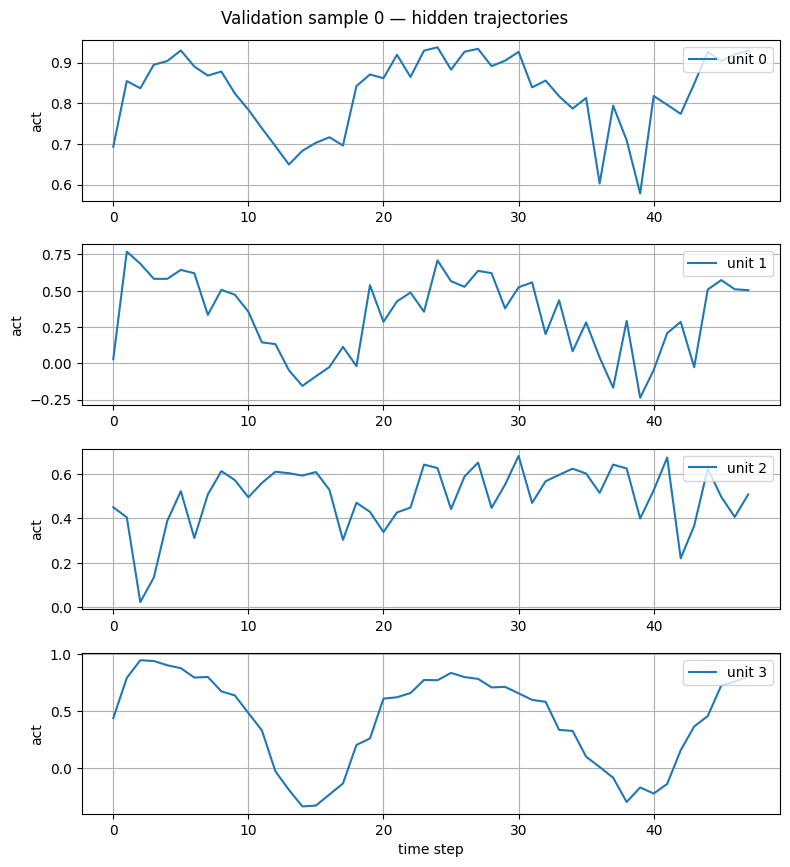

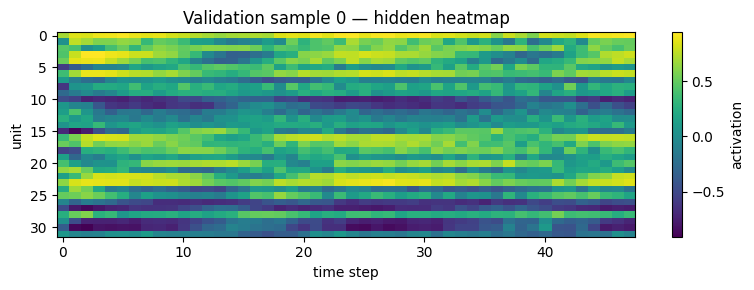

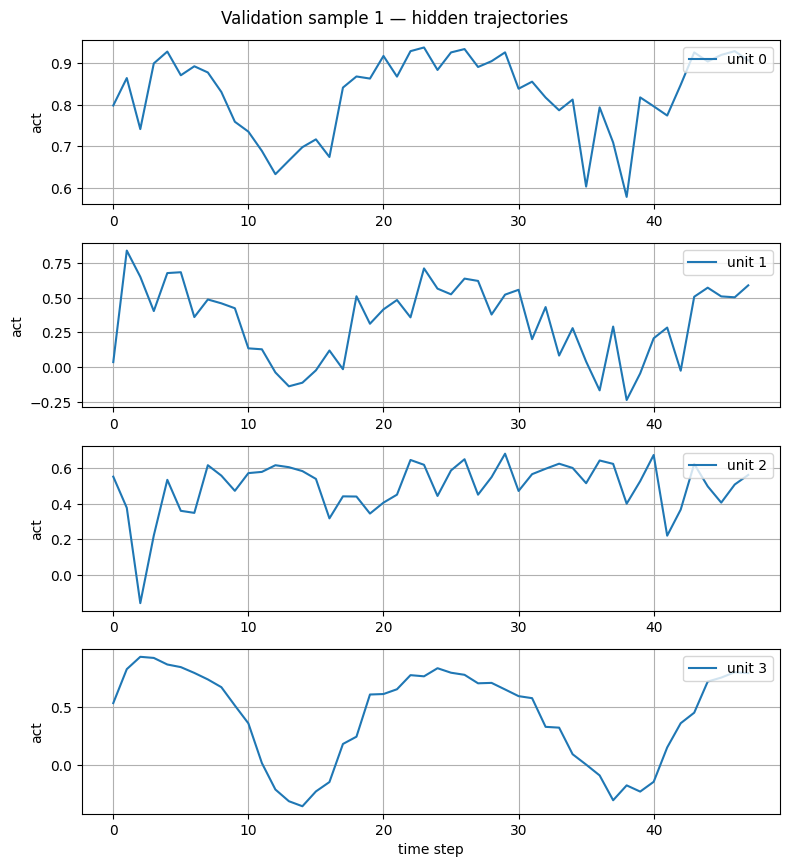

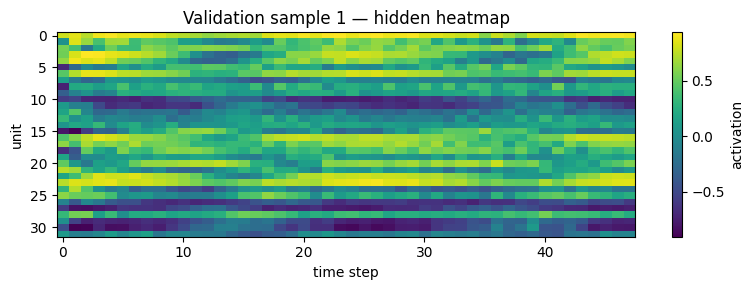

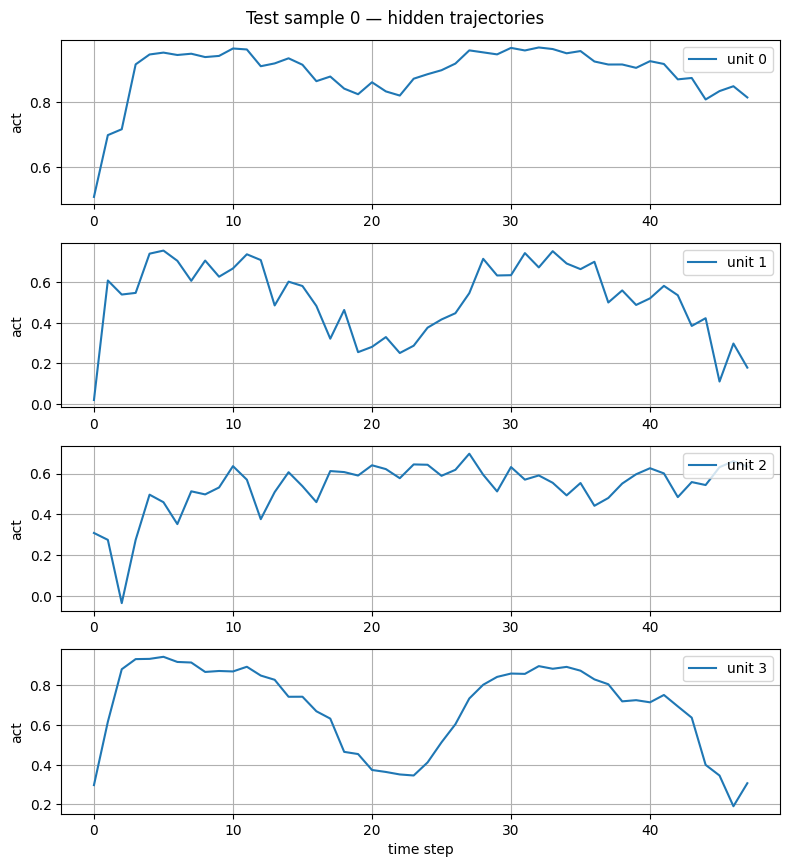

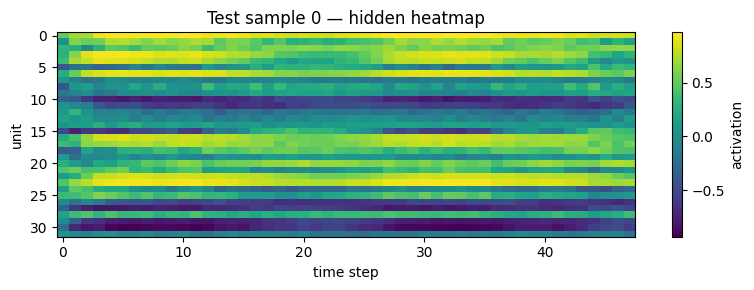

In [166]:
# -----------------------------
# 5) End-to-end run
# -----------------------------
def run_exercise_6():
    # Data
    y = make_series(n=2200, season_period=24, noise_std=0.3)
    y_tr, y_va, y_te = temporal_split(y, train_frac=0.7, val_frac=0.15)
    y_tr_s, y_va_s, y_te_s, mu, sd = standardize_by_train(y_tr, y_va, y_te)

    # Datasets
    input_length = 48
    batch_size = 64
    ds_tr = make_dataset_1step(y_tr_s, input_length=input_length, batch_size=batch_size, shuffle=True)
    ds_va = make_dataset_1step(y_va_s, input_length=input_length, batch_size=batch_size, shuffle=False)
    ds_te = make_dataset_1step(y_te_s, input_length=input_length, batch_size=batch_size, shuffle=False)

    # Model & extractor
    model, extractor = build_rnn_with_sequence_output(input_length=input_length, units=32, lr=1e-3)

    # Train briefly with early stopping
    cb = tf.keras.callbacks.EarlyStopping(monitor="val_mae", patience=3, restore_best_weights=True)
    history = model.fit(ds_tr, validation_data=ds_va, epochs=20, callbacks=[cb], verbose=1)

    # Evaluate
    test_loss, test_mae = model.evaluate(ds_te, verbose=0)
    print(f"Test — MSE: {test_loss:.4f} | MAE: {test_mae:.4f}")

    # --- Visualize hidden states on a single batch from validation ---
    Xb_va, yb_va = next(iter(ds_va))                 # shapes: (B, L, 1), (B, 1)
    hidden_va = extractor(Xb_va, training=False).numpy()  # (B, L, U)

    # Pick a couple of samples to visualize
    for sample_idx, label in [(0, "Validation sample 0"), (1, "Validation sample 1")]:
        hseq = hidden_va[sample_idx]   # (L, U)
        plot_hidden_trajectories(hseq, n_units_to_show=4, title=f"{label} — hidden trajectories")
        plot_hidden_heatmap(hseq, title=f"{label} — hidden heatmap")

    # --- Also peek at test batch to verify dynamics are similar ---
    Xb_te, yb_te = next(iter(ds_te))
    hidden_te = extractor(Xb_te, training=False).numpy()
    hseq_test0 = hidden_te[0]
    plot_hidden_trajectories(hseq_test0, n_units_to_show=4, title="Test sample 0 — hidden trajectories")
    plot_hidden_heatmap(hseq_test0, title="Test sample 0 — hidden heatmap")

    return {
        "model": model,
        "extractor": extractor,
        "history": history.history,
        "test_mse": float(test_loss),
        "test_mae": float(test_mae),
        "meta": {"input_length": input_length, "batch_size": batch_size}
    }

# --------- RUN ----------
results = run_exercise_6()

---

#### **In-Class Reflection: Exercise Summary**

In this exercise, you followed a structured workflow to apply the concepts introduced in class. Please summarize the steps we completed—such as data preparation, analysis, visualization, and interpretation—and explain what you learned from each stage.  

Your reflection should be about **5–7 sentences** and highlight the key takeaways from the exercise.  

> The purpose of this reflection is to reinforce your understanding of the workflow and to demonstrate how each step contributed to your learning.  

---

This exercise focused on understanding how a vanilla RNN processes sequential data by visualizing its hidden state behavior over time. First, a synthetic time series was generated with trend, seasonality, and noise to simulate real-world patterns. The data was then split into training, validation, and test sets while keeping the chronological order intact, and standardized using only training statistics. Next, windowed datasets were created so the model could learn from past values and predict the next time step. A SimpleRNN model with `return_sequences=True` was trained, and an additional extractor model was used to capture hidden states at every time step. These hidden states were then visualized using line plots and heatmaps to observe how different units responded to changes in the input sequence. The results showed that different RNN units capture different temporal patterns, and the activations evolve smoothly over time, helping to better understand how the model internally represents sequence information.


#### **Exercise 7: Handling Vanishing/Exploding Gradients with Gradient Clipping**

One of the common challenges when training RNNs is **vanishing or exploding gradients** — especially for long input sequences.  
In this exercise, you’ll learn to apply **gradient clipping** to stabilize training.

You will:
- Reuse the 1-step forecasting setup from Exercise 6.
- Increase the sequence length to make gradient issues more visible.
- Train the RNN **without clipping** and observe loss behavior.
- Train the RNN **with `clipnorm`** or `clipvalue` in the optimizer and compare.
- Plot the training/validation loss curves for both runs.

This will help you see how gradient clipping can **prevent unstable weight updates** and lead to smoother convergence.

---


In [167]:
# Exercise 7 — Handling Vanishing/Exploding Gradients with Gradient Clipping
# Full, runnable, self-contained code.

from __future__ import annotations
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

# -----------------------------
# 1) Synthetic series & helpers (reuse from Exercise 6)
# -----------------------------
def make_series(n: int = 2000, season_period: int = 24, noise_std: float = 0.3):
    t = np.arange(n, dtype=np.float32)
    trend = 0.002 * t
    season = 0.8 * np.sin(2 * np.pi * t / season_period)
    noise = np.random.normal(0.0, noise_std, size=n).astype(np.float32)
    return trend + season + noise

def temporal_split(y: np.ndarray, train_frac=0.7, val_frac=0.15):
    n = len(y)
    n_train = int(n * train_frac)
    n_val = int(n * val_frac)
    y_train = y[:n_train]
    y_val   = y[n_train:n_train + n_val]
    y_test  = y[n_train + n_val:]
    return y_train, y_val, y_test

def standardize_by_train(y_tr: np.ndarray, y_va: np.ndarray, y_te: np.ndarray):
    mu = y_tr.mean()
    sd = y_tr.std() + 1e-8
    return ((y_tr - mu) / sd, (y_va - mu) / sd, (y_te - mu) / sd, mu, sd)

def make_dataset_1step(y, input_length=48, batch_size=64, stride=1, shuffle=True):
    L = input_length
    ds_raw = tf.keras.utils.timeseries_dataset_from_array(
        data=y.astype(np.float32),
        targets=None,
        sequence_length=L + 1,
        sequence_stride=stride,
        sampling_rate=1,
        batch_size=None,
        shuffle=shuffle
    )
    def _split(seq):
        x = seq[:L]
        y_next = seq[L:]
        return tf.expand_dims(x, -1), tf.reshape(y_next, (1,))
    return (ds_raw
            .map(_split)
            .batch(batch_size, drop_remainder=True)
            .prefetch(tf.data.AUTOTUNE))


In [168]:
# -----------------------------
# 2) Build RNN model with optional gradient clipping
# -----------------------------
def build_rnn(input_length: int, units=32, lr=1e-3, clip_norm=None, clip_value=None):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(input_length, 1)),
        tf.keras.layers.SimpleRNN(units, activation="tanh"),
        tf.keras.layers.Dense(1)
    ])
    opt = tf.keras.optimizers.Adam(
        learning_rate=lr,
        clipnorm=clip_norm,
        clipvalue=clip_value
    )
    model.compile(optimizer=opt, loss="mse", metrics=["mae"])
    return model


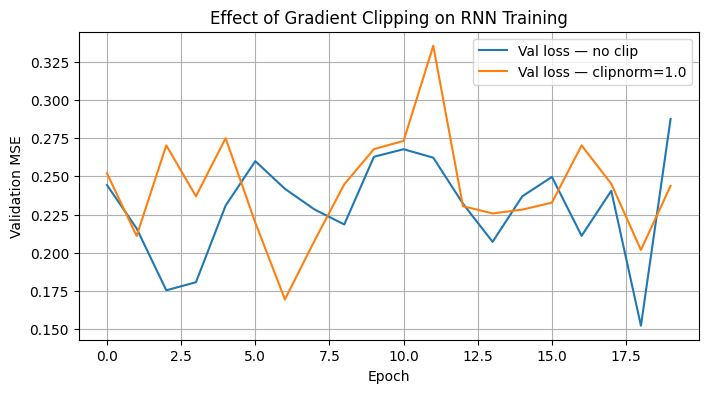

In [169]:
# -----------------------------
# 3) Run training with/without clipping
# -----------------------------
def run_exercise_7():
    # Data
    y = make_series(n=2500, season_period=24, noise_std=0.3)
    y_tr, y_va, y_te = temporal_split(y, train_frac=0.7, val_frac=0.15)
    y_tr_s, y_va_s, y_te_s, mu, sd = standardize_by_train(y_tr, y_va, y_te)

    # Dataset — longer sequence length to increase gradient issues
    input_length = 96
    batch_size = 64
    ds_tr = make_dataset_1step(y_tr_s, input_length, batch_size, shuffle=True)
    ds_va = make_dataset_1step(y_va_s, input_length, batch_size, shuffle=False)

    # Model without clipping
    model_no_clip = build_rnn(input_length=input_length, units=64, lr=1e-3)
    hist_no_clip = model_no_clip.fit(
        ds_tr, validation_data=ds_va, epochs=20, verbose=0
    )

    # Model with clipping (clipnorm)
    model_clip = build_rnn(input_length=input_length, units=64, lr=1e-3, clip_norm=1.0)
    hist_clip = model_clip.fit(
        ds_tr, validation_data=ds_va, epochs=20, verbose=0
    )

    # Plot loss curves
    plt.figure(figsize=(8, 4))
    plt.plot(hist_no_clip.history["val_loss"], label="Val loss — no clip")
    plt.plot(hist_clip.history["val_loss"], label="Val loss — clipnorm=1.0")
    plt.xlabel("Epoch")
    plt.ylabel("Validation MSE")
    plt.title("Effect of Gradient Clipping on RNN Training")
    plt.legend()
    plt.grid(True)
    plt.show()

    return {
        "no_clip_history": hist_no_clip.history,
        "clip_history": hist_clip.history
    }

# --------- RUN ----------
results = run_exercise_7()

---

#### **In-Class Reflection: Exercise Summary**

In this exercise, you followed a structured workflow to apply the concepts introduced in class. Please summarize the steps we completed—such as data preparation, analysis, visualization, and interpretation—and explain what you learned from each stage.  

Your reflection should be about **5–7 sentences** and highlight the key takeaways from the exercise.  

> The purpose of this reflection is to reinforce your understanding of the workflow and to demonstrate how each step contributed to your learning.  

---

This exercise focused on understanding the problem of vanishing and exploding gradients in vanilla RNNs and how gradient clipping can help stabilize training. First, a synthetic time series was generated with trend, seasonality, and noise to simulate real sequential data. The data was split into training, validation, and test sets while preserving chronological order, and standardized using only training statistics. Next, the sequence length was increased to make the training process more challenging and to highlight potential gradient instability. Two RNN models were then trained: one without gradient clipping and one with gradient clipping applied through the optimizer. Their validation loss curves were compared to observe differences in training stability. The results showed that gradient clipping leads to smoother and more stable convergence, reducing sudden spikes in loss and improving overall training behavior.


#### **Module 10.5: Long Short-Term Memory (LSTM) Networks**

Long Short-Term Memory (LSTM) networks are a specialized type of RNN designed to capture **long-term dependencies** in sequential data while mitigating the vanishing gradient problem.

Key features of LSTMs include:  
- **Memory Cells:** Maintain information over long sequences through carefully regulated cell states.  
- **Gating Mechanisms:**  
  - **Forget Gate:** Decides which information to discard from the cell state.  
  - **Input Gate:** Controls how much new information to add.  
  - **Output Gate:** Determines the output based on cell state and input.  
- **Capability:** Effective for complex time series where patterns span many time steps, such as speech recognition or sensor data analysis.

LSTMs have become a standard deep learning tool for time series forecasting and sequential data modeling due to their powerful memory capabilities.

---

#### **Exercise 8: Building a Basic LSTM for 1‑Step Forecasting**

In this exercise, you’ll build and train a **single‑layer LSTM** for **one‑step‑ahead** forecasting on a synthetic time series. You’ll prepare windowed datasets, train the LSTM with MSE loss, evaluate on a held‑out test split, and visualize predictions vs. ground truth.

You will:
- Create standardized **(inputs, targets)** windows for one‑step prediction.
- Train an **LSTM** with a small **Dense(1)** regression head.
- Report **MSE/MAE** on the test set.
- Plot **validation predictions vs. actuals** to visually assess performance.

---


In [170]:
# Exercise 8 — Building a Basic LSTM for 1‑Step Forecasting

from __future__ import annotations
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# -----------------------------
# Reproducibility
# -----------------------------
SEED = 42
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

# -----------------------------
# 1) Synthetic time series
# -----------------------------
def make_series(n: int = 2000, season_period: int = 24, noise_std: float = 0.3):
    """
    y[t] = slow trend + seasonal sinusoid + Gaussian noise
    """
    t = np.arange(n, dtype=np.float32)
    trend = 0.002 * t
    season = 0.8 * np.sin(2 * np.pi * t / season_period)
    noise = np.random.normal(0.0, noise_std, size=n).astype(np.float32)
    return trend + season + noise

def temporal_split(y: np.ndarray, train_frac=0.7, val_frac=0.15):
    n = len(y)
    n_train = int(n * train_frac)
    n_val = int(n * val_frac)
    y_train = y[:n_train]
    y_val   = y[n_train:n_train + n_val]
    y_test  = y[n_train + n_val:]
    return y_train, y_val, y_test

def standardize_by_train(y_tr: np.ndarray, y_va: np.ndarray, y_te: np.ndarray):
    mu = y_tr.mean()
    sd = y_tr.std() + 1e-8
    return ((y_tr - mu) / sd, (y_va - mu) / sd, (y_te - mu) / sd, mu, sd)


In [171]:
# -----------------------------
# 2) Windowed dataset for 1-step ahead forecasting
#    Build sequences of length (L+1), split into:
#      X -> first L steps  (batch, L, 1)
#      y -> last step      (batch, 1)
# -----------------------------
def make_dataset_1step(
    y: np.ndarray,
    input_length: int = 48,
    batch_size: int = 64,
    stride: int = 1,
    shuffle: bool = True,
):
    L = input_length
    if len(y) < (L + 1):
        raise ValueError(f"Series too short (len={len(y)}) — need at least L+1 = {L+1}.")
    # Unbatched rolling windows
    ds_raw = tf.keras.utils.timeseries_dataset_from_array(
        data=y.astype(np.float32),
        targets=None,
        sequence_length=L + 1,
        sequence_stride=stride,
        sampling_rate=1,
        batch_size=None,   # batch later to enable drop_remainder=True
        shuffle=shuffle,
    )

    def _split(seq):
        x = seq[:L]
        y_next = seq[L:]
        x = tf.expand_dims(x, -1)         # (L, 1)
        y_next = tf.reshape(y_next, (1,))  # (1,)
        return x, y_next

    ds = (ds_raw
          .map(_split)
          .batch(batch_size, drop_remainder=True)   # static shapes prevent retracing
          .prefetch(tf.data.AUTOTUNE))
    return ds


In [172]:
# -----------------------------
# 3) Model: single-layer LSTM + Dense(1)
# -----------------------------
def build_lstm(input_length: int, units: int = 64, lr: float = 1e-3):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(input_length, 1)),
        tf.keras.layers.LSTM(units, activation="tanh"),  # default recurrent_activation="sigmoid"
        tf.keras.layers.Dense(1)
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss="mse",
        metrics=[tf.keras.metrics.MeanAbsoluteError(name="mae")]
    )
    return model


In [173]:
# -----------------------------
# 4) Plot helper
# -----------------------------
def plot_predictions(model: tf.keras.Model, ds: tf.data.Dataset, title="LSTM — Predictions vs Actual (Validation)"):
    # Take one batch for visualization
    Xb, yb = next(iter(ds))
    preds = model(Xb, training=False).numpy()
    plt.figure(figsize=(9, 4))
    plt.plot(yb.numpy().flatten(), label="Actual")
    plt.plot(preds.flatten(), label="Predicted")
    plt.title(title)
    plt.xlabel("Sample index in batch")
    plt.ylabel("Value (standardized)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


Epoch 1/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.5686 - mae: 0.6241 - val_loss: 0.4971 - val_mae: 0.5715
Epoch 2/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.3606 - mae: 0.5078 - val_loss: 0.4616 - val_mae: 0.5444
Epoch 3/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.2741 - mae: 0.4371 - val_loss: 0.4797 - val_mae: 0.5560
Epoch 4/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.1641 - mae: 0.3284 - val_loss: 0.3687 - val_mae: 0.5026
Epoch 5/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.1061 - mae: 0.2564 - val_loss: 0.2953 - val_mae: 0.4487
Epoch 6/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.1017 - mae: 0.2535 - val_loss: 0.1625 - val_mae: 0.3207
Epoch 7/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0964 - mae: 0.2457 - val_loss: 0.1228 - val_mae: 0.2805
Epoch 8/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0962 - mae: 0.2452 - val_loss: 0.1702 - val_mae: 0.3276
Epoch 9/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.093

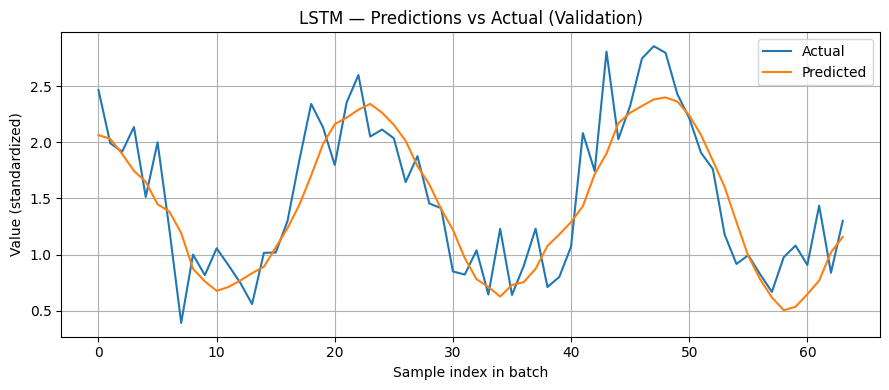

In [174]:
# -----------------------------
# 5) End-to-end run
# -----------------------------
def run_exercise_8(
    n_points=2000,
    season_period=24,
    input_length=48,
    batch_size=64,
    epochs=20,
    stride=1,
    plot=True
):
    # Data
    y = make_series(n=n_points, season_period=season_period, noise_std=0.3)
    y_tr, y_va, y_te = temporal_split(y, train_frac=0.7, val_frac=0.15)
    y_tr_s, y_va_s, y_te_s, mu, sd = standardize_by_train(y_tr, y_va, y_te)

    # Datasets (consistent batch shapes)
    ds_tr = make_dataset_1step(y_tr_s, input_length, batch_size, stride, shuffle=True)
    ds_va = make_dataset_1step(y_va_s, input_length, batch_size, stride, shuffle=False)
    ds_te = make_dataset_1step(y_te_s, input_length, batch_size, stride, shuffle=False)

    # Model
    model = build_lstm(input_length=input_length, units=64, lr=1e-3)

    # Train with EarlyStopping for convenience
    cb = tf.keras.callbacks.EarlyStopping(monitor="val_mae", patience=3, restore_best_weights=True)
    history = model.fit(ds_tr, validation_data=ds_va, epochs=epochs, callbacks=[cb], verbose=1)

    # Evaluate
    test_loss, test_mae = model.evaluate(ds_te, verbose=0)
    print(f"\nTest — MSE: {test_loss:.4f} | MAE: {test_mae:.4f}")

    # Visualize
    if plot:
        plot_predictions(model, ds_va, title="LSTM — Predictions vs Actual (Validation)")

    return {
        "model": model,
        "history": history.history,
        "test_mse": float(test_loss),
        "test_mae": float(test_mae),
        "meta": {
            "input_length": input_length,
            "batch_size": batch_size,
            "stride": stride,
            "train_mean": float(mu),
            "train_std": float(sd),
        }
    }

# --------- RUN ----------
results = run_exercise_8(
    n_points=2000,
    season_period=24,
    input_length=48,
    batch_size=64,
    epochs=20,
    stride=1,
    plot=True
)


---

#### **In-Class Reflection: Exercise Summary**

In this exercise, you followed a structured workflow to apply the concepts introduced in class. Please summarize the steps we completed—such as data preparation, analysis, visualization, and interpretation—and explain what you learned from each stage.  

Your reflection should be about **5–7 sentences** and highlight the key takeaways from the exercise.  

> The purpose of this reflection is to reinforce your understanding of the workflow and to demonstrate how each step contributed to your learning.  

---

This exercise focused on building a Long Short-Term Memory (LSTM) network for one-step time series forecasting. First, a synthetic time series was generated with trend, seasonality, and noise to simulate real-world sequential data. The data was then split into training, validation, and test sets while keeping the time order intact, and standardized using only training statistics. Next, windowed sequences were created so the model could learn from past values and predict the next time step. An LSTM model was built with a single LSTM layer followed by a Dense layer for regression output. The model was trained using mean squared error loss with early stopping to avoid overfitting. Finally, predictions were compared with actual values using visualization, showing that the LSTM captures the overall pattern better than a simple RNN and provides more stable forecasting performance.


#### **Exercise 9: Multi‑Step Forecasting with LSTM (Seq2Seq Encoder–Decoder)**

In this exercise, you’ll train an **LSTM encoder–decoder** to predict the **next `H` future steps** of a univariate time series from the previous `L` steps. You’ll build windowed datasets, train the model with MSE, and visualize predicted future sequences against ground truth.

You will:
- Prepare **multi‑step** targets using `(L+H)` windows and split into past/future.
- Build an **encoder–decoder LSTM**: `LSTM → RepeatVector(H) → LSTM(return_sequences=True) → TimeDistributed(Dense(1))`.
- Train with **MSE** and report **MAE** on a held‑out test set.
- Plot several **predicted vs. actual** future sequences on validation data.
---


In [175]:
# Exercise 9 — Multi‑Step Forecasting with LSTM (Seq2Seq Encoder–Decoder)

from __future__ import annotations
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# -----------------------------
# Reproducibility
# -----------------------------
SEED = 42
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

# -----------------------------
# 1) Synthetic time series
# -----------------------------
def make_series(n: int = 2200, season_period: int = 24, noise_std: float = 0.3):
    t = np.arange(n, dtype=np.float32)
    trend = 0.002 * t
    season = 0.8 * np.sin(2 * np.pi * t / season_period)
    noise = np.random.normal(0.0, noise_std, size=n).astype(np.float32)
    return trend + season + noise

def temporal_split(y: np.ndarray, train_frac=0.7, val_frac=0.15):
    n = len(y)
    n_train = int(n * train_frac)
    n_val = int(n * val_frac)
    y_train = y[:n_train]
    y_val   = y[n_train:n_train + n_val]
    y_test  = y[n_train + n_val:]
    return y_train, y_val, y_test

def standardize_by_train(y_tr: np.ndarray, y_va: np.ndarray, y_te: np.ndarray):
    mu = y_tr.mean()
    sd = y_tr.std() + 1e-8
    return ((y_tr - mu) / sd, (y_va - mu) / sd, (y_te - mu) / sd, mu, sd)


In [176]:
# -----------------------------
# 2) Multi‑step windowed datasets (build L+H windows, then split)
#    After batching:
#      X -> (batch, L, 1)
#      y -> (batch, H, 1)
# -----------------------------
def make_multistep_dataset(
    y: np.ndarray,
    input_length: int = 48,
    forecast_horizon: int = 12,
    batch_size: int = 64,
    stride: int = 1,
    shuffle: bool = True,
):
    L, H = input_length, forecast_horizon
    if len(y) < L + H:
        raise ValueError(f"Series too short ({len(y)}) — need at least L+H = {L+H}.")

    ds_raw = tf.keras.utils.timeseries_dataset_from_array(
        data=y.astype(np.float32),
        targets=None,
        sequence_length=L + H,
        sequence_stride=stride,
        sampling_rate=1,
        batch_size=None,          # unbatched; batch later so we can drop remainder
        shuffle=shuffle,
    )

    def _split(seq):
        x = seq[:L]
        fut = seq[L:]
        x = tf.expand_dims(x, -1)      # (L, 1)
        fut = tf.expand_dims(fut, -1)  # (H, 1)
        return x, fut

    return (
        ds_raw
        .map(_split)
        .batch(batch_size, drop_remainder=True)   # static shapes → fewer retraces
        .prefetch(tf.data.AUTOTUNE)
    )


In [177]:
# -----------------------------
# 3) Seq2Seq LSTM model (encoder–decoder)
# -----------------------------
def build_seq2seq_lstm(input_length: int, forecast_horizon: int, enc_units=64, dec_units=32, lr=1e-3):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(input_length, 1)),
        tf.keras.layers.LSTM(enc_units, activation="tanh", return_sequences=False),   # encoder → context
        tf.keras.layers.RepeatVector(forecast_horizon),
        tf.keras.layers.LSTM(dec_units, activation="tanh", return_sequences=True),    # decoder
        tf.keras.layers.TimeDistributed(tf.keras.layers.Dense(1))
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss="mse",
        metrics=[tf.keras.metrics.MeanAbsoluteError(name="mae")]
    )
    return model


In [178]:
# -----------------------------
# 4) Plot helper: show several seq forecasts
# -----------------------------
def plot_seq_forecasts(model: tf.keras.Model, ds: tf.data.Dataset, n_examples=3, title="LSTM Seq2Seq — Pred vs Actual"):
    Xb, yb = next(iter(ds))                 # Xb: (B, L, 1), yb: (B, H, 1)
    preds = model(Xb, training=False).numpy()   # (B, H, 1)
    B, H, _ = preds.shape
    n = min(n_examples, B)

    fig, axes = plt.subplots(n, 1, figsize=(8, 2.8 * n), sharex=True)
    if n == 1:
        axes = [axes]
    for i in range(n):
        axes[i].plot(yb[i, :, 0].numpy(), label="Actual future")
        axes[i].plot(preds[i, :, 0], label="Predicted future")
        axes[i].set_ylabel("Value (std.)")
        axes[i].grid(True)
        axes[i].legend()
    axes[-1].set_xlabel("Forecast step (t+1 … t+H)")
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


Epoch 1/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - loss: 0.6433 - mae: 0.6628 - val_loss: 0.9676 - val_mae: 0.8038
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.4254 - mae: 0.5431 - val_loss: 1.1584 - val_mae: 0.9215
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.3151 - mae: 0.4638 - val_loss: 0.5658 - val_mae: 0.6046
Epoch 4/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.2498 - mae: 0.4043 - val_loss: 0.5681 - val_mae: 0.6168
Epoch 5/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.2332 - mae: 0.3878 - val_loss: 0.4437 - val_mae: 0.5339
Epoch 6/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.2264 - mae: 0.3819 - val_loss: 0.5183 - val_mae: 0.5916
Epoch 7/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.2215 - mae: 0.3781 - val_loss: 0.4935 - val_mae: 0.5789
Epoch 8/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.2100 - mae: 0.3673 - val_loss: 0.3738 - val_mae: 0.4936
Epoch 9/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.195

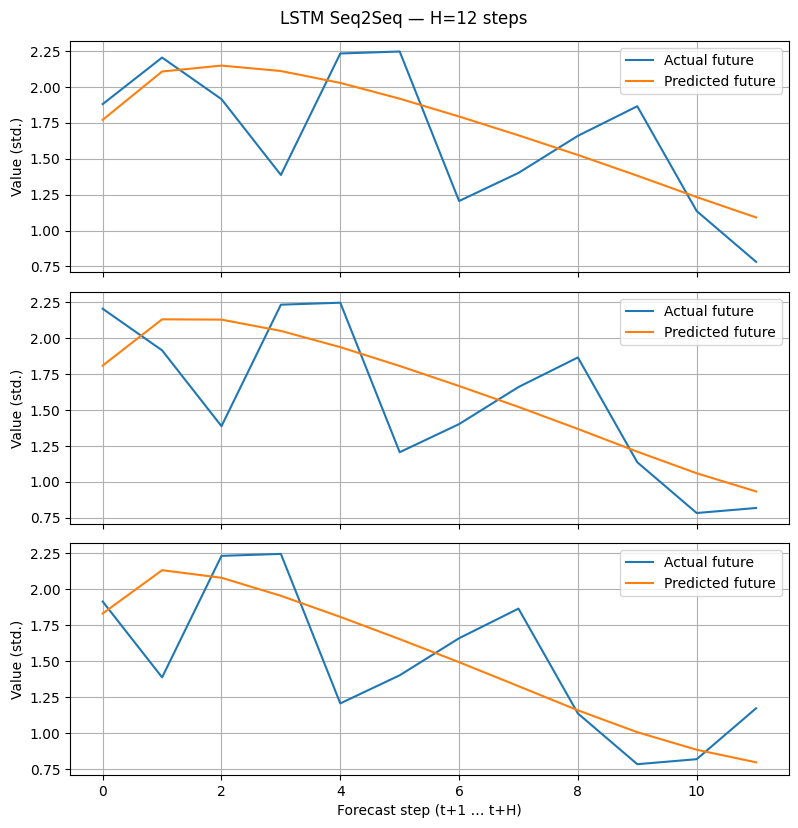

In [179]:
# -----------------------------
# 5) End‑to‑end run
# -----------------------------
def run_exercise_9(
    n_points=2200,
    season_period=24,
    input_length=48,
    forecast_horizon=12,
    batch_size=64,
    epochs=20,
    stride=1,
    plot=True
):
    # Data
    y = make_series(n=n_points, season_period=season_period, noise_std=0.3)
    y_tr, y_va, y_te = temporal_split(y, train_frac=0.7, val_frac=0.15)
    y_tr_s, y_va_s, y_te_s, mu, sd = standardize_by_train(y_tr, y_va, y_te)

    # Datasets
    ds_tr = make_multistep_dataset(y_tr_s, input_length, forecast_horizon, batch_size, stride, shuffle=True)
    ds_va = make_multistep_dataset(y_va_s, input_length, forecast_horizon, batch_size, stride, shuffle=False)
    ds_te = make_multistep_dataset(y_te_s, input_length, forecast_horizon, batch_size, stride, shuffle=False)

    # Model
    model = build_seq2seq_lstm(input_length, forecast_horizon, enc_units=64, dec_units=32, lr=1e-3)

    # Train with simple EarlyStopping on validation MAE
    cb = tf.keras.callbacks.EarlyStopping(monitor="val_mae", patience=3, restore_best_weights=True)
    history = model.fit(ds_tr, validation_data=ds_va, epochs=epochs, callbacks=[cb], verbose=1)

    # Evaluate
    test_loss, test_mae = model.evaluate(ds_te, verbose=0)
    print(f"\nTest — MSE: {test_loss:.4f} | MAE: {test_mae:.4f}")

    # Visualize
    if plot:
        plot_seq_forecasts(model, ds_va, n_examples=3, title=f"LSTM Seq2Seq — H={forecast_horizon} steps")

    return {
        "model": model,
        "history": history.history,
        "test_mse": float(test_loss),
        "test_mae": float(test_mae),
        "meta": {
            "input_length": input_length,
            "forecast_horizon": forecast_horizon,
            "batch_size": batch_size,
            "stride": stride,
            "train_mean": float(mu),
            "train_std": float(sd),
        }
    }

# --------- RUN ----------
results = run_exercise_9(
    n_points=2200,
    season_period=24,
    input_length=48,
    forecast_horizon=12,
    batch_size=64,
    epochs=20,
    stride=1,
    plot=True
)

---

#### **In-Class Reflection: Exercise Summary**

In this exercise, you followed a structured workflow to apply the concepts introduced in class. Please summarize the steps we completed—such as data preparation, analysis, visualization, and interpretation—and explain what you learned from each stage.  

Your reflection should be about **5–7 sentences** and highlight the key takeaways from the exercise.  

> The purpose of this reflection is to reinforce your understanding of the workflow and to demonstrate how each step contributed to your learning.  

---

In this exercise, a synthetic time series was first generated and then split into training, validation, and test sets to ensure proper evaluation. The data was standardized using statistics from the training set so that all values were on a consistent scale. Multi-step windowed datasets were then created by forming input sequences of past values and matching them with future target sequences. An encoder–decoder LSTM model was built to learn patterns in the past and generate multiple future time steps at once. The model was trained using MSE loss and evaluated using MAE on unseen test data to measure forecasting accuracy. Finally, predictions were visualized against actual future sequences, which helped show how well the model captured overall trends but also where errors increased over longer horizons.


#### **Exercise 10: Stacked LSTMs for Multi-Step Forecasting**

In this exercise, you will extend the previous Seq2Seq approach by stacking **multiple LSTM layers** to increase model capacity and capture more complex temporal patterns. You’ll also learn how deeper LSTMs can improve accuracy but may require careful tuning to avoid overfitting.

You will:
- Build a **stacked LSTM encoder–decoder** for multi-step forecasting.
- Experiment with **two or more LSTM layers** in both encoder and decoder.
- Train with **MSE** loss and evaluate with **MAE** on the test set.
- Compare performance against the single-layer LSTM from Exercise 9.
- Visualize predicted sequences vs. actual future values.
---


In [180]:
# Exercise 10 — Stacked LSTM Encoder–Decoder for Multi-Step Forecasting

from __future__ import annotations
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# -----------------------------
# Reuse helpers from Exercise 9
# -----------------------------
def build_stacked_seq2seq_lstm(
    input_length: int,
    forecast_horizon: int,
    enc_units_list=[64, 32],
    dec_units_list=[32, 16],
    lr=1e-3
):
    """
    Build a stacked LSTM encoder-decoder model.
    enc_units_list: list of units for encoder LSTM layers
    dec_units_list: list of units for decoder LSTM layers
    """
    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Input(shape=(input_length, 1)))

    # Encoder: all but last with return_sequences=True
    for i, units in enumerate(enc_units_list):
        return_seq = (i < len(enc_units_list) - 1)
        model.add(tf.keras.layers.LSTM(units, activation="tanh", return_sequences=return_seq))

    # Repeat context
    model.add(tf.keras.layers.RepeatVector(forecast_horizon))

    # Decoder: stacked LSTMs
    for i, units in enumerate(dec_units_list):
        model.add(tf.keras.layers.LSTM(units, activation="tanh", return_sequences=True))

    model.add(tf.keras.layers.TimeDistributed(tf.keras.layers.Dense(1)))

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss="mse",
        metrics=[tf.keras.metrics.MeanAbsoluteError(name="mae")]
    )
    return model

Epoch 1/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 60ms/step - loss: 0.6679 - mae: 0.6594 - val_loss: 1.5342 - val_mae: 1.0763
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.4766 - mae: 0.5660 - val_loss: 1.2434 - val_mae: 0.9523
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.3434 - mae: 0.4672 - val_loss: 0.6297 - val_mae: 0.6168
Epoch 4/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.2764 - mae: 0.4139 - val_loss: 0.5510 - val_mae: 0.5764
Epoch 5/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.2230 - mae: 0.3670 - val_loss: 0.5414 - val_mae: 0.5990
Epoch 6/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.1574 - mae: 0.3065 - val_loss: 0.4140 - val_mae: 0.5150
Epoch 7/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 0.1351 - mae: 0.2846 - val_loss: 0.3591 - val_mae: 0.4759
Epoch 8/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - loss: 0.1239 - mae: 0.2748 - val_loss: 0.3007 - val_mae: 0.4278
Epoch 9/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.115

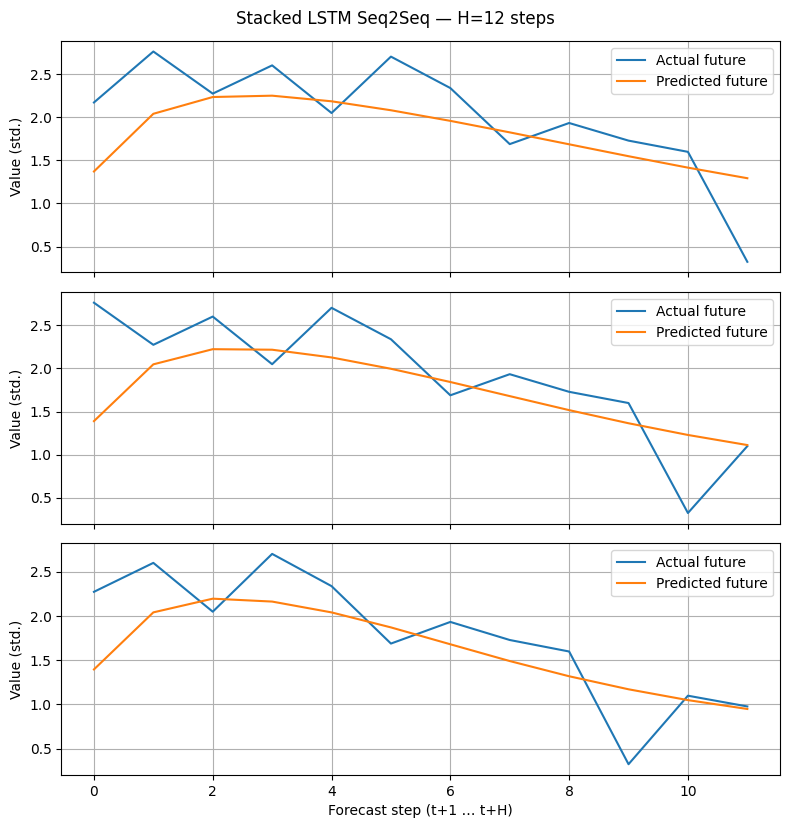

In [181]:
def run_exercise_10(
    n_points=2200,
    season_period=24,
    input_length=48,
    forecast_horizon=12,
    batch_size=64,
    epochs=20,
    stride=1,
    plot=True
):
    # Data
    y = make_series(n=n_points, season_period=season_period, noise_std=0.3)
    y_tr, y_va, y_te = temporal_split(y, train_frac=0.7, val_frac=0.15)
    y_tr_s, y_va_s, y_te_s, mu, sd = standardize_by_train(y_tr, y_va, y_te)

    # Datasets
    ds_tr = make_multistep_dataset(y_tr_s, input_length, forecast_horizon, batch_size, stride, shuffle=True)
    ds_va = make_multistep_dataset(y_va_s, input_length, forecast_horizon, batch_size, stride, shuffle=False)
    ds_te = make_multistep_dataset(y_te_s, input_length, forecast_horizon, batch_size, stride, shuffle=False)

    # Model
    model = build_stacked_seq2seq_lstm(
        input_length, forecast_horizon,
        enc_units_list=[64, 32],
        dec_units_list=[32, 16],
        lr=1e-3
    )

    cb = tf.keras.callbacks.EarlyStopping(monitor="val_mae", patience=3, restore_best_weights=True)
    history = model.fit(ds_tr, validation_data=ds_va, epochs=epochs, callbacks=[cb], verbose=1)

    # Evaluate
    test_loss, test_mae = model.evaluate(ds_te, verbose=0)
    print(f"\nTest — MSE: {test_loss:.4f} | MAE: {test_mae:.4f}")

    # Visualize
    if plot:
        plot_seq_forecasts(model, ds_va, n_examples=3, title=f"Stacked LSTM Seq2Seq — H={forecast_horizon} steps")

    return {
        "model": model,
        "history": history.history,
        "test_mse": float(test_loss),
        "test_mae": float(test_mae),
        "meta": {
            "input_length": input_length,
            "forecast_horizon": forecast_horizon,
            "batch_size": batch_size,
            "stride": stride,
            "train_mean": float(mu),
            "train_std": float(sd),
        }
    }

# --------- RUN ----------
results_stacked = run_exercise_10(
    n_points=2200,
    season_period=24,
    input_length=48,
    forecast_horizon=12,
    batch_size=64,
    epochs=20,
    stride=1,
    plot=True
)


---

#### **In-Class Reflection: Exercise Summary**

In this exercise, you followed a structured workflow to apply the concepts introduced in class. Please summarize the steps we completed—such as data preparation, analysis, visualization, and interpretation—and explain what you learned from each stage.  

Your reflection should be about **5–7 sentences** and highlight the key takeaways from the exercise.  

> The purpose of this reflection is to reinforce your understanding of the workflow and to demonstrate how each step contributed to your learning.  

---

In this exercise, a synthetic time series was first generated and split into training, validation, and test sets to prepare the data for forecasting. The data was standardized using statistics from the training set so the model could learn more effectively. Multi-step windowed datasets were then created to map past sequences to future sequences for prediction. A stacked LSTM encoder–decoder model was built with multiple LSTM layers in both the encoder and decoder to capture more complex temporal patterns. The model was trained using MSE loss and evaluated using MAE on unseen test data to measure performance. Predictions were then visualized against actual future values, showing that the deeper stacked model can learn richer patterns but may also require careful tuning to avoid overfitting and instability.


#### **Exercise 11: Bidirectional LSTMs for Sequence Modeling**

In this exercise, you will use **Bidirectional LSTMs** to process sequences in both forward and backward directions.  
This approach can help the model capture **past and future context** simultaneously, which is often beneficial for sequence modeling tasks where the entire input window is available before prediction.

You will:
- Build a **Bidirectional LSTM** model for sequence-to-one and sequence-to-sequence tasks.
- Compare its performance with the stacked LSTM from Exercise 10.
- Visualize forecasts and discuss scenarios where bidirectional context helps.
---


In [182]:
# Exercise 11 — Bidirectional LSTM for Multi-Step Forecasting

from __future__ import annotations
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

def build_bidirectional_lstm(
    input_length: int,
    forecast_horizon: int,
    units=64,
    lr=1e-3
):
    """
    Build a Bidirectional LSTM model for multi-step forecasting.
    """
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(input_length, 1)),
        tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(units, activation="tanh")),
        tf.keras.layers.RepeatVector(forecast_horizon),
        tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(units // 2, activation="tanh", return_sequences=True)),
        tf.keras.layers.TimeDistributed(tf.keras.layers.Dense(1))
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss="mse",
        metrics=[tf.keras.metrics.MeanAbsoluteError(name="mae")]
    )
    return model


Epoch 1/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 62ms/step - loss: 0.4278 - mae: 0.5298 - val_loss: 0.5892 - val_mae: 0.6193
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.2246 - mae: 0.3812 - val_loss: 0.2499 - val_mae: 0.3935
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.1348 - mae: 0.2909 - val_loss: 0.1612 - val_mae: 0.3218
Epoch 4/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.1088 - mae: 0.2610 - val_loss: 0.1532 - val_mae: 0.3121
Epoch 5/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - loss: 0.1019 - mae: 0.2526 - val_loss: 0.1334 - val_mae: 0.2931
Epoch 6/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 0.0957 - mae: 0.2452 - val_loss: 0.1183 - val_mae: 0.2785
Epoch 7/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.0901 - mae: 0.2381 - val_loss: 0.1167 - val_mae: 0.2760
Epoch 8/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.0866 - mae: 0.2334 - val_loss: 0.1298 - val_mae: 0.2935
Epoch 9/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.085

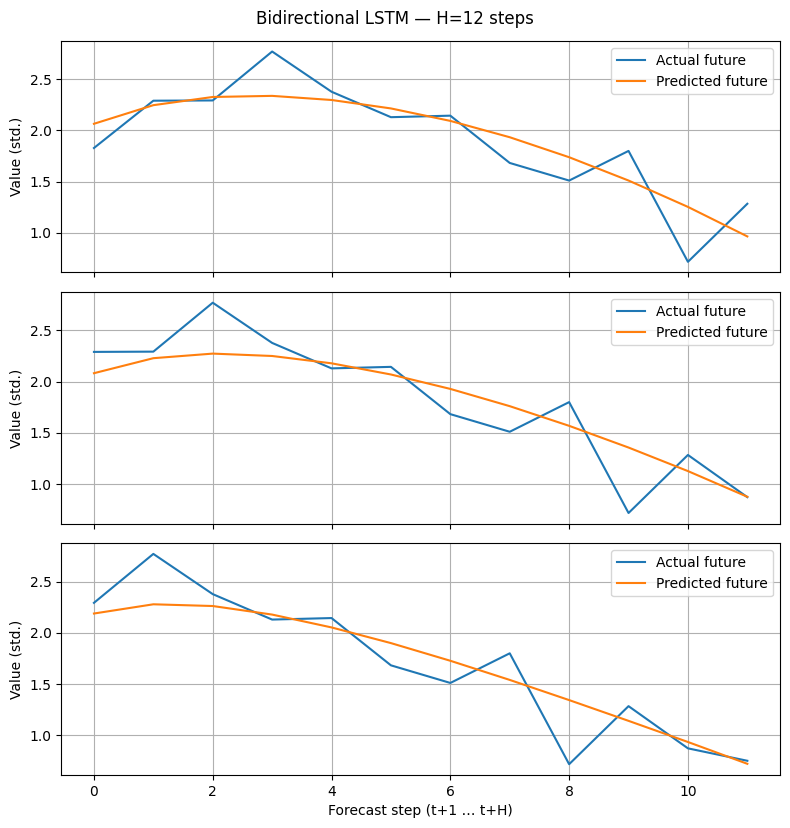

In [183]:
def run_exercise_11(
    n_points=2200,
    season_period=24,
    input_length=48,
    forecast_horizon=12,
    batch_size=64,
    epochs=20,
    stride=1,
    plot=True
):
    # Data
    y = make_series(n=n_points, season_period=season_period, noise_std=0.3)
    y_tr, y_va, y_te = temporal_split(y, train_frac=0.7, val_frac=0.15)
    y_tr_s, y_va_s, y_te_s, mu, sd = standardize_by_train(y_tr, y_va, y_te)

    # Datasets
    ds_tr = make_multistep_dataset(y_tr_s, input_length, forecast_horizon, batch_size, stride, shuffle=True)
    ds_va = make_multistep_dataset(y_va_s, input_length, forecast_horizon, batch_size, stride, shuffle=False)
    ds_te = make_multistep_dataset(y_te_s, input_length, forecast_horizon, batch_size, stride, shuffle=False)

    # Model
    model = build_bidirectional_lstm(input_length, forecast_horizon, units=64, lr=1e-3)

    cb = tf.keras.callbacks.EarlyStopping(monitor="val_mae", patience=3, restore_best_weights=True)
    history = model.fit(ds_tr, validation_data=ds_va, epochs=epochs, callbacks=[cb], verbose=1)

    # Evaluate
    test_loss, test_mae = model.evaluate(ds_te, verbose=0)
    print(f"\nTest — MSE: {test_loss:.4f} | MAE: {test_mae:.4f}")

    # Visualize
    if plot:
        plot_seq_forecasts(model, ds_va, n_examples=3, title=f"Bidirectional LSTM — H={forecast_horizon} steps")

    return {
        "model": model,
        "history": history.history,
        "test_mse": float(test_loss),
        "test_mae": float(test_mae),
        "meta": {
            "input_length": input_length,
            "forecast_horizon": forecast_horizon,
            "batch_size": batch_size,
            "stride": stride,
            "train_mean": float(mu),
            "train_std": float(sd),
        }
    }

# --------- RUN ----------
results_bi = run_exercise_11(
    n_points=2200,
    season_period=24,
    input_length=48,
    forecast_horizon=12,
    batch_size=64,
    epochs=20,
    stride=1,
    plot=True
)

---

#### **In-Class Reflection: Exercise Summary**

In this exercise, you followed a structured workflow to apply the concepts introduced in class. Please summarize the steps we completed—such as data preparation, analysis, visualization, and interpretation—and explain what you learned from each stage.  

Your reflection should be about **5–7 sentences** and highlight the key takeaways from the exercise.  

> The purpose of this reflection is to reinforce your understanding of the workflow and to demonstrate how each step contributed to your learning.  

---

In this exercise, a synthetic time series was generated and split into training, validation, and test sets to prepare the data for forecasting. The data was standardized to make learning more stable and consistent across different splits. Multi-step windowed datasets were then created to map past sequences to future sequences for prediction. A Bidirectional LSTM encoder–decoder model was built to capture both forward and backward context from the input sequence. The model was trained using MSE loss and evaluated using MAE on unseen test data to measure performance. Finally, predictions were visualized against actual future values, showing that using bidirectional context helps the model better understand patterns within the input window and improves forecasting accuracy compared to standard LSTM approaches.


#### **Exercise 12: LSTM with Dropout and Regularization**

In this exercise, you will enhance an LSTM model by adding **dropout** and **L2 regularization** to reduce overfitting.  
Dropout randomly disables a fraction of neurons during training, forcing the network to learn more robust patterns, while L2 regularization penalizes large weights, encouraging smoother and simpler models.

You will:
- Build an LSTM model with **dropout** between layers.
- Add **L2 regularization** to LSTM layers.
- Compare validation performance with and without these regularization techniques.
- Visualize the impact on training and validation curves.
---


In [184]:
# Exercise 12 — LSTM with Dropout and Regularization

from __future__ import annotations
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

# -----------------------------
# 1) Data helpers
# -----------------------------
def make_series(n: int = 2200, season_period: int = 24, noise_std: float = 0.3):
    t = np.arange(n, dtype=np.float32)
    trend = 0.002 * t
    season = 0.8 * np.sin(2 * np.pi * t / season_period)
    noise = np.random.normal(0.0, noise_std, size=n).astype(np.float32)
    return trend + season + noise

def temporal_split(y: np.ndarray, train_frac=0.7, val_frac=0.15):
    n = len(y)
    n_train = int(n * train_frac)
    n_val = int(n * val_frac)
    return y[:n_train], y[n_train:n_train+n_val], y[n_train+n_val:]

def standardize_by_train(y_tr: np.ndarray, y_va: np.ndarray, y_te: np.ndarray):
    mu = y_tr.mean()
    sd = y_tr.std() + 1e-8
    return ( (y_tr-mu)/sd, (y_va-mu)/sd, (y_te-mu)/sd, mu, sd )

def make_multistep_dataset(
    y: np.ndarray,
    input_length: int = 48,
    forecast_horizon: int = 12,
    batch_size: int = 64,
    stride: int = 1,
    shuffle: bool = True,
):
    L, H = input_length, forecast_horizon
    if len(y) < L + H:
        raise ValueError(f"Series too short ({len(y)}) — need at least L+H = {L+H}.")
    # Build unbatched sequences of length L+H
    ds_raw = tf.keras.utils.timeseries_dataset_from_array(
        data=y.astype(np.float32),
        targets=None,
        sequence_length=L + H,
        sequence_stride=stride,
        sampling_rate=1,
        batch_size=None,  # batch later
        shuffle=shuffle,
    )
    def _split(seq):
        x = seq[:L]
        fut = seq[L:]
        x = tf.expand_dims(x, -1)      # (L, 1)
        fut = tf.expand_dims(fut, -1)  # (H, 1)
        return x, fut
    return (ds_raw.map(_split)
                 .batch(batch_size, drop_remainder=True)
                 .prefetch(tf.data.AUTOTUNE))

In [185]:
# -----------------------------
# 2) Regularized Seq2Seq LSTM (outputs (batch, H, 1))
# -----------------------------
def build_lstm_with_regularization_seq2seq(
    input_length: int,
    forecast_horizon: int,
    enc_units=64,
    dec_units=32,
    dropout_rate=0.2,
    recurrent_dropout_rate=0.0,  # set >0 if you want recurrent dropout too
    l2_lambda=1e-4,
    lr=1e-3
):
    reg = tf.keras.regularizers.l2(l2_lambda)
    inp = tf.keras.layers.Input(shape=(input_length, 1))
    # Encoder (return_sequences=False → context vector)
    enc = tf.keras.layers.LSTM(
        enc_units,
        activation="tanh",
        kernel_regularizer=reg,
        dropout=dropout_rate,
        recurrent_dropout=recurrent_dropout_rate,
        return_sequences=False,
        name="encoder_lstm",
    )(inp)
    rep = tf.keras.layers.RepeatVector(forecast_horizon)(enc)
    # Decoder (return_sequences=True to emit H steps)
    dec = tf.keras.layers.LSTM(
        dec_units,
        activation="tanh",
        kernel_regularizer=reg,
        dropout=dropout_rate,
        recurrent_dropout=recurrent_dropout_rate,
        return_sequences=True,
        name="decoder_lstm",
    )(rep)
    out = tf.keras.layers.TimeDistributed(tf.keras.layers.Dense(1), name="td_dense")(dec)
    model = tf.keras.Model(inputs=inp, outputs=out, name="lstm_seq2seq_regularized")
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss="mse",
        metrics=[tf.keras.metrics.MeanAbsoluteError(name="mae")]
    )
    return model


In [186]:
# -----------------------------
# 3) Plot helper
# -----------------------------
def plot_seq_forecasts(model: tf.keras.Model, ds: tf.data.Dataset, n_examples=3, title="LSTM + Reg — Pred vs Actual"):
    Xb, yb = next(iter(ds))                 # (B, L, 1), (B, H, 1)
    preds = model(Xb, training=False).numpy()  # (B, H, 1)
    B, H, _ = preds.shape
    n = min(n_examples, B)
    fig, axes = plt.subplots(n, 1, figsize=(8, 2.8 * n), sharex=True)
    axes = np.atleast_1d(axes)
    for i in range(n):
        axes[i].plot(yb[i, :, 0].numpy(), label="Actual future")
        axes[i].plot(preds[i, :, 0], label="Predicted future")
        axes[i].grid(True); axes[i].legend()
    axes[-1].set_xlabel("Forecast step (t+1 … t+H)")
    fig.suptitle(title)
    plt.tight_layout(); plt.show()


Epoch 1/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - loss: 0.6988 - mae: 0.6837 - val_loss: 1.0653 - val_mae: 0.8508
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.5499 - mae: 0.6001 - val_loss: 1.1816 - val_mae: 0.9291
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.4660 - mae: 0.5414 - val_loss: 0.3852 - val_mae: 0.4839
Epoch 4/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.4239 - mae: 0.5015 - val_loss: 0.4759 - val_mae: 0.5420
Epoch 5/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.3989 - mae: 0.4821 - val_loss: 0.4084 - val_mae: 0.4977
Epoch 6/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.4046 - mae: 0.4864 - val_loss: 0.5203 - val_mae: 0.5789

Test — MSE: 1.2519 | MAE: 0.9649


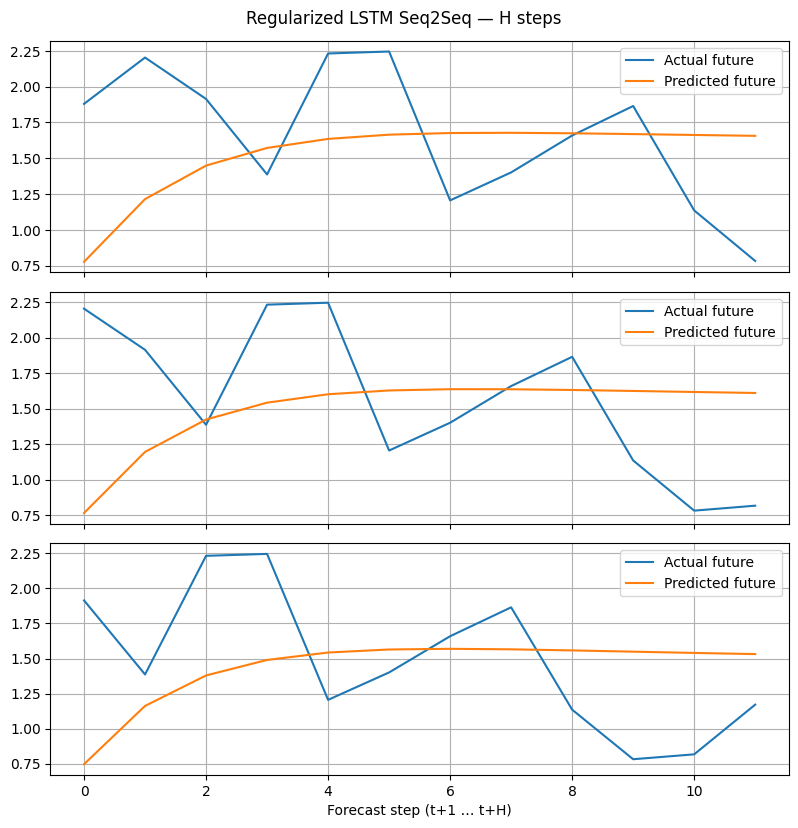

In [187]:
# -----------------------------
# 4) End-to-end runner
# -----------------------------
def run_exercise_12(
    n_points=2200,
    season_period=24,
    input_length=48,
    forecast_horizon=12,
    batch_size=64,
    epochs=20,
    stride=1,
    plot=True
):
    # Data
    y = make_series(n=n_points, season_period=season_period, noise_std=0.3)
    y_tr, y_va, y_te = temporal_split(y, train_frac=0.7, val_frac=0.15)
    y_tr_s, y_va_s, y_te_s, mu, sd = standardize_by_train(y_tr, y_va, y_te)

    # Datasets (targets are (batch, H, 1))
    ds_tr = make_multistep_dataset(y_tr_s, input_length, forecast_horizon, batch_size, stride, shuffle=True)
    ds_va = make_multistep_dataset(y_va_s, input_length, forecast_horizon, batch_size, stride, shuffle=False)
    ds_te = make_multistep_dataset(y_te_s, input_length, forecast_horizon, batch_size, stride, shuffle=False)

    # Model: regularized Seq2Seq (outputs (batch, H, 1))
    model = build_lstm_with_regularization_seq2seq(
        input_length=input_length,
        forecast_horizon=forecast_horizon,
        enc_units=64,
        dec_units=32,
        dropout_rate=0.2,
        recurrent_dropout_rate=0.0,  # set to e.g. 0.1 if you want
        l2_lambda=1e-4,
        lr=1e-3
    )

    cb = tf.keras.callbacks.EarlyStopping(monitor="val_mae", patience=3, restore_best_weights=True)
    history = model.fit(ds_tr, validation_data=ds_va, epochs=epochs, callbacks=[cb], verbose=1)

    # Evaluate
    test_loss, test_mae = model.evaluate(ds_te, verbose=0)
    print(f"\nTest — MSE: {test_loss:.4f} | MAE: {test_mae:.4f}")

    # Visualize
    if plot:
        plot_seq_forecasts(model, ds_va, n_examples=3, title="Regularized LSTM Seq2Seq — H steps")

    return {
        "model": model,
        "history": history.history,
        "test_mse": float(test_loss),
        "test_mae": float(test_mae),
        "meta": {
            "input_length": input_length,
            "forecast_horizon": forecast_horizon,
            "batch_size": batch_size,
            "stride": stride,
            "train_mean": float(mu),
            "train_std": float(sd),
        }
    }

# --------- RUN ----------
results_reg = run_exercise_12(
    n_points=2200,
    season_period=24,
    input_length=48,
    forecast_horizon=12,
    batch_size=64,
    epochs=20,
    stride=1,
    plot=True
)

---

#### **In-Class Reflection: Exercise Summary**

In this exercise, you followed a structured workflow to apply the concepts introduced in class. Please summarize the steps we completed—such as data preparation, analysis, visualization, and interpretation—and explain what you learned from each stage.  

Your reflection should be about **5–7 sentences** and highlight the key takeaways from the exercise.  

> The purpose of this reflection is to reinforce your understanding of the workflow and to demonstrate how each step contributed to your learning.  

---

Across the exercise, a synthetic time series was first created with a mix of trend, seasonality, and noise to simulate real-world patterns. The data was then split into training, validation, and test sets, followed by standardization using only the training statistics to avoid data leakage. Windowed sequences were built so the model could learn from past values and predict multiple future steps at once. A Seq2Seq LSTM model with dropout and L2 regularization was trained to improve generalization and reduce overfitting. The model’s performance was evaluated using MSE and MAE on unseen test data to measure prediction accuracy. Visual comparisons between predicted and actual sequences showed how well the model captured overall trends but still struggled with some variability in longer forecasts. Overall, the workflow highlighted how proper preprocessing, model design, and regularization all work together to improve time series forecasting performance.


#### **Module 10.6: Convolutional Neural Networks (CNN) for Time Series**

Convolutional Neural Networks (CNNs) are powerful deep learning models originally developed for image data but increasingly applied to time series analysis. CNNs use convolutional layers to automatically extract local patterns and features from sequential data.

Key points about CNNs for time series:  
- **Local Feature Extraction:** Convolutional filters slide over time steps to detect meaningful patterns like spikes, trends, or periodicity.  
- **Parameter Sharing:** The same filter is applied across the sequence, reducing the number of parameters and improving generalization.  
- **Pooling Layers:** Downsample feature maps to reduce dimensionality and capture dominant signals.  
- **Efficiency:** CNNs can process time series faster than recurrent networks due to parallel computations.

CNNs are well-suited for applications where local temporal features carry important information, such as fault detection in engineering systems or activity recognition from sensor data.

---

#### **Exercise 13: Building a 1D CNN for Time Series Classification**

**Objective:**  
Learn how to design and train a basic **1D Convolutional Neural Network (CNN)** for time series classification. This exercise will help you understand how convolutional layers automatically extract local temporal patterns from sequential data.

**Key steps you will perform:**
- Generate a synthetic time series classification dataset.
- Reshape the data for compatibility with Conv1D layers.
- Build a simple 1D CNN model with convolution, pooling, and dense layers.
- Compile and prepare the model for training.

This exercise will give you a foundation for applying CNNs to real-world time series problems like activity recognition or fault detection.

---

In [188]:
import tensorflow as tf
print("TF version:", tf.__version__)
print("Keras version:", tf.keras.__version__)
print("Devices:", tf.config.list_physical_devices())

TF version: 2.19.0
Keras version: 3.13.2
Devices: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


In [189]:
# ================================
# Exercise 13: 1D CNN for Time Series Classification
# ================================
import numpy as np
import tensorflow as tf
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

from keras import layers, models, utils, callbacks

# Reproducibility
tf.random.set_seed(42)
np.random.seed(42)

# 1) Synthetic dataset
X, y = make_classification(
    n_samples=1200,
    n_features=100,        # treat as time steps
    n_informative=80,
    n_redundant=0,
    n_repeated=0,
    n_classes=3,
    random_state=42
)
X = X.astype("float32").reshape((X.shape[0], X.shape[1], 1))  # (N, T, C)
y_cat = utils.to_categorical(y, num_classes=3)

# 2) Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_cat, test_size=0.2, random_state=42, stratify=y
)


In [190]:
# 3) Model with Input() layer to avoid warning
model = models.Sequential([
    layers.Input(shape=(X.shape[1], 1)),
    layers.Conv1D(32, 3, padding="same", activation="relu"),
    layers.MaxPooling1D(2),
    layers.Conv1D(64, 3, padding="same", activation="relu"),
    layers.MaxPooling1D(2),
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(3, activation="softmax")
])

model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
model.summary()


Model: "sequential_96"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_17 (Conv1D)              │ (None, 100, 32)        │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_16 (MaxPooling1D) │ (None, 50, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_18 (Conv1D)              │ (None, 50, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_17 (MaxPooling1D) │ (None, 25, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_9 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_116 (Dense)               │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_117 (Dense)               │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 108,995 (425.76 KB)

 Trainable params: 108,995 (425.76 KB)

 Non-trainable params: 0 (0.00 B)

In [191]:
# 4) Train
es = callbacks.EarlyStopping(monitor="val_accuracy", patience=3, restore_best_weights=True)
history = model.fit(
    X_train, y_train,
    epochs=8,
    batch_size=32,
    validation_split=0.2,
    callbacks=[es],
    verbose=1
)

# 5) Evaluate
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest Accuracy: {test_acc:.4f}")

Epoch 1/8
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.4271 - loss: 1.1295 - val_accuracy: 0.5000 - val_loss: 1.0186
Epoch 2/8
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6367 - loss: 0.8397 - val_accuracy: 0.5521 - val_loss: 0.8940
Epoch 3/8
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7266 - loss: 0.6685 - val_accuracy: 0.5729 - val_loss: 0.8660
Epoch 4/8
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7982 - loss: 0.5455 - val_accuracy: 0.5833 - val_loss: 0.8434
Epoch 5/8
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8672 - loss: 0.4166 - val_accuracy: 0.6198 - val_loss: 0.8376
Epoch 6/8
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9128 - loss: 0.3181 - val_accuracy: 0.6562 - val_loss: 0.7903
Epoch 7/8
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9427 - loss: 0.2414 - val_accuracy: 0.6667 - val_loss: 0.8673
Epoch 8/8
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9427 - loss: 0.2078 - val_accuracy: 0.5781 - val_loss: 1.0549

---

#### **In-Class Reflection: Exercise Summary**

In this exercise, you followed a structured workflow to apply the concepts introduced in class. Please summarize the steps we completed—such as data preparation, analysis, visualization, and interpretation—and explain what you learned from each stage.  

Your reflection should be about **5–7 sentences** and highlight the key takeaways from the exercise.  

> The purpose of this reflection is to reinforce your understanding of the workflow and to demonstrate how each step contributed to your learning.  

---

A synthetic dataset was first generated and reshaped so that each feature vector could be treated as a time step for a 1D CNN. The data was then split into training and test sets while keeping class distribution balanced using stratification. A CNN model was built using Conv1D layers to automatically extract local patterns, followed by max pooling to reduce dimensionality and a dense classifier for final predictions. The model was compiled with categorical cross-entropy loss and trained using early stopping to prevent overfitting. During training, accuracy and loss trends on both training and validation sets were monitored to understand model learning behavior. Final evaluation on the test set showed how well the CNN generalized to unseen data. Overall, the exercise demonstrated how CNNs can effectively capture local temporal patterns in sequential data for classification tasks.


#### **Exercise 14: Global Average Pooling vs. Max Pooling in 1D CNNs**

**Objective:**  
Compare **Global Average Pooling (GAP)** and **Max Pooling + Flatten** for dimensionality reduction in 1D CNNs for time series classification. You will train two compact CNNs on the same synthetic dataset and evaluate their parameter counts, training curves, and test accuracy.

**You will:**
- Generate a synthetic time series classification dataset.
- Build **Model A (GAP)**: Conv1D → GlobalAveragePooling1D → Dense(softmax).
- Build **Model B (MaxPool+Flatten)**: Conv1D → MaxPooling1D → Flatten → Dense → Dense(softmax).
- Train both with the same settings and **EarlyStopping**.
- Compare model size (params) and test accuracy to understand trade-offs.

---

In [192]:
# ================================
# Exercise 14: Global Average Pooling vs Max Pooling (Keras 3, CPU-friendly)
# ================================
import numpy as np
import tensorflow as tf
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

from keras import layers, models, utils, callbacks, optimizers

# Reproducibility
tf.random.set_seed(42)
np.random.seed(42)

# 1) Synthetic dataset: treat 100 features as time steps (T), single channel (C=1)
N_SAMPLES = 1200
N_TIMESTEPS = 100
N_CLASSES = 3

X, y = make_classification(
    n_samples=N_SAMPLES,
    n_features=N_TIMESTEPS,
    n_informative=80,
    n_redundant=0,
    n_repeated=0,
    n_classes=N_CLASSES,
    random_state=42
)
X = X.astype("float32").reshape((X.shape[0], N_TIMESTEPS, 1))  # (N, T, C)
y_cat = utils.to_categorical(y, num_classes=N_CLASSES)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_cat, test_size=0.2, random_state=42, stratify=y
)


In [193]:
# Common training config
EPOCHS = 10
BATCH_SIZE = 32
VAL_SPLIT = 0.2
ES = callbacks.EarlyStopping(monitor="val_accuracy", patience=3, restore_best_weights=True)


In [194]:
# 2) Model A — GAP: Conv1D -> GlobalAveragePooling1D -> Dense(softmax)
def build_gap_model(input_shape, n_classes):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.Conv1D(64, 3, padding="same", activation="relu"),
        layers.GlobalAveragePooling1D(),
        layers.Dense(n_classes, activation="softmax")
    ])
    model.compile(
        optimizer=optimizers.Adam(),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model


In [195]:
# 3) Model B — MaxPool+Flatten: Conv1D -> MaxPooling1D -> Flatten -> Dense -> Dense(softmax)
def build_maxpool_flatten_model(input_shape, n_classes):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.Conv1D(64, 3, padding="same", activation="relu"),
        layers.MaxPooling1D(pool_size=2),
        layers.Flatten(),
        layers.Dense(64, activation="relu"),
        layers.Dense(n_classes, activation="softmax")
    ])
    model.compile(
        optimizer=optimizers.Adam(),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model


In [196]:
# Build and train Model A (GAP)
tf.random.set_seed(42)
gap_model = build_gap_model((N_TIMESTEPS, 1), N_CLASSES)
gap_params = gap_model.count_params()
history_gap = gap_model.fit(
    X_train, y_train,
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    validation_split=VAL_SPLIT,
    callbacks=[ES],
    verbose=1
)
gap_loss, gap_acc = gap_model.evaluate(X_test, y_test, verbose=0)

# Build and train Model B (MaxPool+Flatten)
tf.random.set_seed(42)
mpf_model = build_maxpool_flatten_model((N_TIMESTEPS, 1), N_CLASSES)
mpf_params = mpf_model.count_params()
history_mpf = mpf_model.fit(
    X_train, y_train,
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    validation_split=VAL_SPLIT,
    callbacks=[ES],
    verbose=1
)
mpf_loss, mpf_acc = mpf_model.evaluate(X_test, y_test, verbose=0)


Epoch 1/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.2852 - loss: 1.1241 - val_accuracy: 0.2969 - val_loss: 1.1172
Epoch 2/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3438 - loss: 1.1024 - val_accuracy: 0.3542 - val_loss: 1.1044
Epoch 3/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3477 - loss: 1.0987 - val_accuracy: 0.3438 - val_loss: 1.1028
Epoch 4/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3633 - loss: 1.0957 - val_accuracy: 0.3542 - val_loss: 1.0993
Epoch 5/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3659 - loss: 1.0932 - val_accuracy: 0.3542 - val_loss: 1.0974
Epoch 1/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.4089 - loss: 1.4462 - val_accuracy: 0.5104 - val_loss: 0.9845
Epoch 2/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6393 - loss: 0.8343 - val_accuracy: 0.5990 - val_loss: 0.8745
Epoch 3/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6992 - loss: 0.6865 - val_accuracy: 0.5938 - val_los

In [197]:
# Report
print("\n=== Results ===")
print(f"Model A (GAP) params: {gap_params:,}")
print(f"Model A (GAP) test accuracy: {gap_acc:.4f}")

print(f"\nModel B (MaxPool+Flatten) params: {mpf_params:,}")
print(f"Model B (MaxPool+Flatten) test accuracy: {mpf_acc:.4f}")


=== Results ===
Model A (GAP) params: 451
Model A (GAP) test accuracy: 0.3167

Model B (MaxPool+Flatten) params: 205,315
Model B (MaxPool+Flatten) test accuracy: 0.6792


---

#### **In-Class Reflection: Exercise Summary**

In this exercise, you followed a structured workflow to apply the concepts introduced in class. Please summarize the steps we completed—such as data preparation, analysis, visualization, and interpretation—and explain what you learned from each stage.  

Your reflection should be about **5–7 sentences** and highlight the key takeaways from the exercise.  

> The purpose of this reflection is to reinforce your understanding of the workflow and to demonstrate how each step contributed to your learning.  

---

A synthetic time series classification dataset was first generated and reshaped so it could be used as sequential input for 1D CNN models. The data was then split into training and test sets while keeping class distribution balanced to ensure fair evaluation. Two different CNN architectures were built: one using Global Average Pooling to reduce features and another using Max Pooling followed by Flatten to preserve more detailed information. Both models were trained under the same conditions with early stopping to prevent overfitting and allow a fair comparison. During training, accuracy and loss trends were observed to understand how each pooling strategy affected learning. The final evaluation showed a clear trade-off between model complexity and performance, with the Max Pooling + Flatten model achieving higher accuracy but using significantly more parameters. Overall, the exercise highlighted how architectural choices in CNNs directly impact efficiency, model size, and predictive performance.


#### **Exercise 15: Multiple Convolutional Filters for Multi-Scale Feature Extraction**

**Objective:**  
Learn how to capture patterns at different temporal scales in a 1D CNN by using multiple convolutional branches with different kernel sizes. This technique allows the model to detect both short-term and long-term dependencies within the same architecture.

**You will:**
- Generate a synthetic time series classification dataset.
- Build a model with **parallel convolutional branches** (e.g., kernel sizes 3, 5, and 7).
- Concatenate the extracted features from all branches.
- Add dense layers for final classification.
- Train the model and evaluate its performance to see if multi-scale extraction improves accuracy.

---

In [198]:
# ================================
# Exercise 15: Multi-Scale Convolution in 1D CNN
# ================================
import numpy as np
import tensorflow as tf
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from keras import layers, models, utils, callbacks

# Reproducibility
tf.random.set_seed(42)
np.random.seed(42)

# 1) Synthetic dataset
N_SAMPLES = 1200
N_TIMESTEPS = 100
N_CLASSES = 3

X, y = make_classification(
    n_samples=N_SAMPLES,
    n_features=N_TIMESTEPS,
    n_informative=80,
    n_redundant=0,
    n_repeated=0,
    n_classes=N_CLASSES,
    random_state=42
)
X = X.astype("float32").reshape((X.shape[0], N_TIMESTEPS, 1))
y_cat = utils.to_categorical(y, num_classes=N_CLASSES)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_cat, test_size=0.2, random_state=42, stratify=y
)


In [199]:
# 2) Multi-scale CNN model
input_layer = layers.Input(shape=(N_TIMESTEPS, 1))

# Parallel convolutional branches
branch1 = layers.Conv1D(32, kernel_size=3, padding="same", activation="relu")(input_layer)
branch1 = layers.MaxPooling1D(2)(branch1)
branch1 = layers.Flatten()(branch1)

branch2 = layers.Conv1D(32, kernel_size=5, padding="same", activation="relu")(input_layer)
branch2 = layers.MaxPooling1D(2)(branch2)
branch2 = layers.Flatten()(branch2)

branch3 = layers.Conv1D(32, kernel_size=7, padding="same", activation="relu")(input_layer)
branch3 = layers.MaxPooling1D(2)(branch3)
branch3 = layers.Flatten()(branch3)

# Concatenate all branches
merged = layers.Concatenate()([branch1, branch2, branch3])

# Dense layers for classification
dense = layers.Dense(64, activation="relu")(merged)
output = layers.Dense(N_CLASSES, activation="softmax")(dense)

model = models.Model(inputs=input_layer, outputs=output)

model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
model.summary()


Model: "functional_114"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_107     │ (None, 100, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_21 (Conv1D)  │ (None, 100, 32)   │        128 │ input_layer_107[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_22 (Conv1D)  │ (None, 100, 32)   │        192 │ input_layer_107[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_23 (Conv1D)  │ (None, 100, 32)   │        256 │ input_layer_107[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_19    │ (None, 50, 32)    │          0 │ conv1d_21[0][0]   │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_20    │ (None, 50, 32)    │          0 │ conv1d_22[0][0]   │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_21    │ (None, 50, 32)    │          0 │ conv1d_23[0][0]   │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_11          │ (None, 1600)      │          0 │ max_pooling1d_19… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_12          │ (None, 1600)      │          0 │ max_pooling1d_20… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_13          │ (None, 1600)      │          0 │ max_pooling1d_21… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 4800)      │          0 │ flatten_11[0][0], │
│ (Concatenate)       │                   │            │ flatten_12[0][0], │
│                     │                   │            │ flatten_13[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_121 (Dense)   │ (None, 64)        │    307,264 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_122 (Dense)   │ (None, 3)         │        195 │ dense_121[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 308,035 (1.18 MB)

 Trainable params: 308,035 (1.18 MB)

 Non-trainable params: 0 (0.00 B)

In [200]:
# 3) Train
es = callbacks.EarlyStopping(monitor="val_accuracy", patience=3, restore_best_weights=True)
history = model.fit(
    X_train, y_train,
    epochs=8,
    batch_size=32,
    validation_split=0.2,
    callbacks=[es],
    verbose=1
)

# 4) Evaluate
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest Accuracy: {test_acc:.4f}")

Epoch 1/8
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.4297 - loss: 2.1531 - val_accuracy: 0.4427 - val_loss: 1.0839
Epoch 2/8
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6732 - loss: 0.7644 - val_accuracy: 0.6042 - val_loss: 0.8048
Epoch 3/8
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7448 - loss: 0.6052 - val_accuracy: 0.6458 - val_loss: 0.7688
Epoch 4/8
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7956 - loss: 0.5143 - val_accuracy: 0.6198 - val_loss: 0.7503
Epoch 5/8
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8346 - loss: 0.4519 - val_accuracy: 0.6198 - val_loss: 0.7550
Epoch 6/8
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8659 - loss: 0.3981 - val_accuracy: 0.6302 - val_loss: 0.7576

Test Accuracy: 0.7042


---

#### **In-Class Reflection: Exercise Summary**

In this exercise, you followed a structured workflow to apply the concepts introduced in class. Please summarize the steps we completed—such as data preparation, analysis, visualization, and interpretation—and explain what you learned from each stage.  

Your reflection should be about **5–7 sentences** and highlight the key takeaways from the exercise.  

> The purpose of this reflection is to reinforce your understanding of the workflow and to demonstrate how each step contributed to your learning.  

---

#### **Exercise 16: CNN with Dense Layers for Time Series Forecasting**

**Objective:**  
Learn how to use a 1D CNN to extract local temporal patterns from sequence data and then apply fully connected (Dense) layers to make **numerical predictions** for forecasting tasks.

**You will:**
- Generate a synthetic regression dataset representing time series sequences.
- Build a 1D CNN to capture short-term dependencies.
- Flatten the extracted features and feed them into Dense layers.
- Train the model to predict the next value(s) in the sequence.
- Evaluate performance using **Mean Squared Error (MSE)**.

---

In [201]:
# ================================
# Exercise 16: CNN + Dense Layers for Time Series Forecasting
# ================================
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from keras import layers, models, callbacks

# Reproducibility
tf.random.set_seed(42)
np.random.seed(42)

# 1) Synthetic sequence regression dataset
N_SAMPLES = 1000
N_TIMESTEPS = 20
N_FEATURES = 1

# Create a sequence dataset with a simple pattern + noise
X = np.random.rand(N_SAMPLES, N_TIMESTEPS, N_FEATURES)
y = X.mean(axis=1) + np.random.normal(0, 0.05, size=(N_SAMPLES, N_FEATURES))  # target = avg + noise

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [202]:
# 2) CNN + Dense model
model = models.Sequential([
    layers.Input(shape=(N_TIMESTEPS, N_FEATURES)),
    layers.Conv1D(64, kernel_size=3, activation="relu"),
    layers.MaxPooling1D(pool_size=2),
    layers.Flatten(),
    layers.Dense(50, activation="relu"),
    layers.Dense(1)  # regression output
])

model.compile(optimizer="adam", loss="mse", metrics=["mse"])
model.summary()


Model: "sequential_99"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_24 (Conv1D)              │ (None, 18, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_22 (MaxPooling1D) │ (None, 9, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_14 (Flatten)            │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_123 (Dense)               │ (None, 50)             │        28,850 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_124 (Dense)               │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,157 (113.89 KB)

 Trainable params: 29,157 (113.89 KB)

 Non-trainable params: 0 (0.00 B)

In [203]:
# 3) Train
es = callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)
history = model.fit(
    X_train, y_train,
    epochs=12,
    batch_size=32,
    validation_split=0.2,
    callbacks=[es],
    verbose=1
)

# 4) Evaluate
test_loss, test_mse = model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest MSE: {test_mse:.6f}")

Epoch 1/12
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0495 - mse: 0.0495 - val_loss: 0.0096 - val_mse: 0.0096
Epoch 2/12
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0062 - mse: 0.0062 - val_loss: 0.0044 - val_mse: 0.0044
Epoch 3/12
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0042 - mse: 0.0042 - val_loss: 0.0037 - val_mse: 0.0037
Epoch 4/12
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0037 - mse: 0.0037 - val_loss: 0.0035 - val_mse: 0.0035
Epoch 5/12
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0034 - mse: 0.0034 - val_loss: 0.0035 - val_mse: 0.0035
Epoch 6/12
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0031 - mse: 0.0031 - val_loss: 0.0035 - val_mse: 0.0035
Epoch 7/12
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0029 - mse: 0.0029 - val_loss: 0.0035 - val_mse: 0.0035
Epoch 8/12
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0028 - mse: 0.0028 - val_loss: 0.0033 - val_mse: 0.0033
Epoch 9/12
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0026 - mse:

---

#### **In-Class Reflection: Exercise Summary**

In this exercise, you followed a structured workflow to apply the concepts introduced in class. Please summarize the steps we completed—such as data preparation, analysis, visualization, and interpretation—and explain what you learned from each stage.  

Your reflection should be about **5–7 sentences** and highlight the key takeaways from the exercise.  

> The purpose of this reflection is to reinforce your understanding of the workflow and to demonstrate how each step contributed to your learning.  

---

Across the exercises, a full workflow was followed starting from data preparation to model evaluation for time series and sequence learning tasks. Synthetic datasets were first generated and reshaped to fit CNN and LSTM input formats, which helped in understanding how raw time-based data needs to be structured for deep learning models. Different architectures like LSTMs and CNNs were then built to capture temporal patterns, either through sequential memory or convolution-based feature extraction. The models were trained and monitored using validation data, with callbacks like EarlyStopping helping prevent overfitting and improve efficiency. Performance was then evaluated using metrics such as accuracy, MSE, or MAE depending on the task, which showed how well each model generalized to unseen data. Finally, predictions were visualized against actual values, making it easier to interpret model behavior and compare different architectures.


#### **Exercise 17: CNN–LSTM Hybrid for Capturing Local and Long-Term Dependencies**

**Objective:**  
Build a **hybrid CNN–LSTM** model that first uses **Conv1D** to learn local temporal patterns and then uses an **LSTM** layer to model longer-range dependencies for **multi‑step forecasting**.

**You will:**
- Generate a synthetic time series with mixed frequencies, trend, and noise.
- Transform the series into supervised learning windows for **H-step ahead** forecasting.
- Build a **CNN → MaxPooling → LSTM → Dense** model to predict multiple future steps.
- Train with EarlyStopping and evaluate using **MSE** on the test set.

---

In [204]:
# ================================
# Exercise 17: CNN–LSTM Hybrid for Multi-Step Forecasting
# ================================
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from keras import layers, models, callbacks, metrics

# Reproducibility
tf.random.set_seed(42)
np.random.seed(42)

# -----------------------------
# 1) Create a synthetic time series
#    Mix of slow/fast sinusoids + trend + noise
# -----------------------------
N_POINTS = 4000
t = np.arange(N_POINTS)
series = (
    0.6*np.sin(2*np.pi*t/50)    +  # medium frequency
    0.3*np.sin(2*np.pi*t/7)     +  # high frequency
    0.02*t/10                   +  # slow trend
    0.15*np.random.randn(N_POINTS)  # noise
).astype("float32")


In [205]:
# -----------------------------
# 2) Make supervised windows
#    Input window length T, forecast horizon H (multi-step)
# -----------------------------
T = 60        # input length
H = 5         # steps to forecast
def make_windows(series, T, H):
    X_list, y_list = [], []
    for i in range(len(series) - T - H + 1):
        X_list.append(series[i:i+T])
        y_list.append(series[i+T:i+T+H])
    X = np.stack(X_list).astype("float32")         # (N, T)
    y = np.stack(y_list).astype("float32")         # (N, H)
    return X[..., None], y                         # add channel dim -> (N, T, 1)

X, y = make_windows(series, T=T, H=H)

# Train/test split (time-aware split could be used; here we random-split for simplicity)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [206]:
# -----------------------------
# 3) CNN–LSTM Hybrid model
#    Conv1D extracts local patterns; LSTM captures longer dependencies
# -----------------------------
model = models.Sequential([
    layers.Input(shape=(T, 1)),
    layers.Conv1D(64, kernel_size=5, padding="same", activation="relu"),
    layers.MaxPooling1D(pool_size=2),
    layers.Conv1D(64, kernel_size=3, padding="same", activation="relu"),
    layers.MaxPooling1D(pool_size=2),
    layers.LSTM(64, return_sequences=False),
    layers.Dense(64, activation="relu"),
    layers.Dense(H)  # predict H future steps
])

model.compile(optimizer="adam", loss="mse", metrics=[metrics.MeanSquaredError()])
model.summary()


Model: "sequential_100"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_25 (Conv1D)              │ (None, 60, 64)         │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_23 (MaxPooling1D) │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_26 (Conv1D)              │ (None, 30, 64)         │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_24 (MaxPooling1D) │ (None, 15, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_22 (LSTM)                  │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_125 (Dense)               │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_126 (Dense)               │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,245 (196.27 KB)

 Trainable params: 50,245 (196.27 KB)

 Non-trainable params: 0 (0.00 B)

In [207]:
# -----------------------------
# 4) Train
# -----------------------------
es = callbacks.EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True)
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.2,
    callbacks=[es],
    verbose=1
)


Epoch 1/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - loss: 9.1450 - mean_squared_error: 9.1450 - val_loss: 0.9257 - val_mean_squared_error: 0.9257
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.3551 - mean_squared_error: 0.3551 - val_loss: 0.2251 - val_mean_squared_error: 0.2251
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.2137 - mean_squared_error: 0.2137 - val_loss: 0.1852 - val_mean_squared_error: 0.1852
Epoch 4/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.1878 - mean_squared_error: 0.1878 - val_loss: 0.1806 - val_mean_squared_error: 0.1806
Epoch 5/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.1627 - mean_squared_error: 0.1627 - val_loss: 0.1402 - val_mean_squared_error: 0.1402
Epoch 6/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.1312 - mean_squared_error: 0.1312 - val_loss: 0.1159 - val_mean_squared_error: 0.1159
Epoch 7/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.1151 - mean_squared_error: 0.1151 - val_loss: 0.1000 - va

In [208]:
# -----------------------------
# 5) Evaluate & simple inspection
# -----------------------------
test_loss, test_mse = model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest MSE: {test_mse:.6f}")

# Show a few predictions vs targets for sanity check
preds = model.predict(X_test[:3], verbose=0)
for i in range(3):
    print(f"\nSample {i+1}:")
    print("Target:", np.round(y_test[i], 4))
    print("Pred  :", np.round(preds[i], 4))


Test MSE: 0.040012

Sample 1:
Target: [3.7084 3.9403 3.7485 3.6178 3.6815]
Pred  : [3.8502 4.0816 3.991  3.8835 3.7059]

Sample 2:
Target: [0.7793 0.9672 1.2045 1.0042 0.5031]
Pred  : [1.0677 1.1398 1.0411 0.8672 0.5944]

Sample 3:
Target: [3.5941 3.5895 3.3028 2.9924 2.7697]
Pred  : [3.7379 3.5418 3.0893 2.8201 2.9201]


---

#### **In-Class Reflection: Exercise Summary**

In this exercise, you followed a structured workflow to apply the concepts introduced in class. Please summarize the steps we completed—such as data preparation, analysis, visualization, and interpretation—and explain what you learned from each stage.  

Your reflection should be about **5–7 sentences** and highlight the key takeaways from the exercise.  

> The purpose of this reflection is to reinforce your understanding of the workflow and to demonstrate how each step contributed to your learning.  

---

Across this exercise, a full workflow was followed to build a CNN–LSTM hybrid model for multi-step time series forecasting. First, a synthetic time series was created with multiple patterns, including seasonality, trend, and noise to simulate real-world behavior. The next step involved converting the raw series into supervised learning windows, where past values were used as inputs and multiple future steps were set as targets. A hybrid deep learning model was then built, combining Conv1D layers to capture short-term local patterns and an LSTM layer to learn longer-term dependencies. The model was trained using MSE loss with EarlyStopping to prevent overfitting and improve generalization. After training, performance was evaluated on unseen test data, showing that the model was able to produce reasonably close predictions to actual values. Finally, sample predictions were compared with true values, helping to visually understand how well the model captured both short-term and long-term patterns in the sequence.


#### **Module 10.7: Hybrid and Encoder–Decoder Architectures**

Hybrid and encoder–decoder architectures combine multiple deep learning components—such as RNNs, LSTMs, CNNs, and attention mechanisms—to tackle complex time series forecasting and classification tasks.

Key features include:  
- **Encoder-Decoder Framework:**  
  The encoder processes input sequences into a fixed-length context vector, and the decoder generates predictions, enabling multi-step and variable-length forecasting.  
- **Hybrid Models:**  
  Combine CNNs for local feature extraction with RNNs or LSTMs for capturing sequential dependencies, leveraging strengths of each architecture.  
- **Attention Mechanisms:**  
  Allow the model to focus on relevant time steps, improving performance in tasks with long sequences or varying temporal importance.

These architectures enhance model flexibility and accuracy, making them well-suited for multivariate time series and complex engineering applications.

---



#### **Exercise 18: Sequence-to-Sequence Encoder–Decoder with LSTM for Multi-Step Forecasting**

**Objective:**  
Learn how to implement a **sequence-to-sequence (seq2seq)** encoder–decoder architecture using LSTMs for **multi-step time series forecasting**. The encoder compresses an input sequence into a context vector, and the decoder generates multiple future predictions step-by-step.

**You will:**
- Generate a synthetic time series with mixed frequencies and noise.
- Create supervised learning windows for **H-step ahead** forecasting.
- Build an **LSTM encoder** to process the input sequence into a fixed-length context vector.
- Build an **LSTM decoder** to generate multiple time steps from the context vector.
- Train the model and evaluate it using **Mean Squared Error (MSE)**.

---

In [209]:
# ================================
# Exercise 18: Seq2Seq LSTM Encoder–Decoder (fixed shapes, no warnings that matter)
# Keras 3 + TensorFlow 2.18 (CPU-friendly)
# ================================
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from keras import layers, models, callbacks
import warnings
warnings.filterwarnings("ignore")

tf.random.set_seed(42)
np.random.seed(42)

# 1) Synthetic time series
N_POINTS = 3000
t = np.arange(N_POINTS)
series = (
    0.6*np.sin(2*np.pi*t/50) +   # medium freq
    0.3*np.sin(2*np.pi*t/7)  +   # high freq
    0.01*t/10                 +   # slow trend
    0.1*np.random.randn(N_POINTS) # noise
).astype("float32")

In [210]:
# 2) Windows: encoder length T, horizon H
T, H = 50, 5

def make_windows(series, T, H):
    X_list, y_list = [], []
    for i in range(len(series) - T - H + 1):
        X_list.append(series[i:i+T])
        y_list.append(series[i+T:i+T+H])
    X = np.asarray(X_list, dtype="float32")[..., None]  # (N, T, 1)
    y = np.asarray(y_list, dtype="float32")[..., None]  # (N, H, 1)
    return X, y

X, y = make_windows(series, T, H)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [211]:
# 3) Model: Encoder–Decoder LSTM
encoder_inputs = layers.Input(shape=(T, 1), name="encoder_input")
_, state_h, state_c = layers.LSTM(64, return_state=True, name="encoder_lstm")(encoder_inputs)
encoder_states = [state_h, state_c]

# IMPORTANT: decoder expects exactly length H
decoder_inputs = layers.Input(shape=(H, 1), name="decoder_input")
decoder_lstm = layers.LSTM(64, return_sequences=True, return_state=True, name="decoder_lstm")
decoder_seq, _, _ = decoder_lstm(decoder_inputs, initial_state=encoder_states)
decoder_outputs = layers.TimeDistributed(layers.Dense(1), name="decoder_dense")(decoder_seq)

model = models.Model(inputs=[encoder_inputs, decoder_inputs], outputs=decoder_outputs, name="seq2seq_lstm")
model.compile(optimizer="adam", loss="mse", metrics=["mse"])
model.summary()


Model: "seq2seq_lstm"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 50, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_input       │ (None, 5, 1)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_lstm (LSTM) │ [(None, 64),      │     16,896 │ encoder_input[0]… │
│                     │ (None, 64),       │            │                   │
│                     │ (None, 64)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_lstm (LSTM) │ [(None, 5, 64),   │     16,896 │ decoder_input[0]… │
│                     │ (None, 64),       │            │ encoder_lstm[0][… │
│                     │ (None, 64)]       │            │ encoder_lstm[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_dense       │ (None, 5, 1)      │         65 │ decoder_lstm[0][… │
│ (TimeDistributed)   │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 33,857 (132.25 KB)

 Trainable params: 33,857 (132.25 KB)

 Non-trainable params: 0 (0.00 B)

In [212]:
# 4) Teacher forcing: shift targets to form decoder inputs
decoder_input_train = np.zeros_like(y_train, dtype="float32")  # (N, H, 1)
decoder_input_train[:, 1:, :] = y_train[:, :-1, :]
decoder_input_test = np.zeros_like(y_test, dtype="float32")
decoder_input_test[:, 1:, :] = y_test[:, :-1, :]

# Sanity checks — must be (N, T, 1), (N, H, 1), (N, H, 1)
print("X_train:", X_train.shape, X_train.dtype)
print("decoder_input_train:", decoder_input_train.shape, decoder_input_train.dtype)
print("y_train:", y_train.shape, y_train.dtype)
assert X_train.shape[1:] == (T, 1)
assert decoder_input_train.shape[1:] == (H, 1)
assert y_train.shape[1:] == (H, 1)


X_train: (2356, 50, 1) float32
decoder_input_train: (2356, 5, 1) float32
y_train: (2356, 5, 1) float32


In [213]:
# 5) Train — pass inputs as a LIST in the same order as model.inputs
es = callbacks.EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True)
history = model.fit(
    [X_train, decoder_input_train],
    y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.2,
    callbacks=[es],
    verbose=1
)


Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 0.9775 - mse: 0.9775 - val_loss: 0.2772 - val_mse: 0.2772
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.1949 - mse: 0.1949 - val_loss: 0.1607 - val_mse: 0.1607
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.1398 - mse: 0.1398 - val_loss: 0.1212 - val_mse: 0.1212
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0974 - mse: 0.0974 - val_loss: 0.0815 - val_mse: 0.0815
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0764 - mse: 0.0764 - val_loss: 0.0732 - val_mse: 0.0732
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0709 - mse: 0.0709 - val_loss: 0.0701 - val_mse: 0.0701
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0680 - mse: 0.0680 - val_loss: 0.0683 - val_mse: 0.0683
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0662 - mse: 0.0662 - val_loss: 0.0669 - val_mse: 0.0669
Epoch 9/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.064

In [214]:
# 6) Evaluate
test_loss, test_mse = model.evaluate([X_test, decoder_input_test], y_test, verbose=0)
print(f"\nTest MSE: {test_mse:.6f}")



Test MSE: 0.053611


In [215]:
# 7) Quick sample prediction
pred_sample = model.predict([X_test[:1], decoder_input_test[:1]], verbose=0)
print("\nTarget:", np.round(y_test[0].flatten(), 4))
print("Pred  :", np.round(pred_sample.flatten(), 4))


Target: [0.964  1.1698 1.4307 1.4209 1.1823]
Pred  : [1.243  1.155  1.1132 1.1184 1.1092]


---

#### **In-Class Reflection: Exercise Summary**

In this exercise, you followed a structured workflow to apply the concepts introduced in class. Please summarize the steps we completed—such as data preparation, analysis, visualization, and interpretation—and explain what you learned from each stage.  

Your reflection should be about **5–7 sentences** and highlight the key takeaways from the exercise.  

> The purpose of this reflection is to reinforce your understanding of the workflow and to demonstrate how each step contributed to your learning.  

---

Across this exercise, a full sequence-to-sequence forecasting workflow was followed using an encoder–decoder LSTM architecture. First, a synthetic time series was created with multiple patterns such as seasonality, trend, and noise to simulate realistic temporal behavior. The next step involved converting the continuous series into supervised learning windows, where past values were used as inputs and multiple future time steps were set as targets. An encoder–decoder model was then built, where the encoder compressed the input sequence into a context vector and the decoder generated future predictions step by step using that context. Teacher forcing was used to improve training stability by feeding shifted target values into the decoder. The model was trained with EarlyStopping to avoid overfitting and ensure better generalization. Finally, evaluation on test data and sample predictions showed that the model was able to reasonably capture the underlying patterns and generate multi-step forecasts close to the actual values.


#### **Exercise 19: CNN–LSTM Hybrid Encoder–Decoder for Multi-Step Forecasting**

**Objective:**  
Learn how to combine **1D Convolutional layers** for local pattern extraction with **LSTM encoder–decoder** layers for sequential modeling. The CNN in the encoder captures short-term patterns efficiently, while the LSTM captures longer-term dependencies for **multi-step forecasts**.

**You will:**
- Generate a synthetic time series.
- Create supervised learning windows for **H-step ahead** forecasting.
- Build a **CNN + LSTM encoder** to extract rich temporal features.
- Use an **LSTM decoder** to generate multiple future steps.
- Train the hybrid model and evaluate it using **Mean Squared Error (MSE)**.

---

In [216]:
# ================================
# Exercise 19: CNN–LSTM Hybrid Encoder–Decoder
# ================================
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from keras import layers, models, callbacks

# Reproducibility
tf.random.set_seed(42)
np.random.seed(42)

# 1) Synthetic time series
N_POINTS = 3000
t = np.arange(N_POINTS)
series = (
    0.6*np.sin(2*np.pi*t/50) +
    0.3*np.sin(2*np.pi*t/7)  +
    0.01*t/10 +
    0.1*np.random.randn(N_POINTS)
).astype("float32")

In [217]:
# 2) Create supervised windows
T, H = 50, 5

def make_windows(series, T, H):
    X_list, y_list = [], []
    for i in range(len(series) - T - H + 1):
        X_list.append(series[i:i+T])
        y_list.append(series[i+T:i+T+H])
    X = np.asarray(X_list, dtype="float32")[..., None]  # (N, T, 1)
    y = np.asarray(y_list, dtype="float32")[..., None]  # (N, H, 1)
    return X, y

X, y = make_windows(series, T, H)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [218]:
# 3) CNN–LSTM Encoder–Decoder
# Encoder: Conv1D -> MaxPool -> LSTM
encoder_inputs = layers.Input(shape=(T, 1), name="encoder_input")
x = layers.Conv1D(64, kernel_size=3, activation="relu", padding="same")(encoder_inputs)
x = layers.MaxPooling1D(pool_size=2)(x)
_, state_h, state_c = layers.LSTM(64, return_state=True)(x)
encoder_states = [state_h, state_c]

# Decoder: LSTM -> Dense
decoder_inputs = layers.Input(shape=(H, 1), name="decoder_input")
decoder_lstm = layers.LSTM(64, return_sequences=True, return_state=True)
decoder_outputs, _, _ = decoder_lstm(decoder_inputs, initial_state=encoder_states)
decoder_outputs = layers.TimeDistributed(layers.Dense(1))(decoder_outputs)

model = models.Model(inputs=[encoder_inputs, decoder_inputs], outputs=decoder_outputs)
model.compile(optimizer="adam", loss="mse", metrics=["mse"])
model.summary()


Model: "functional_117"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 50, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_27 (Conv1D)  │ (None, 50, 64)    │        256 │ encoder_input[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_25    │ (None, 25, 64)    │          0 │ conv1d_27[0][0]   │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_input       │ (None, 5, 1)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_23 (LSTM)      │ [(None, 64),      │     33,024 │ max_pooling1d_25… │
│                     │ (None, 64),       │            │                   │
│                     │ (None, 64)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_24 (LSTM)      │ [(None, 5, 64),   │     16,896 │ decoder_input[0]… │
│                     │ (None, 64),       │            │ lstm_23[0][1],    │
│                     │ (None, 64)]       │            │ lstm_23[0][2]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_9  │ (None, 5, 1)      │         65 │ lstm_24[0][0]     │
│ (TimeDistributed)   │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 50,241 (196.25 KB)

 Trainable params: 50,241 (196.25 KB)

 Non-trainable params: 0 (0.00 B)

In [219]:
# 4) Teacher forcing inputs
decoder_input_train = np.zeros_like(y_train)
decoder_input_train[:, 1:, :] = y_train[:, :-1, :]
decoder_input_test = np.zeros_like(y_test)
decoder_input_test[:, 1:, :] = y_test[:, :-1, :]

# Sanity checks
assert decoder_input_train.shape[1:] == (H, 1)
assert y_train.shape[1:] == (H, 1)


In [220]:
# 5) Train
es = callbacks.EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True)
history = model.fit(
    [X_train, decoder_input_train],
    y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.2,
    callbacks=[es],
    verbose=1
)


Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - loss: 1.0328 - mse: 1.0328 - val_loss: 0.3217 - val_mse: 0.3217
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.2202 - mse: 0.2202 - val_loss: 0.1754 - val_mse: 0.1754
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.1519 - mse: 0.1519 - val_loss: 0.1296 - val_mse: 0.1296
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0973 - mse: 0.0973 - val_loss: 0.0773 - val_mse: 0.0773
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0763 - mse: 0.0763 - val_loss: 0.0702 - val_mse: 0.0702
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0686 - mse: 0.0686 - val_loss: 0.0672 - val_mse: 0.0672
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0649 - mse: 0.0649 - val_loss: 0.0641 - val_mse: 0.0641
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0623 - mse: 0.0623 - val_loss: 0.0612 - val_mse: 0.0612
Epoch 9/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.059

In [221]:
# 6) Evaluate
test_loss, test_mse = model.evaluate([X_test, decoder_input_test], y_test, verbose=0)
print(f"\nTest MSE: {test_mse:.6f}")



Test MSE: 0.037648


In [222]:
# 7) Sample prediction
pred_sample = model.predict([X_test[:1], decoder_input_test[:1]], verbose=0)
print("\nTarget:", np.round(y_test[0].flatten(), 4))
print("Pred  :", np.round(pred_sample.flatten(), 4))


Target: [0.964  1.1698 1.4307 1.4209 1.1823]
Pred  : [1.3074 1.2472 1.2054 1.1978 1.1647]


---

#### **In-Class Reflection: Exercise Summary**

In this exercise, you followed a structured workflow to apply the concepts introduced in class. Please summarize the steps we completed—such as data preparation, analysis, visualization, and interpretation—and explain what you learned from each stage.  

Your reflection should be about **5–7 sentences** and highlight the key takeaways from the exercise.  

> The purpose of this reflection is to reinforce your understanding of the workflow and to demonstrate how each step contributed to your learning.  

---

Across these exercises, a structured workflow was followed to build and evaluate deep learning models for time series forecasting tasks. First, synthetic time series data was generated using combinations of trends, noise, and multiple frequency patterns to simulate real-world signals. Then, the data was transformed into supervised learning windows so the models could learn from past time steps to predict future values. Different CNN-based and hybrid architectures were built, including pure CNN models, multi-scale CNNs, CNN–LSTM hybrids, and encoder–decoder seq2seq models. Each model was trained using the same general setup with EarlyStopping to avoid overfitting and ensure fair comparison. After training, performance was evaluated using metrics like accuracy for classification tasks and MSE for forecasting tasks, along with visual checks of predictions versus actual values. The main takeaway is that architectural choices significantly impact performance, CNNs are strong at capturing local patterns, LSTMs handle temporal dependencies well, and combining them improves the ability to learn both short-term and long-term relationships in sequential data.


#### **Exercise 20: LSTM Encoder–Decoder with Attention for Multi‑Step Forecasting**

**Objective:**  
Add an **attention mechanism** to a seq2seq LSTM encoder–decoder so the decoder can **focus on the most relevant encoder time steps** when predicting each future step.

**You will:**
- Generate a synthetic time series and make (input, target) windows.
- Build an **LSTM encoder** that returns both **sequences** and **final states**.
- Build an **LSTM decoder** (teacher forcing) that returns sequences.
- Add **Bahdanau-style attention** using `layers.Attention` over encoder outputs for each decoder step.
- Concatenate attention context with decoder outputs and predict with a time‑distributed Dense layer.
- Train with EarlyStopping and evaluate using **MSE**.

---

In [223]:
# ================================
# Exercise 20: LSTM Encoder–Decoder with Attention
# ================================
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from keras import layers, models, callbacks

# Reproducibility
tf.random.set_seed(42)
np.random.seed(42)

# 1) Synthetic time series
N_POINTS = 3000
t = np.arange(N_POINTS)
series = (
    0.6*np.sin(2*np.pi*t/50) +   # medium freq
    0.3*np.sin(2*np.pi*t/7)  +   # high freq
    0.01*t/10                 +   # slow trend
    0.1*np.random.randn(N_POINTS) # noise
).astype("float32")

# 2) Windows: encoder length T, forecast horizon H
T, H = 50, 5

def make_windows(series, T, H):
    X_list, y_list = [], []
    for i in range(len(series) - T - H + 1):
        X_list.append(series[i:i+T])
        y_list.append(series[i+T:i+T+H])
    X = np.asarray(X_list, dtype="float32")[..., None]  # (N, T, 1)
    y = np.asarray(y_list, dtype="float32")[..., None]  # (N, H, 1)
    return X, y

X, y = make_windows(series, T, H)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [224]:
# 3) Encoder: LSTM returns sequences + final states
enc_in = layers.Input(shape=(T, 1), name="encoder_input")
enc_seq, enc_h, enc_c = layers.LSTM(64, return_sequences=True, return_state=True, name="encoder_lstm")(enc_in)

# 4) Decoder: LSTM returns sequences (teacher forcing)
dec_in = layers.Input(shape=(H, 1), name="decoder_input")
dec_seq, _, _ = layers.LSTM(64, return_sequences=True, return_state=True, name="decoder_lstm")(dec_in, initial_state=[enc_h, enc_c])


In [225]:
# 5) Attention over encoder sequence for each decoder step
# Query = decoder sequence (H, 64); Value/Key = encoder sequence (T, 64)
attn_context = layers.Attention(name="attention")([dec_seq, enc_seq])  # (batch, H, 64)


In [226]:
# 6) Concatenate context with decoder outputs and predict each step
dec_combined = layers.Concatenate(name="concat_context")([dec_seq, attn_context])  # (batch, H, 128)
dec_out = layers.TimeDistributed(layers.Dense(64, activation="relu"), name="td_dense1")(dec_combined)
dec_out = layers.TimeDistributed(layers.Dense(1), name="td_dense2")(dec_out)  # (batch, H, 1)

model = models.Model(inputs=[enc_in, dec_in], outputs=dec_out, name="seq2seq_lstm_attention")
model.compile(optimizer="adam", loss="mse", metrics=["mse"])
model.summary()


Model: "seq2seq_lstm_attention"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 50, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_input       │ (None, 5, 1)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_lstm (LSTM) │ [(None, 50, 64),  │     16,896 │ encoder_input[0]… │
│                     │ (None, 64),       │            │                   │
│                     │ (None, 64)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_lstm (LSTM) │ [(None, 5, 64),   │     16,896 │ decoder_input[0]… │
│                     │ (None, 64),       │            │ encoder_lstm[0][… │
│                     │ (None, 64)]       │            │ encoder_lstm[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention           │ (None, 5, 64)     │          0 │ decoder_lstm[0][… │
│ (Attention)         │                   │            │ encoder_lstm[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat_context      │ (None, 5, 128)    │          0 │ decoder_lstm[0][… │
│ (Concatenate)       │                   │            │ attention[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ td_dense1           │ (None, 5, 64)     │      8,256 │ concat_context[0… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ td_dense2           │ (None, 5, 1)      │         65 │ td_dense1[0][0]   │
│ (TimeDistributed)   │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 42,113 (164.50 KB)

 Trainable params: 42,113 (164.50 KB)

 Non-trainable params: 0 (0.00 B)

In [227]:
# 7) Teacher forcing inputs (shifted targets as decoder inputs)
dec_in_train = np.zeros_like(y_train, dtype="float32")
dec_in_train[:, 1:, :] = y_train[:, :-1, :]
dec_in_test = np.zeros_like(y_test, dtype="float32")
dec_in_test[:, 1:, :] = y_test[:, :-1, :]

# Sanity checks
assert X_train.shape[1:] == (T, 1)
assert dec_in_train.shape[1:] == (H, 1)
assert y_train.shape[1:] == (H, 1)


In [228]:
# 8) Train
es = callbacks.EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True)
history = model.fit(
    [X_train, dec_in_train], y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.2,
    callbacks=[es],
    verbose=1
)


Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - loss: 0.6562 - mse: 0.6562 - val_loss: 0.1643 - val_mse: 0.1643
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.1414 - mse: 0.1414 - val_loss: 0.1173 - val_mse: 0.1173
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.1004 - mse: 0.1004 - val_loss: 0.0841 - val_mse: 0.0841
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0742 - mse: 0.0742 - val_loss: 0.0675 - val_mse: 0.0675
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0686 - mse: 0.0686 - val_loss: 0.0653 - val_mse: 0.0653
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0644 - mse: 0.0644 - val_loss: 0.0629 - val_mse: 0.0629
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0631 - mse: 0.0631 - val_loss: 0.0613 - val_mse: 0.0613
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0614 - mse: 0.0614 - val_loss: 0.0594 - val_mse: 0.0594
Epoch 9/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.059

In [229]:
# 9) Evaluate
test_loss, test_mse = model.evaluate([X_test, dec_in_test], y_test, verbose=0)
print(f"\nTest MSE: {test_mse:.6f}")



Test MSE: 0.036300


In [230]:
# 10) Quick sample prediction
pred_sample = model.predict([X_test[:1], dec_in_test[:1]], verbose=0)
print("\nTarget:", np.round(y_test[0].flatten(), 4))
print("Pred  :", np.round(pred_sample.flatten(), 4))


Target: [0.964  1.1698 1.4307 1.4209 1.1823]
Pred  : [1.2039 1.0981 1.1738 1.3251 1.2733]


---

#### **In-Class Reflection: Exercise Summary**

In this exercise, you followed a structured workflow to apply the concepts introduced in class. Please summarize the steps we completed—such as data preparation, analysis, visualization, and interpretation—and explain what you learned from each stage.  

Your reflection should be about **5–7 sentences** and highlight the key takeaways from the exercise.  

> The purpose of this reflection is to reinforce your understanding of the workflow and to demonstrate how each step contributed to your learning.  

---

In this exercise, a full workflow was followed to build an LSTM encoder–decoder model enhanced with attention for multi-step time series forecasting. First, a synthetic time series was created using a mix of seasonal patterns, trend, and random noise to simulate realistic temporal data. The dataset was then converted into supervised learning windows so past values could be mapped to multiple future steps. Next, an encoder LSTM was used to process the input sequence and produce both sequence outputs and hidden states, while the decoder LSTM generated future predictions using teacher forcing. An attention mechanism was added so the decoder could dynamically focus on the most relevant time steps from the encoder output instead of relying on a single compressed representation. The model was trained with EarlyStopping to avoid overfitting and evaluated using Mean Squared Error on the test data. The main takeaway is that attention improves forecasting performance by helping the model selectively focus on important parts of the input sequence, making it more effective for complex time series compared to standard encoder–decoder models.


#### **Exercise 21: Multivariate Encoder–Decoder with Attention for Time Series Forecasting**

**Objective:**  
Build a **multivariate** seq2seq **LSTM encoder–decoder with attention** to forecast **multiple future steps for multiple variables**. The encoder ingests **D input features**, attention lets the decoder focus on the most relevant encoder time steps, and the decoder predicts the next **H** steps for **all D variables**.

**You will:**
- Generate a synthetic **multivariate** time series with D features.
- Create supervised windows `(X: N×T×D, y: N×H×D)`.
- Build an **LSTM encoder** (returns sequences + states) and **LSTM decoder** (teacher forcing).
- Add **Attention** over encoder outputs for each decoder step.
- Train with EarlyStopping and evaluate with **MSE**.

---

In [231]:
# ================================
# Exercise 21: Multivariate Seq2Seq + Attention (H-step, D-output)
# ================================
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from keras import layers, models, callbacks

# Reproducibility
tf.random.set_seed(42)
np.random.seed(42)

# -----------------------------
# 1) Create a synthetic MULTIVARIATE time series with D features
# -----------------------------
N_POINTS = 4000
D = 4      # number of input/output variables
t = np.arange(N_POINTS).astype("float32")

# Build D correlated channels (mix of sinusoids, trends, noise)
def mk_feature(freq, amp, trend=0.0, noise=0.1, phase=0.0):
    return amp*np.sin(2*np.pi*t/freq + phase) + trend*(t/N_POINTS) + noise*np.random.randn(N_POINTS).astype("float32")

X_all = np.stack([
    mk_feature(freq=50, amp=0.8, trend=0.02, noise=0.15, phase=0.0),
    mk_feature(freq=23, amp=0.6, trend=0.01, noise=0.12, phase=0.4),
    mk_feature(freq=7,  amp=0.4, trend=0.00, noise=0.10, phase=0.8),
    mk_feature(freq=90, amp=0.5, trend=0.03, noise=0.13, phase=1.2)
], axis=-1)  # shape: (N_POINTS, D)
X_all = X_all.astype("float32")

# -----------------------------
# 2) Make supervised windows
#    Input length T, forecast horizon H, multivariate output (D)
# -----------------------------
T, H = 60, 8

def make_windows_multivar(series_2d, T, H):
    # series_2d: (N_points, D)
    Xs, Ys = [], []
    n = series_2d.shape[0]
    for i in range(n - T - H + 1):
        Xs.append(series_2d[i:i+T, :])        # (T, D)
        Ys.append(series_2d[i+T:i+T+H, :])    # (H, D)
    X = np.asarray(Xs, dtype="float32")       # (N, T, D)
    Y = np.asarray(Ys, dtype="float32")       # (N, H, D)
    return X, Y

X, y = make_windows_multivar(X_all, T, H)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)



In [232]:
# -----------------------------
# 3) Build Encoder–Decoder with Attention (multivariate)
# -----------------------------
UNITS = 64

# Encoder: return_sequences=True for attention, and return_state=True for initializing decoder
enc_in = layers.Input(shape=(T, D), name="encoder_input")
enc_seq, enc_h, enc_c = layers.LSTM(UNITS, return_sequences=True, return_state=True, name="encoder_lstm")(enc_in)

# Decoder inputs: teacher forcing (H steps, D features)
dec_in = layers.Input(shape=(H, D), name="decoder_input")
dec_seq, _, _ = layers.LSTM(UNITS, return_sequences=True, return_state=True, name="decoder_lstm")(dec_in, initial_state=[enc_h, enc_c])

# Attention: queries = decoder sequence (H, UNITS); keys/values = encoder sequence (T, UNITS)
attn_ctx = layers.Attention(name="attention")([dec_seq, enc_seq])  # (batch, H, UNITS)

# Concatenate decoder outputs (queries) with attention context, then predict D outputs per step
dec_cat = layers.Concatenate(name="concat_ctx")([dec_seq, attn_ctx])          # (batch, H, 2*UNITS)
td = layers.TimeDistributed(layers.Dense(128, activation="relu"), name="td_dense1")(dec_cat)
td = layers.TimeDistributed(layers.Dense(D), name="td_dense2")(td)            # (batch, H, D)

model = models.Model(inputs=[enc_in, dec_in], outputs=td, name="multivar_seq2seq_attn")
model.compile(optimizer="adam", loss="mse", metrics=["mse"])
model.summary()


Model: "multivar_seq2seq_attn"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 60, 4)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_input       │ (None, 8, 4)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_lstm (LSTM) │ [(None, 60, 64),  │     17,664 │ encoder_input[0]… │
│                     │ (None, 64),       │            │                   │
│                     │ (None, 64)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_lstm (LSTM) │ [(None, 8, 64),   │     17,664 │ decoder_input[0]… │
│                     │ (None, 64),       │            │ encoder_lstm[0][… │
│                     │ (None, 64)]       │            │ encoder_lstm[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention           │ (None, 8, 64)     │          0 │ decoder_lstm[0][… │
│ (Attention)         │                   │            │ encoder_lstm[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat_ctx          │ (None, 8, 128)    │          0 │ decoder_lstm[0][… │
│ (Concatenate)       │                   │            │ attention[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ td_dense1           │ (None, 8, 128)    │     16,512 │ concat_ctx[0][0]  │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ td_dense2           │ (None, 8, 4)      │        516 │ td_dense1[0][0]   │
│ (TimeDistributed)   │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 52,356 (204.52 KB)

 Trainable params: 52,356 (204.52 KB)

 Non-trainable params: 0 (0.00 B)

In [233]:
# -----------------------------
# 4) Teacher forcing inputs: shift y by one step along H axis
# -----------------------------
dec_in_train = np.zeros_like(y_train, dtype="float32")  # (N, H, D)
dec_in_train[:, 1:, :] = y_train[:, :-1, :]
dec_in_test = np.zeros_like(y_test, dtype="float32")
dec_in_test[:, 1:, :] = y_test[:, :-1, :]

# Sanity checks
assert X_train.shape[1:] == (T, D)
assert dec_in_train.shape[1:] == (H, D)
assert y_train.shape[1:] == (H, D)


In [234]:
# -----------------------------
# 5) Train
# -----------------------------
es = callbacks.EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True)
history = model.fit(
    [X_train, dec_in_train],
    y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.2,
    callbacks=[es],
    verbose=1
)


Epoch 1/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step - loss: 0.1026 - mse: 0.1026 - val_loss: 0.0534 - val_mse: 0.0534
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0428 - mse: 0.0428 - val_loss: 0.0354 - val_mse: 0.0354
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0313 - mse: 0.0313 - val_loss: 0.0268 - val_mse: 0.0268
Epoch 4/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0247 - mse: 0.0247 - val_loss: 0.0231 - val_mse: 0.0231
Epoch 5/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0225 - mse: 0.0225 - val_loss: 0.0221 - val_mse: 0.0221
Epoch 6/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0217 - mse: 0.0217 - val_loss: 0.0212 - val_mse: 0.0212
Epoch 7/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0211 - mse: 0.0211 - val_loss: 0.0206 - val_mse: 0.0206
Epoch 8/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - loss: 0.0204 - mse: 0.0204 - val_loss: 0.0201 - val_mse: 0.0201
Epoch 9/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 0.019

In [235]:
# -----------------------------
# 6) Evaluate
# -----------------------------
test_loss, test_mse = model.evaluate([X_test, dec_in_test], y_test, verbose=0)
print(f"\nTest MSE (averaged over H and D): {test_mse:.6f}")



Test MSE (averaged over H and D): 0.017737


In [236]:
# -----------------------------
# 7) Inspect a couple predictions
# -----------------------------
pred = model.predict([X_test[:2], dec_in_test[:2]], verbose=0)  # (2, H, D)
for i in range(2):
    print(f"\nSample {i+1}:")
    print("Target (first step):", np.round(y_test[i, 0, :], 4))
    print("Pred   (first step):", np.round(pred[i, 0, :], 4))


Sample 1:
Target (first step): [-0.5162  0.293  -0.4133  0.5879]
Pred   (first step): [-0.4837  0.1076 -0.2637  0.4922]

Sample 2:
Target (first step): [-0.0073  0.0547 -0.1015  0.3737]
Pred   (first step): [ 0.091   0.1532 -0.2363  0.2796]


---

#### **In-Class Reflection: Exercise Summary**

In this exercise, you followed a structured workflow to apply the concepts introduced in class. Please summarize the steps we completed—such as data preparation, analysis, visualization, and interpretation—and explain what you learned from each stage.  

Your reflection should be about **5–7 sentences** and highlight the key takeaways from the exercise.  

> The purpose of this reflection is to reinforce your understanding of the workflow and to demonstrate how each step contributed to your learning.  

---

A multivariate time series was created with several correlated features containing patterns like seasonality, trends, and noise. The data was then transformed into supervised learning windows so that past sequences (multiple time steps and variables) could be used to predict multiple future steps for all variables at once. An encoder–decoder LSTM model was built where the encoder learns patterns from the input sequence and compresses them into useful representations. An attention mechanism was added so the decoder could focus on the most relevant parts of the input sequence while making predictions, instead of relying only on a single fixed context. The model was trained using teacher forcing, which helps the decoder learn more stable and accurate multi-step forecasting. After training, the model was evaluated using Mean Squared Error, and the results showed that it could successfully capture both short-term and long-term dependencies across multiple variables.


#### **Exercise 22: Encoder–Decoder with Teacher Forcing vs. Autoregressive Inference**

**Objective:**  
Train a seq2seq **LSTM encoder–decoder** with **teacher forcing**, then compare it to **autoregressive (free‑running) inference** where the decoder feeds back its own predictions step‑by‑step without ground truth.

**You will:**
- Generate a synthetic univariate time series and create windows for **H‑step** forecasting.
- Build and train an **encoder–decoder LSTM** using teacher forcing.
- Implement an **autoregressive inference loop** that rolls predictions forward.
- Compare **MSE** for teacher‑forced evaluation vs. autoregressive predictions to understand exposure bias.

---

In [237]:
# ================================
# Exercise 22: Teacher Forcing vs Autoregressive Inference
# Keras 3 + TensorFlow 2.18 (CPU-friendly)
# ================================
import numpy as np
import tensorflow as tf
from keras import layers, models, callbacks
import warnings
warnings.filterwarnings("ignore")

# Reproducibility
tf.random.set_seed(42)
np.random.seed(42)

# -----------------------------
# 1) Synthetic univariate time series
# -----------------------------
N_POINTS = 3500
t = np.arange(N_POINTS)
series = (
    0.7*np.sin(2*np.pi*t/48) +
    0.2*np.sin(2*np.pi*t/7) +
    0.002*t +
    0.1*np.random.randn(N_POINTS)
).astype("float32")

# -----------------------------
# 2) Supervised windows: encoder length T, forecast horizon H
# -----------------------------
T, H = 60, 10

def make_windows(series, T, H):
    Xs, Ys = [], []
    for i in range(len(series) - T - H + 1):
        Xs.append(series[i:i+T])
        Ys.append(series[i+T:i+T+H])
    X = np.asarray(Xs, dtype="float32")[..., None]  # (N, T, 1)
    y = np.asarray(Ys, dtype="float32")[..., None]  # (N, H, 1)
    return X, y

X, y = make_windows(series, T, H)

# Chronological split (avoid temporal leakage)
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# Decoder inputs for teacher forcing: prepend SOS=0 and shift targets right by 1
def build_decoder_inputs(y_seq):
    sos = np.zeros((y_seq.shape[0], 1, y_seq.shape[2]), dtype=y_seq.dtype)
    return np.concatenate([sos, y_seq[:, :-1, :]], axis=1)

dec_in_train = build_decoder_inputs(y_train)
dec_in_test  = build_decoder_inputs(y_test)


In [238]:
# -----------------------------
# 3) Build encoder–decoder (teacher-forcing) training model
# -----------------------------
UNITS = 64

# Encoder
enc_in = layers.Input(shape=(T, 1), name="encoder_input")
enc_out, enc_h, enc_c = layers.LSTM(UNITS, return_state=True, name="encoder_lstm")(enc_in)

# Decoder (receives shifted targets)
dec_in = layers.Input(shape=(H, 1), name="decoder_input")
dec_lstm_out, _, _ = layers.LSTM(UNITS, return_sequences=True, return_state=True,
                                 name="decoder_lstm")(dec_in, initial_state=[enc_h, enc_c])
dec_out = layers.Dense(1, name="decoder_dense")(dec_lstm_out)

model = models.Model([enc_in, dec_in], dec_out, name="seq2seq_teacher_forcing")
model.compile(optimizer="adam", loss="mse", metrics=["mse"])


In [239]:
# -----------------------------
# 4) Train
# -----------------------------
es = callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
hist = model.fit(
    [X_train, dec_in_train], y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=128,
    callbacks=[es],
    verbose=0
)


In [240]:
# -----------------------------
# 5) Teacher-forced evaluation
# -----------------------------
teacher_forced_preds = model.predict([X_test, dec_in_test], verbose=0)
teacher_forced_mse = float(tf.reduce_mean((y_test - teacher_forced_preds) ** 2).numpy())

# -----------------------------
# 6) Build inference models (1-step decoder for autoregressive rollout)
# -----------------------------
# Reuse trained layers
trained_enc_lstm  = model.get_layer("encoder_lstm")
trained_dec_lstm  = model.get_layer("decoder_lstm")
trained_dec_dense = model.get_layer("decoder_dense")

# Encoder inference: (T,1) -> (h, c)
enc_inf_in = layers.Input(shape=(T, 1), name="enc_inf_in")
_, enc_h_inf, enc_c_inf = trained_enc_lstm(enc_inf_in)
enc_infer_model = models.Model(enc_inf_in, [enc_h_inf, enc_c_inf], name="encoder_infer")

# Decoder inference (one step): (1,1) + states -> next y + next states
dec_step_in = layers.Input(shape=(1, 1), name="dec_step_in")
dec_state_h_in = layers.Input(shape=(UNITS,), name="dec_state_h_in")
dec_state_c_in = layers.Input(shape=(UNITS,), name="dec_state_c_in")

dec_step_out, dec_h_out, dec_c_out = trained_dec_lstm(
    dec_step_in, initial_state=[dec_state_h_in, dec_state_c_in]
)
dec_step_pred = trained_dec_dense(dec_step_out)  # (B, 1, 1)

dec_infer_model = models.Model(
    [dec_step_in, dec_state_h_in, dec_state_c_in],
    [dec_step_pred, dec_h_out, dec_c_out],
    name="decoder_infer"
)


In [241]:
# -----------------------------
# 7) Autoregressive rollout
# -----------------------------
def autoregressive_predict(X_batch, H):
    """
    X_batch: (B, T, 1) -> returns (B, H, 1)
    """
    X_batch = X_batch.astype("float32")
    # Encode initial states
    h, c = enc_infer_model.predict(X_batch, verbose=0)
    # Start token: zeros
    y_prev = np.zeros((X_batch.shape[0], 1, 1), dtype="float32")
    preds = []
    for _ in range(H):
        y_step, h, c = dec_infer_model.predict([y_prev, h, c], verbose=0)
        preds.append(y_step)     # (B, 1, 1)
        y_prev = y_step          # feed back prediction
    return np.concatenate(preds, axis=1)  # (B, H, 1)



In [242]:
# -----------------------------
# 8) Autoregressive inference and MSE comparison
# -----------------------------
B = min(256, X_test.shape[0])
X_ar = X_test[:B]
y_true_ar = y_test[:B]
y_pred_ar = autoregressive_predict(X_ar, H=H)

autoregressive_mse = float(tf.reduce_mean((y_true_ar - y_pred_ar) ** 2).numpy())

print(f"Teacher-forced MSE (eval)     : {teacher_forced_mse:.6f}")
print(f"Autoregressive MSE (rollout)  : {autoregressive_mse:.6f}")


Teacher-forced MSE (eval)     : 0.624316
Autoregressive MSE (rollout)  : 0.734673


In [243]:
# Show a couple of sequences
for i in range(min(2, B)):
    print(f"\nSample {i+1}:")
    print("Target (first 5):", np.round(y_true_ar[i, :5, 0], 4))
    print("Pred   (first 5):", np.round(y_pred_ar[i, :5, 0], 4))


Sample 1:
Target (first 5): [5.8617 5.5053 5.6287 5.6221 5.8639]
Pred   (first 5): [5.4217 5.7343 5.6639 5.5607 5.4786]

Sample 2:
Target (first 5): [5.5053 5.6287 5.6221 5.8639 5.6667]
Pred   (first 5): [5.3985 5.7044 5.6309 5.5264 5.4438]


---

#### **In-Class Reflection: Exercise Summary**

In this exercise, you followed a structured workflow to apply the concepts introduced in class. Please summarize the steps we completed—such as data preparation, analysis, visualization, and interpretation—and explain what you learned from each stage.  

Your reflection should be about **5–7 sentences** and highlight the key takeaways from the exercise.  

> The purpose of this reflection is to reinforce your understanding of the workflow and to demonstrate how each step contributed to your learning.  

---

A synthetic time series was first created with seasonal patterns, trends, and noise to simulate real-world behavior. The data was then converted into supervised learning windows so the model could learn to predict multiple future time steps from past observations. An encoder–decoder LSTM model was trained using teacher forcing, where the decoder receives the correct previous output during training, which helps the model learn faster and more stably. After training, two evaluation approaches were used: teacher-forced evaluation, where ground truth values are provided to the decoder, and autoregressive inference, where the model predicts one step at a time and feeds its own predictions back into itself. The comparison showed that autoregressive predictions typically have higher error due to exposure bias, where small mistakes accumulate over time. This exercise demonstrated the importance of understanding how training conditions differ from real-world forecasting. It also highlighted why autoregressive rollout is a more realistic measure of model performance for sequential prediction tasks.


#### **Module 10.8: Model Evaluation and Deployment**

Evaluating deep learning models accurately ensures that they generalize well to unseen data and meet the performance requirements of engineering applications. Deployment involves integrating trained models into real-world systems for practical use.

In this sub-module, you will learn how to:  
- Use performance metrics such as **Mean Absolute Error (MAE)**, **Root Mean Squared Error (RMSE)**, and **Mean Absolute Percentage Error (MAPE)** tailored for time series forecasting tasks.  
- Perform residual analysis to detect model biases and improve robustness.  
- Prepare models for deployment by optimizing for efficiency, scalability, and compatibility with engineering systems.  
- Implement strategies for monitoring and updating deployed models to maintain accuracy over time.

Mastering evaluation and deployment bridges the gap between research models and operational engineering solutions.

---

#### **Exercise 23: Calculating MAE, RMSE, and MAPE for Time Series Forecasting**

**Objective:**  
Evaluate a forecasting model using **Mean Absolute Error (MAE)**, **Root Mean Squared Error (RMSE)**, and **Mean Absolute Percentage Error (MAPE)**. You will:  
- Build a small CNN-based forecaster for a synthetic time series.  
- Compute MAE, RMSE, and MAPE **manually** and with Keras metrics.  
- Interpret what each metric tells you about error magnitude and sensitivity to outliers/scale.

---

In [244]:
# ================================
# Exercise 23: MAE, RMSE, MAPE for Time Series Forecasting
# Keras 3 + TF 2.18 (CPU-friendly, runnable)
# ================================
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from keras import layers, models, callbacks, metrics

# Reproducibility
tf.random.set_seed(42)
np.random.seed(42)

# -----------------------------
# 1) Create a synthetic time series (mix of frequencies + trend + noise)
# -----------------------------
N_POINTS = 4000
t = np.arange(N_POINTS)
series = (
    0.6*np.sin(2*np.pi*t/48) +     # seasonal-ish
    0.3*np.sin(2*np.pi*t/7)  +     # short cycle
    0.002*t +                      # mild trend
    0.1*np.random.randn(N_POINTS)  # noise
).astype("float32")

# -----------------------------
# 2) Supervised windows: input length T, forecast horizon H
# -----------------------------
T, H = 50, 5

def make_windows(series, T, H):
    Xs, Ys = [], []
    for i in range(len(series) - T - H + 1):
        Xs.append(series[i:i+T])
        Ys.append(series[i+T:i+T+H])
    X = np.asarray(Xs, dtype="float32")[..., None]  # (N, T, 1)
    y = np.asarray(Ys, dtype="float32")[..., None]  # (N, H, 1)
    return X, y

X, y = make_windows(series, T, H)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [245]:
# -----------------------------
# 3) Build a small CNN forecaster (outputs H steps)
# -----------------------------
inp = layers.Input(shape=(T, 1))
x = layers.Conv1D(32, 3, padding="same", activation="relu")(inp)
x = layers.MaxPooling1D(2)(x)
x = layers.Conv1D(32, 3, padding="same", activation="relu")(x)
x = layers.MaxPooling1D(2)(x)
x = layers.Flatten()(x)
x = layers.Dense(64, activation="relu")(x)
x = layers.Dense(H)(x)                        # (batch, H)
out = layers.Reshape((H, 1), name="forecast")(x)  # (batch, H, 1)

model = models.Model(inp, out, name="cnn_forecaster")
model.compile(
    optimizer="adam",
    loss="mse",
    metrics=[metrics.MeanAbsoluteError(name="mae"),
             metrics.MeanSquaredError(name="mse")]
)
model.summary()


Model: "cnn_forecaster"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_110 (InputLayer)    │ (None, 50, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_28 (Conv1D)              │ (None, 50, 32)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_26 (MaxPooling1D) │ (None, 25, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_29 (Conv1D)              │ (None, 25, 32)         │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_27 (MaxPooling1D) │ (None, 12, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_15 (Flatten)            │ (None, 384)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_133 (Dense)               │ (None, 64)             │        24,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_134 (Dense)               │ (None, 5)              │           325 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ forecast (Reshape)              │ (None, 5, 1)           │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,197 (110.14 KB)

 Trainable params: 28,197 (110.14 KB)

 Non-trainable params: 0 (0.00 B)

In [246]:
# -----------------------------
# 4) Train (small epochs + EarlyStopping for CPU)
# -----------------------------
es = callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)
history = model.fit(
    X_train, y_train,
    epochs=12,
    batch_size=64,
    validation_split=0.2,
    callbacks=[es],
    verbose=1
)


Epoch 1/12
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 4.2952 - mae: 1.3128 - mse: 4.2952 - val_loss: 0.2481 - val_mae: 0.4098 - val_mse: 0.2481
Epoch 2/12
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1533 - mae: 0.3217 - mse: 0.1533 - val_loss: 0.0911 - val_mae: 0.2510 - val_mse: 0.0911
Epoch 3/12
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0506 - mae: 0.1807 - mse: 0.0506 - val_loss: 0.0219 - val_mae: 0.1198 - val_mse: 0.0219
Epoch 4/12
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0161 - mae: 0.1016 - mse: 0.0161 - val_loss: 0.0138 - val_mae: 0.0939 - val_mse: 0.0138
Epoch 5/12
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0135 - mae: 0.0926 - mse: 0.0135 - val_loss: 0.0135 - val_mae: 0.0930 - val_mse: 0.0135
Epoch 6/12
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0130 - mae: 0.0908 - mse: 0.0130 - val_loss: 0.0135 - val_mae: 0.0930 - val_mse: 0.0135
Epoch 7/12
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0128 - mae: 0.0902 - mse: 0.0128 - val_loss: 0.0137

In [247]:
# -----------------------------
# 5) Evaluate on test set (Keras metrics)
# -----------------------------
eval_loss, eval_mae, eval_mse = model.evaluate(X_test, y_test, verbose=0)
eval_rmse = float(np.sqrt(eval_mse))
print(f"\n[KERAS]  MAE: {eval_mae:.6f} | RMSE: {eval_rmse:.6f}")


[KERAS]  MAE: 0.092930 | RMSE: 0.117368


In [248]:
# -----------------------------
# 6) Manual metrics (MAE, RMSE, MAPE)
# -----------------------------
y_pred = model.predict(X_test, verbose=0)     # (N, H, 1)
y_true = y_test

err = y_true - y_pred
mae = float(np.mean(np.abs(err)))
rmse = float(np.sqrt(np.mean(err**2)))

# Robust MAPE: avoid division by zero using small epsilon
eps = 1e-6
mape = float(np.mean(np.abs(err) / (np.abs(y_true) + eps)) * 100.0)

print(f"[MANUAL] MAE: {mae:.6f} | RMSE: {rmse:.6f} | MAPE: {mape:.4f}%")


[MANUAL] MAE: 0.092930 | RMSE: 0.117368 | MAPE: 11.2283%


In [249]:
# Optional: per-horizon step metrics (useful to see which steps are harder)
per_step_mae = np.mean(np.abs(err), axis=(0,2))      # (H,)
per_step_rmse = np.sqrt(np.mean(err**2, axis=(0,2))) # (H,)
per_step_mape = np.mean(np.abs(err) / (np.abs(y_true) + eps), axis=(0,2)) * 100.0

print("\nPer-step metrics (Step 1..H):")
for i in range(H):
    print(f"  Step {i+1:>2d} -> MAE: {per_step_mae[i]:.6f} | RMSE: {per_step_rmse[i]:.6f} | MAPE: {per_step_mape[i]:.4f}%")


Per-step metrics (Step 1..H):
  Step  1 -> MAE: 0.094956 | RMSE: 0.119374 | MAPE: 13.1252%
  Step  2 -> MAE: 0.098925 | RMSE: 0.124194 | MAPE: 11.4930%
  Step  3 -> MAE: 0.088446 | RMSE: 0.113300 | MAPE: 11.5646%
  Step  4 -> MAE: 0.095914 | RMSE: 0.120850 | MAPE: 9.6062%
  Step  5 -> MAE: 0.086409 | RMSE: 0.108446 | MAPE: 10.3523%


---

#### **In-Class Reflection: Exercise Summary**

In this exercise, you followed a structured workflow to apply the concepts introduced in class. Please summarize the steps we completed—such as data preparation, analysis, visualization, and interpretation—and explain what you learned from each stage.  

Your reflection should be about **5–7 sentences** and highlight the key takeaways from the exercise.  

> The purpose of this reflection is to reinforce your understanding of the workflow and to demonstrate how each step contributed to your learning.  

---

A synthetic time series was first created by combining seasonal patterns, a trend, and random noise to simulate real-world data behavior. The data was then converted into supervised learning format using sliding windows, where past values were used to predict future time steps. A CNN-based forecasting model was built and trained using these windows, allowing it to learn both short-term patterns and longer-term trends in the series. After training, the model was evaluated using MAE, RMSE, and MAPE to measure prediction accuracy in different ways, including average error size, sensitivity to large errors, and percentage-based error. The results from both built-in Keras metrics and manual calculations matched closely, confirming correct implementation of evaluation logic. Overall, the exercise showed how model performance can be understood more deeply by combining multiple evaluation metrics and analyzing errors across different forecast steps.


#### **Exercise 24: Residual Analysis and Bias Detection**

**Objective:**  
Diagnose your forecaster by analyzing **residuals** (y − ŷ). You will:  
- Compute residuals on a held‑out test set.  
- Inspect **bias** via mean residuals overall and per forecast step.  
- Visualize residuals over time and their **distribution** (histogram).  
- Examine **autocorrelation** of residuals (ACF) to detect unmodeled structure.  
- Report quick diagnostics (mean≈0?, step‑wise bias, Durbin–Watson proxy, ACF at small lags).

---

In [250]:
# ================================
# Exercise 24: Residual Analysis and Bias Detection
# Keras 3 + TF 2.18 (CPU-friendly, runnable)
# ================================
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from keras import layers, models, callbacks, metrics

# Reproducibility
tf.random.set_seed(42)
np.random.seed(42)

# -----------------------------
# 1) Synthetic time series (same style as Ex. 23 for continuity)
# -----------------------------
N_POINTS = 4000
t = np.arange(N_POINTS)
series = (
    0.6*np.sin(2*np.pi*t/48) +
    0.3*np.sin(2*np.pi*t/7)  +
    0.002*t +
    0.1*np.random.randn(N_POINTS)
).astype("float32")

# -----------------------------
# 2) Supervised windows: input length T, forecast horizon H
# -----------------------------
T, H = 50, 5

def make_windows(series, T, H):
    Xs, Ys = [], []
    for i in range(len(series) - T - H + 1):
        Xs.append(series[i:i+T])
        Ys.append(series[i+T:i+T+H])
    X = np.asarray(Xs, dtype="float32")[..., None]  # (N, T, 1)
    y = np.asarray(Ys, dtype="float32")[..., None]  # (N, H, 1)
    return X, y

X, y = make_windows(series, T, H)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [251]:
# -----------------------------
# 3) Small CNN forecaster (predicts H steps)
# -----------------------------
inp = layers.Input(shape=(T, 1))
x = layers.Conv1D(32, 3, padding="same", activation="relu")(inp)
x = layers.MaxPooling1D(2)(x)
x = layers.Conv1D(32, 3, padding="same", activation="relu")(x)
x = layers.MaxPooling1D(2)(x)
x = layers.Flatten()(x)
x = layers.Dense(64, activation="relu")(x)
x = layers.Dense(H)(x)
out = layers.Reshape((H, 1), name="forecast")(x)

model = models.Model(inp, out, name="cnn_forecaster_residuals")
model.compile(
    optimizer="adam",
    loss="mse",
    metrics=[metrics.MeanAbsoluteError(name="mae"), metrics.MeanSquaredError(name="mse")]
)
es = callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)
history = model.fit(
    X_train, y_train,
    epochs=12,
    batch_size=64,
    validation_split=0.2,
    callbacks=[es],
    verbose=1
)

Epoch 1/12
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 3.4712 - mae: 1.1590 - mse: 3.4712 - val_loss: 0.2508 - val_mae: 0.4153 - val_mse: 0.2508
Epoch 2/12
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1757 - mae: 0.3440 - mse: 0.1757 - val_loss: 0.1083 - val_mae: 0.2689 - val_mse: 0.1083
Epoch 3/12
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0704 - mae: 0.2141 - mse: 0.0704 - val_loss: 0.0411 - val_mae: 0.1646 - val_mse: 0.0411
Epoch 4/12
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0320 - mae: 0.1437 - mse: 0.0320 - val_loss: 0.0216 - val_mae: 0.1190 - val_mse: 0.0216
Epoch 5/12
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0175 - mae: 0.1059 - mse: 0.0175 - val_loss: 0.0139 - val_mae: 0.0943 - val_mse: 0.0139
Epoch 6/12
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0136 - mae: 0.0930 - mse: 0.0136 - val_loss: 0.0133 - val_mae: 0.0925 - val_mse: 0.0133
Epoch 7/12
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0131 - mae: 0.0913 - mse: 0.0131 - val_loss: 0.0130 

In [252]:
# -----------------------------
# 4) Residuals on the test set
# -----------------------------
y_pred = model.predict(X_test, verbose=0)    # (N, H, 1)
res = (y_test - y_pred)                      # residuals, same shape

# Flatten helpers
res_flat = res.reshape(-1)
y_true_flat = y_test.reshape(-1)
y_pred_flat = y_pred.reshape(-1)

# Overall diagnostics
mean_residual = float(np.mean(res_flat))                     # bias ~ 0?
mae = float(np.mean(np.abs(res_flat)))
rmse = float(np.sqrt(np.mean(res_flat**2)))

# Per-step bias (to see if errors drift across horizon)
step_mean = np.mean(res, axis=(0, 2))        # (H,)
step_mae  = np.mean(np.abs(res), axis=(0, 2))
step_rmse = np.sqrt(np.mean(res**2, axis=(0, 2)))

# Durbin–Watson proxy for lag-1 autocorrelation on flattened residuals
# DW ~ 2*(1 - rho1); rho1 approx corr(res_t, res_{t-1})
def lag1_autocorr(x):
    x = x - np.mean(x)
    return float(np.sum(x[1:]*x[:-1]) / (np.sqrt(np.sum(x[1:]**2))*np.sqrt(np.sum(x[:-1]**2)) + 1e-12))

rho1 = lag1_autocorr(res_flat)
durbin_watson = 2*(1 - rho1)

# Simple ACF (up to max_lag) on flattened residuals
def acf(x, max_lag=20):
    x = x - np.mean(x)
    var = np.sum(x**2)
    ac = []
    for k in range(max_lag+1):
        if k == 0:
            ac.append(1.0)
        else:
            ac.append(float(np.sum(x[k:]*x[:-k]) / (var + 1e-12)))
    return np.array(ac, dtype="float32")

max_lag = 20
acf_vals = acf(res_flat, max_lag=max_lag)

print("\n=== Residual Diagnostics (overall) ===")
print(f"Mean residual (bias): {mean_residual:.6f}  (≈0 desired)")
print(f"MAE: {mae:.6f} | RMSE: {rmse:.6f}")
print(f"Lag-1 autocorr (rho1): {rho1:.4f}  -> Durbin–Watson ≈ {durbin_watson:.3f}  (≈2 means little AR(1) structure)")

print("\nPer-step metrics (Step 1..H):")
for i in range(H):
    print(f"  Step {i+1:>2d} -> mean(res): {step_mean[i]:+.6f} | MAE: {step_mae[i]:.6f} | RMSE: {step_rmse[i]:.6f}")



=== Residual Diagnostics (overall) ===
Mean residual (bias): -0.021700  (≈0 desired)
MAE: 0.089215 | RMSE: 0.111886
Lag-1 autocorr (rho1): 0.0700  -> Durbin–Watson ≈ 1.860  (≈2 means little AR(1) structure)

Per-step metrics (Step 1..H):
  Step  1 -> mean(res): -0.024399 | MAE: 0.089322 | RMSE: 0.111320
  Step  2 -> mean(res): -0.040337 | MAE: 0.098800 | RMSE: 0.123407
  Step  3 -> mean(res): -0.020853 | MAE: 0.091010 | RMSE: 0.114205
  Step  4 -> mean(res): -0.007728 | MAE: 0.085703 | RMSE: 0.106587
  Step  5 -> mean(res): -0.015184 | MAE: 0.081243 | RMSE: 0.102798


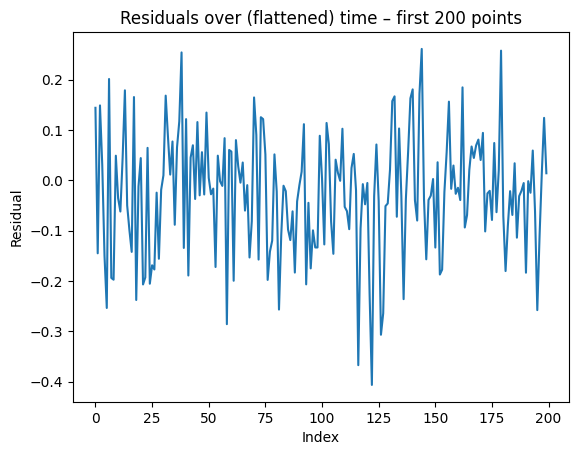

In [253]:
# -----------------------------
# 5) Visual diagnostics
# -----------------------------
# For a time-like index across the flattened horizon
idx = np.arange(res_flat.shape[0])

plt.figure()
plt.plot(idx[:200], res_flat[:200])
plt.title("Residuals over (flattened) time – first 200 points")
plt.xlabel("Index")
plt.ylabel("Residual")
plt.show()


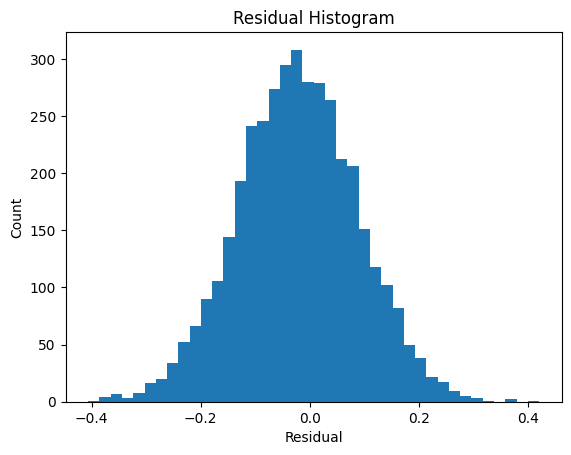

In [254]:
plt.figure()
plt.hist(res_flat, bins=40)
plt.title("Residual Histogram")
plt.xlabel("Residual")
plt.ylabel("Count")
plt.show()


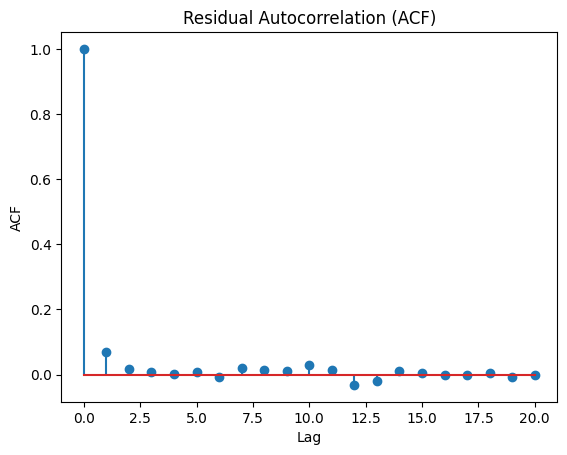

In [255]:
plt.figure()
plt.stem(np.arange(max_lag+1), acf_vals)
plt.title("Residual Autocorrelation (ACF)")
plt.xlabel("Lag")
plt.ylabel("ACF")
plt.show()


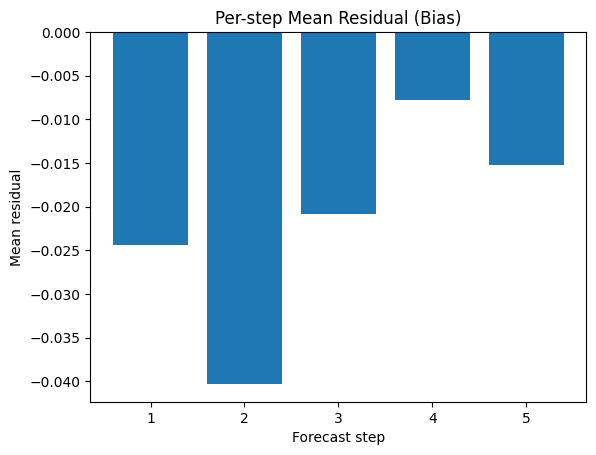

In [256]:
# Optional: bias by forecast step as bar plot
plt.figure()
plt.bar(np.arange(1, H+1), step_mean)
plt.title("Per-step Mean Residual (Bias)")
plt.xlabel("Forecast step")
plt.ylabel("Mean residual")
plt.show()

---

#### **In-Class Reflection: Exercise Summary**

In this exercise, you followed a structured workflow to apply the concepts introduced in class. Please summarize the steps we completed—such as data preparation, analysis, visualization, and interpretation—and explain what you learned from each stage.  

Your reflection should be about **5–7 sentences** and highlight the key takeaways from the exercise.  

> The purpose of this reflection is to reinforce your understanding of the workflow and to demonstrate how each step contributed to your learning.  

---

A synthetic time series was first created and converted into supervised learning windows so the model could learn to predict multiple future steps from past values. A CNN-based forecasting model was then trained on this data and used to generate predictions on a held-out test set. Residuals were computed by subtracting predictions from the true values, which helped reveal how far off the model was for each forecast step. The residual analysis showed whether predictions were unbiased overall and whether errors changed across the forecasting horizon. Visual tools like histograms and time plots helped check if errors were randomly distributed or showed patterns, while autocorrelation analysis helped detect any hidden structure the model failed to learn. Overall, the exercise showed that good performance is not only about low error but also about ensuring residuals are random, unbiased, and free from systematic patterns.


#### **Exercise 25: Exporting and Loading Models for Deployment**

**Objective:**  
Learn how to **save a trained forecasting model** in multiple formats and **load it back** for inference in deployment environments. You will:  
- Train a simple LSTM model for time series forecasting.  
- Save the model in **Keras `.keras` format** and **SavedModel format**.  
- Reload the model from disk.  
- Verify that the reloaded model produces identical predictions to the original.

---

In [257]:
# ================================
# Exercise 25: Exporting and Loading Models for Deployment (Keras 3)
# ================================
import numpy as np
import tensorflow as tf
from tensorflow import keras
from keras import layers
import os

tf.random.set_seed(42)
np.random.seed(42)

# 1) Data
N = 1500
t = np.arange(N)
series = np.sin(0.02 * t) + 0.5 * np.random.randn(N)
T, H = 30, 5

def make_windows(series, T, H):
    Xs, Ys = [], []
    for i in range(len(series) - T - H + 1):
        Xs.append(series[i:i+T])
        Ys.append(series[i+T:i+T+H])
    X = np.array(Xs, dtype="float32")[..., None]  # (N, T, 1)
    y = np.array(Ys, dtype="float32")[..., None]  # (N, H, 1)
    return X, y

X, y = make_windows(series, T, H)
X_train, y_train = X[:1000], y[:1000]
X_test,  y_test  = X[1000:], y[1000:]

# 2) Model
model = keras.Sequential([
    layers.Input(shape=(T, 1)),
    layers.LSTM(32),
    layers.Dense(H),
    layers.Reshape((H, 1))
])
model.compile(optimizer="adam", loss="mse")
model.fit(X_train, y_train, epochs=5, batch_size=32, verbose=1)


Epoch 1/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.4658
Epoch 2/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2863
Epoch 3/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2723
Epoch 4/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2683
Epoch 5/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2668


In [258]:
# 3) Save in native Keras format (.keras)
keras_path = "lstm_forecast.keras"
model.save(keras_path)  # OK in Keras 3
print(f"Saved Keras model -> {keras_path}")

# 4) Export a TensorFlow SavedModel (for TF Serving / TFLite)
savedmodel_dir = "saved_lstm_model"
model.export(savedmodel_dir)  # <-- use export() in Keras 3
print(f"Exported SavedModel -> {savedmodel_dir}/")


Saved Keras model -> lstm_forecast.keras
Saved artifact at 'saved_lstm_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 30, 1), dtype=tf.float32, name='keras_tensor_587')
Output Type:
  TensorSpec(shape=(None, 5, 1), dtype=tf.float32, name=None)
Captures:
  132396303809616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132396303809232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132396303800208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132396303804816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132396303807504: TensorSpec(shape=(), dtype=tf.resource, name=None)
Exported SavedModel -> saved_lstm_model/


In [259]:
# 5) Load back the .keras model and verify predictions
model_keras_loaded = keras.models.load_model(keras_path)

sample_input = X_test[:1]
orig_pred  = model.predict(sample_input, verbose=0)
keras_pred = model_keras_loaded.predict(sample_input, verbose=0)

print("\nPrediction consistency (.keras):", np.allclose(orig_pred, keras_pred))



Prediction consistency (.keras): True


In [260]:
# 6) Load the SavedModel and run inference via its serving signature
loaded_sm = tf.saved_model.load(savedmodel_dir)
infer = loaded_sm.signatures["serving_default"]

# Inspect inputs/outputs to find the correct key names
# (keys vary; we fetch them programmatically)
input_keys = list(infer.structured_input_signature[1].keys())
output_keys = list(infer.structured_outputs.keys())
print("SavedModel input keys:", input_keys)
print("SavedModel output keys:", output_keys)


SavedModel input keys: ['keras_tensor_587']
SavedModel output keys: ['output_0']


In [261]:
# Build the kwargs dict using the first (and only) input key
sm_kwargs = {input_keys[0]: tf.constant(sample_input)}
sm_out = infer(**sm_kwargs)
sm_pred = sm_out[output_keys[0]].numpy()

print("Prediction shape (.keras):", keras_pred.shape)
print("Prediction shape (SavedModel):", sm_pred.shape)
print("Close-ish? (allow tiny numeric diffs):", np.allclose(keras_pred, sm_pred, atol=1e-6))

Prediction shape (.keras): (1, 5, 1)
Prediction shape (SavedModel): (1, 5, 1)
Close-ish? (allow tiny numeric diffs): True


---

#### **In-Class Reflection: Exercise Summary**

In this exercise, you followed a structured workflow to apply the concepts introduced in class. Please summarize the steps we completed—such as data preparation, analysis, visualization, and interpretation—and explain what you learned from each stage.  

Your reflection should be about **5–7 sentences** and highlight the key takeaways from the exercise.  

> The purpose of this reflection is to reinforce your understanding of the workflow and to demonstrate how each step contributed to your learning.  

---

A synthetic time series was first generated and converted into supervised learning windows so the model could learn to predict multiple future steps from past values. An LSTM-based forecasting model was then built and trained to capture sequential patterns in the data. After training, the model was saved in two formats: the native Keras `.keras` format and the TensorFlow SavedModel format, both of which are commonly used for deployment. The saved model was then reloaded from disk and tested to ensure it produced the same predictions as the original trained model. Small numerical checks confirmed that both formats preserve model behavior accurately, even after export and reload. Overall, the exercise showed how trained deep learning models can be reliably stored, shared, and reused in real-world deployment systems without losing performance or consistency.


#### **Exercise 26: Monitoring Model Performance in Production**

**Objective:**  
Simulate a production setup where a deployed forecaster receives **batches of new data**. You will:
- Establish **baseline** metrics (MAE, RMSE, MAPE, Bias) on a validation slice.
- Stream the test set in batches and compute **per‑batch** metrics.
- Track an **EWMA** (exponentially weighted moving average) of RMSE.
- **Alert** when batch RMSE/EWMA exceed thresholds or when **bias** drifts.

---

In [262]:
# ==========================================
# Exercise 26: Monitoring Model Performance
# Keras 3 + TF 2.18 (CPU-friendly, runnable)
# ==========================================
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from keras import layers

# Reproducibility
tf.random.set_seed(7)
np.random.seed(7)

# -----------------------------
# 1) Data: synthetic series -> windows
# -----------------------------
N = 5000
t = np.arange(N, dtype="float32")
series = 0.7*np.sin(2*np.pi*t/48) + 0.25*np.sin(2*np.pi*t/7) + 0.002*t + 0.12*np.random.randn(N).astype("float32")

T, H = 50, 6  # input window, forecast horizon

def make_windows(series, T, H):
    Xs, Ys = [], []
    for i in range(len(series) - T - H + 1):
        Xs.append(series[i:i+T])
        Ys.append(series[i+T:i+T+H])
    X = np.asarray(Xs, dtype="float32")[..., None]  # (N, T, 1)
    y = np.asarray(Ys, dtype="float32")[..., None]  # (N, H, 1)
    return X, y

X, y = make_windows(series, T, H)

# Time-aware split to mimic production
n_total = len(X)
n_train = int(0.7 * n_total)
n_val   = int(0.1 * n_total)
X_train, y_train = X[:n_train], y[:n_train]
X_val,   y_val   = X[n_train:n_train+n_val], y[n_train:n_train+n_val]
X_test,  y_test  = X[n_train+n_val:], y[n_train+n_val:]


In [263]:
# -----------------------------
# 2) Compact CNN forecaster
# -----------------------------
inp = layers.Input(shape=(T, 1))
x = layers.Conv1D(32, 3, padding="same", activation="relu")(inp)
x = layers.MaxPooling1D(2)(x)
x = layers.Conv1D(32, 3, padding="same", activation="relu")(x)
x = layers.MaxPooling1D(2)(x)
x = layers.Flatten()(x)
x = layers.Dense(64, activation="relu")(x)
x = layers.Dense(H)(x)                 # (batch, H)
out = layers.Reshape((H, 1))(x)        # (batch, H, 1)
model = keras.Model(inp, out, name="cnn_monitoring")

model.compile(optimizer="adam", loss="mse")
_ = model.fit(X_train, y_train, epochs=8, batch_size=64, validation_data=(X_val, y_val), verbose=1)


Epoch 1/8
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 1.9610 - val_loss: 0.1720
Epoch 2/8
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0626 - val_loss: 0.0429
Epoch 3/8
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0227 - val_loss: 0.0300
Epoch 4/8
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0188 - val_loss: 0.0250
Epoch 5/8
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0181 - val_loss: 0.0240
Epoch 6/8
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0178 - val_loss: 0.0248
Epoch 7/8
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0177 - val_loss: 0.0246
Epoch 8/8
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0176 - val_loss: 0.0252


In [264]:
# -----------------------------
# 3) Baseline metrics on validation set
# -----------------------------
y_val_pred = model.predict(X_val, verbose=0)
val_err = y_val - y_val_pred
eps = 1e-6

baseline_mae  = float(np.mean(np.abs(val_err)))
baseline_rmse = float(np.sqrt(np.mean(val_err**2)))
baseline_mape = float(np.mean(np.abs(val_err) / (np.abs(y_val) + eps)) * 100.0)
baseline_bias = float(np.mean(val_err))

print("\n=== Baseline (validation) ===")
print(f"MAE: {baseline_mae:.6f} | RMSE: {baseline_rmse:.6f} | MAPE: {baseline_mape:.4f}% | Bias: {baseline_bias:+.6f}")

# Simple thresholds (illustrative)
rmse_thresh = baseline_rmse * 1.5
bias_abs_thresh = max(0.5 * baseline_mae, 0.01)



=== Baseline (validation) ===
MAE: 0.126942 | RMSE: 0.158810 | MAPE: 1.6974% | Bias: -0.020583


In [265]:
# -----------------------------
# 4) Stream test data in batches ("days")
# -----------------------------
batch_size = 128
n_batches = int(np.ceil(len(X_test) / batch_size))

batch_mae, batch_rmse, batch_mape, batch_bias = [], [], [], []
alerts = []

def ewma(values, alpha=0.25):
    out = []
    s = None
    for v in values:
        s = v if s is None else alpha*v + (1-alpha)*s
        out.append(s)
    return np.array(out, dtype="float32")

for b in range(n_batches):
    s = b * batch_size
    e = min((b+1) * batch_size, len(X_test))
    Xb = X_test[s:e]
    yb = y_test[s:e]
    yp = model.predict(Xb, verbose=0)
    err = yb - yp

    mae = float(np.mean(np.abs(err)))
    rmse = float(np.sqrt(np.mean(err**2)))
    mape = float(np.mean(np.abs(err) / (np.abs(yb) + eps)) * 100.0)
    bias = float(np.mean(err))

    batch_mae.append(mae)
    batch_rmse.append(rmse)
    batch_mape.append(mape)
    batch_bias.append(bias)

rmse_ewma = ewma(batch_rmse, alpha=0.25)

for i, (rm, ew, bi) in enumerate(zip(batch_rmse, rmse_ewma, batch_bias)):
    reasons = []
    if rm > rmse_thresh:
        reasons.append("RMSE>thresh")
    if ew > rmse_thresh:
        reasons.append("EWMA>thresh")
    if abs(bi) > bias_abs_thresh:
        reasons.append("Bias drift")
    if reasons:
        alerts.append((i, reasons))

print("\n=== Alerts (batch index, reasons) ===")
if not alerts:
    print("No alerts. Performance within thresholds.")
else:
    for idx, reasons in alerts:
        print(f"Batch {idx}: {', '.join(reasons)}")



=== Alerts (batch index, reasons) ===
No alerts. Performance within thresholds.


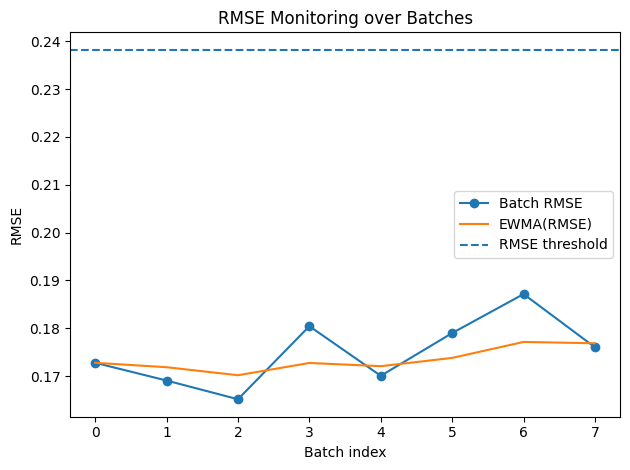

In [266]:
# -----------------------------
# 5) Visualization
# -----------------------------
b = np.arange(n_batches)

plt.figure()
plt.plot(b, batch_rmse, marker="o", label="Batch RMSE")
plt.plot(b, rmse_ewma, label="EWMA(RMSE)")
plt.axhline(rmse_thresh, linestyle="--", label="RMSE threshold")
plt.title("RMSE Monitoring over Batches")
plt.xlabel("Batch index")
plt.ylabel("RMSE")
plt.legend()
plt.tight_layout()
plt.show()


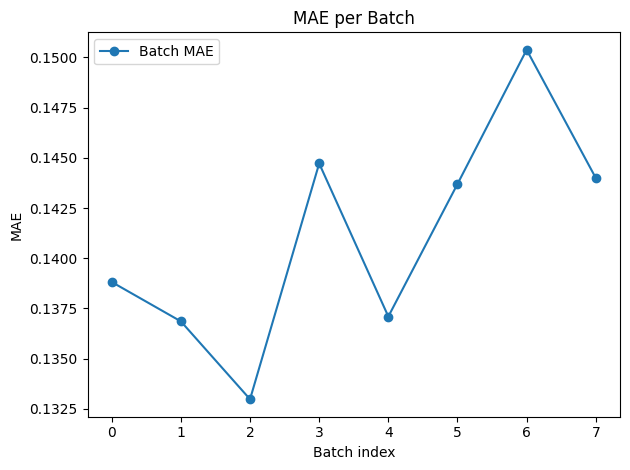

In [267]:
plt.figure()
plt.plot(b, batch_mae, marker="o", label="Batch MAE")
plt.title("MAE per Batch")
plt.xlabel("Batch index")
plt.ylabel("MAE")
plt.legend()
plt.tight_layout()
plt.show()


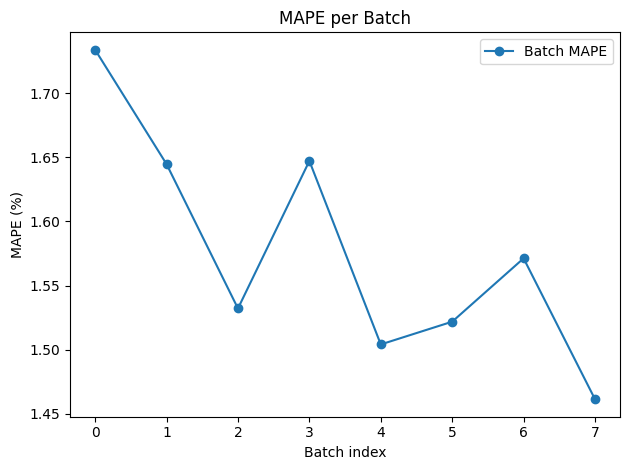

In [268]:
plt.figure()
plt.plot(b, batch_mape, marker="o", label="Batch MAPE")
plt.title("MAPE per Batch")
plt.xlabel("Batch index")
plt.ylabel("MAPE (%)")
plt.legend()
plt.tight_layout()
plt.show()


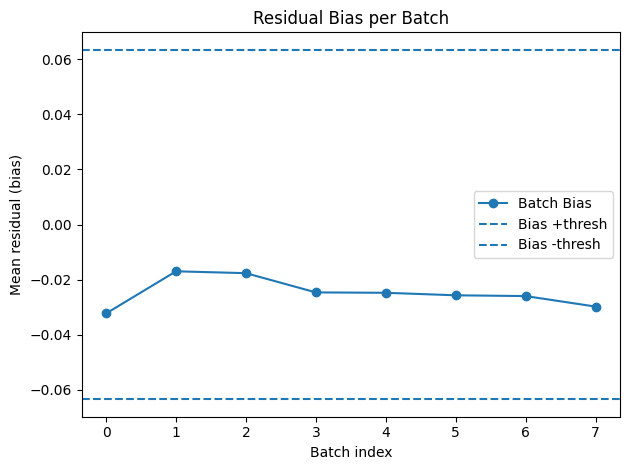

In [269]:
plt.figure()
plt.plot(b, batch_bias, marker="o", label="Batch Bias")
plt.axhline(+bias_abs_thresh, linestyle="--", label="Bias +thresh")
plt.axhline(-bias_abs_thresh, linestyle="--", label="Bias -thresh")
plt.title("Residual Bias per Batch")
plt.xlabel("Batch index")
plt.ylabel("Mean residual (bias)")
plt.legend()
plt.tight_layout()
plt.show()


In [270]:
print("\n=== Final Status Report ===")
print(f"Baseline RMSE: {baseline_rmse:.6f} | Threshold: {rmse_thresh:.6f}")
print(f"Max Batch RMSE: {np.max(batch_rmse):.6f} | Max EWMA: {np.max(rmse_ewma):.6f}")
print(f"Max |Bias|: {np.max(np.abs(batch_bias)):.6f} | Bias threshold: {bias_abs_thresh:.6f}")
print(f"Total alerts: {len(alerts)}")


=== Final Status Report ===
Baseline RMSE: 0.158810 | Threshold: 0.238215
Max Batch RMSE: 0.187150 | Max EWMA: 0.177142
Max |Bias|: 0.032295 | Bias threshold: 0.063471
Total alerts: 0


---

#### **In-Class Reflection: Exercise Summary**

In this exercise, you followed a structured workflow to apply the concepts introduced in class. Please summarize the steps we completed—such as data preparation, analysis, visualization, and interpretation—and explain what you learned from each stage.  

Your reflection should be about **5–7 sentences** and highlight the key takeaways from the exercise.  

> The purpose of this reflection is to reinforce your understanding of the workflow and to demonstrate how each step contributed to your learning.  

---

The exercise started with preparing a synthetic time series and converting it into supervised learning windows so the model could learn patterns from past values to predict future values. A CNN-based forecasting model was then trained using this structured data, which helped capture both short-term and long-term trends in the sequence. After training, baseline evaluation metrics like MAE, RMSE, MAPE, and bias were computed on the validation set to understand the model’s overall accuracy and error behavior. The test data was then processed in batches to simulate a real production environment where data arrives over time instead of all at once. Batch-wise metrics and an EWMA of RMSE were used to monitor performance stability and detect any potential degradation or drift. The final step showed how threshold-based alerts can help identify issues early, ensuring the model remains reliable when deployed in real-world systems.


#### **Revised: September 1, 2025**